# 30_04 — Evaluación predictiva · Escenario 1 · **barrido en $M$**

Paso **3b** del ciclo. Supone que `30_03_convergencia` dio veredicto ✓ **en cada
punto del barrido**; si las cadenas de un $M$ no convergieron, sus cifras aquí
no significan nada y tampoco su lugar en la comparación de §11.

## Qué se reporta

| Sección | Qué responde |
|---|---|
| 4 | métricas puntuales y distribucionales, **train vs test**, por $M$ |
| 5 | bandas de credibilidad sobre la serie de cada score |
| 6 | intervalos sobre la curva, en extractos cada 10 períodos |
| 7 | ventana móvil: cómo evoluciona el error al cruzar $T_0$ |
| 8 | calibración: PIT por bloque |
| 9 | comparación con las líneas base de `30_01` |
| **11** | **el barrido: todo lo anterior cruzado entre $M$** |

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.


## 1. Imports, rutas y artefactos

In [36]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_curvas_true, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor, PropagadorFuncional

from model_psbp_fd.fit import (
    # puntual
    rmse_por_coeficiente, r2_por_columna, razon_dispersion, mise, rmse_funcional,
    # distribucional muestral
    crps_muestral, energy_score, cobertura, intervalo_muestral,
    pit_muestral, diagnostico_pit,
    # agrupación de cadenas y ventana móvil
    agrupar_momentos, ventana_movil_scores, ventana_movil_funcional,
    # Bloque A: normas L^p del error (MAE, RMSE, L^inf / Q_0.95 y su argmax)
    resumen_error_funcional, normas_error_por_origen,
    # Bloque B: intervalos (Winkler primaria; PICP, MPIW diagnósticas)
    resumen_intervalo, winkler, indicador_cobertura,
    # incertidumbre bajo dependencia
    bootstrap_bloques, largo_bloque_sugerido, tabla_bootstrap,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_bandas_serie, plot_extractos_curvas,
    plot_calibracion_pit, plot_scatter_theta,
)
from model_psbp_fd.utils import get_project_root

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [37]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] 
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario", 1, 1
M_FPCA_LIST = (1, 2, 3)

SALTAR_M_SIN_TRAZAS = True

#   Bloque A (error puntual)  primaria: "rmse_f" o "mae_f", NO las dos.
#       rmse_f estima la MEDIA condicional, que es el funcional que el PSBPM-FD
#       estima y el que usa el resto del capitulo (MISE). mae_f estima la
#       MEDIANA. Con predictivas asimetricas pueden ordenar distinto, de modo
#       que cambiar esta constante cambia potencialmente la conclusion: si se
#       cambia, hay que decirlo en el texto.
#   Bloque B (intervalos)     primaria: "winkler", que es regla propia.
#       PICP y MPIW son su descomposicion y NUNCA rankean por si solas.
METRICA_PRIMARIA_A = "rmse_f"      # {"rmse_f", "mae_f"}
METRICA_PRIMARIA_B = "winkler"     # fijo: es la unica regla propia del bloque
DIAGNOSTICAS_A = ["linf_max", "linf_medio", "q95_abs_medio",
                  "razon_linf_l1_media", "l2_medio", "razon_agregacion"]
DIAGNOSTICAS_B = ["picp", "ee_picp", "ace", "mpiw"]

Q_EXTREMO = 0.95    # cuantil de |e| que sustituye al supremo como cifra citable
# Ponderacion del DOMINIO FUNCIONAL tau, identica para todos los modelos. None
# = uniforme (la cuadratura trapezoidal de siempre). No confundir con una
# ponderacion sobre HORIZONTES: aqui h = 1 en todos los origenes.
PESOS_TAU = None

# Bootstrap de BLOQUES para la incertidumbre de las cifras agregadas. Los
# errores no son independientes entre origenes y con ventanas solapadas menos
# aun, de modo que el error estandar independiente no sirve.
BOOT_B      = 2000
BOOT_SEED   = 20260905
BOOT_BLOQUE = None   # None -> fit.largo_bloque_sugerido; se reporta el usado
# ============================================================================

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
assert len(set(M_FPCA_LIST)) == len(M_FPCA_LIST), "M_FPCA_LIST tiene repetidos."

EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M      = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}")
print(f"salidas cruzadas (§11) : {PATH_BARRIDO}   (archivos 85-89)")

# ============================================================================
# [METRICAS] La lista que se monitorea, en orden y SIN jerarquia.
#
# Es la especificacion de metricas del capitulo escrita UNA sola vez, y la
# consumen la ventana movil (§7.1) y la tabla resumen (§7.2). Todo se evalua a
# nivel FUNCIONAL --sobre la curva reconstruida contra la curva verdadera, que
# es la cantidad que le importa a la tesis--; las mismas cantidades por score
# siguen en las tablas 50 y 56, pero no son estas y no se mezclan.
#
# Cada entrada es (etiqueta, columna en la tabla de VENTANA, columna en la
# tabla AGREGADA). Los dos nombres coinciden salvo en el cuantil extremo
# --`q95_abs` contra `q95_abs_medio`--, porque en la ventana la cifra ya es un
# promedio sobre los origenes de esa ventana y en el agregado se promedia sobre
# todo el bloque. Es la misma cantidad, y por eso viaja en la misma fila.
#
# NINGUNA de estas es "primaria" en esta seccion: la figura las dibuja todas y
# la tabla las lista todas, en este orden. METRICA_PRIMARIA_A/B siguen
# existiendo pero SOLO gobiernan el ranking de modelos del _05 y el cociente
# contra el piso de truncamiento; no deciden que se calcula ni que se muestra.
_Q_SUF = "q%d_abs" % int(round(Q_EXTREMO * 100))

METRICAS_A = [
    (u"1. MAE   (L^1)",          "mae_f",  "mae_f"),
    (u"2. RMSE  (L^2)",          "rmse_f", "rmse_f"),
    (u"3. Q%.2f |e| (L^inf)" % Q_EXTREMO, _Q_SUF, _Q_SUF + "_medio"),
]
METRICAS_B = [
    (u"4. Winkler",              "winkler", "winkler"),
    (u"6. PICP",                 "picp",    "picp"),
    (u"7. MPIW",                 "mpiw",    "mpiw"),
]
# La 5 --el indicador de cobertura I_t-- no va aqui: no es una cifra por
# ventana sino una serie por ORIGEN, y es de la que (6) es el promedio. Se
# persiste aparte en `67_indicador_cobertura.csv` (§7.2).
METRICAS_MONITOR = METRICAS_A + METRICAS_B

print("")
print("metricas monitoreadas (nivel funcional, en orden):")
for _et, _cw, _ca in METRICAS_MONITOR:
    print("   %-22s  ventana=%-12s agregada=%s" % (_et, _cw, _ca))
print("   5. I_t (indicador por origen)  ->  67_indicador_cobertura.csv")


barrido en M : [1, 2, 3]
  M=1  ->  escenario_1_r01_m01
  M=2  ->  escenario_1_r01_m02
  M=3  ->  escenario_1_r01_m03
salidas cruzadas (§11) : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_barrido_M   (archivos 85-89)

metricas monitoreadas (nivel funcional, en orden):
   1. MAE   (L^1)          ventana=mae_f        agregada=mae_f
   2. RMSE  (L^2)          ventana=rmse_f       agregada=rmse_f
   3. Q0.95 |e| (L^inf)    ventana=q95_abs      agregada=q95_abs_medio
   4. Winkler              ventana=winkler      agregada=winkler
   6. PICP                 ventana=picp         agregada=picp
   7. MPIW                 ventana=mpiw         agregada=mpiw
   5. I_t (indicador por origen)  ->  67_indicador_cobertura.csv


In [38]:
# Estado por punto del barrido. Nada de lo que sigue usa variables globales del
# experimento: todo se lee de EST[M].
EST = {}
saltados = []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 30_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes.")
    assert manifest["scores_scale"] == "standardized_zscore_ddof0"

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": manifest["cov_names"],
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "burn": int(hp_json["mcmc_config"]["burn"]),
        # Parámetros de evaluación: se LEEN del artefacto, no se redeclaran.
        "nivel": float(eval_config.get("nivel_credibilidad", 0.95)),
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "objetivo": eval_config.get("objetivo_evaluacion", "curva_verdadera"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [10, 20, 40])),
    }
    EST[M]["n_post"] = EST[M]["mcmc_cfg"]["nsim"] - EST[M]["burn"]

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 30_01 primero."

for M, e in EST.items():
    print(f"M={M}  T={e['T']} T0={e['T0']} n_lags={e['n_lags']} "
          f"componentes={e['n_components']}  nivel={e['nivel']}  "
          f"modo_residuo={e['modo_residuo']!r}  objetivo={e['objetivo']!r}")
for M, motivo in saltados:
    print(f"  ! M={M} saltado: {motivo}")

# La comparación entre M sólo tiene sentido si el diseño de observación, la
# partición y el objetivo de evaluación son los mismos en todos los puntos: si
# no, las diferencias mezclarían el efecto de M con el de otra cosa.
_comun = {M: (e["T"], e["T0"], e["n_lags"], e["nivel"], e["modo_residuo"],
              e["objetivo"], tuple(e["ventanas_w"]), e["n_iter"],
              e["mcmc_cfg"]["nsim"], e["mcmc_cfg"]["N"], e["burn"])
          for M, e in EST.items()}
if len(set(_comun.values())) > 1:
    print("\n! Los puntos del barrido NO comparten diseño/evaluación:")
    for M, v in _comun.items():
        print(f"    M={M}: {v}")
    raise AssertionError(
        "El barrido en M exige T, T0, n_lags, nivel, modo_residuo, objetivo, "
        "ventanas y configuración MCMC idénticos. Regenera los puntos que "
        "difieren antes de comparar.")
print("\nOK todos los puntos comparten diseño de observación, partición, "
      "objetivo de evaluación y configuración MCMC.")

# Alias de las cantidades comunes, para no repetir EST[M][...] en cada celda.
T          = EST[next(iter(EST))]["T"]
T0         = EST[next(iter(EST))]["T0"]
N_LAGS     = EST[next(iter(EST))]["n_lags"]
NIVEL      = EST[next(iter(EST))]["nivel"]
MODO_RESIDUO = EST[next(iter(EST))]["modo_residuo"]
OBJETIVO   = EST[next(iter(EST))]["objetivo"]
VENTANAS_W = EST[next(iter(EST))]["ventanas_w"]
W_REF      = VENTANAS_W[len(VENTANAS_W) // 2]
print(f"ventanas w = {VENTANAS_W}   ·   referencia w={W_REF}")

M=1  T=800 T0=560 n_lags=1 componentes=1  nivel=0.95  modo_residuo='ninguno'  objetivo='curva_verdadera'
M=2  T=800 T0=560 n_lags=1 componentes=2  nivel=0.95  modo_residuo='ninguno'  objetivo='curva_verdadera'
M=3  T=800 T0=560 n_lags=1 componentes=3  nivel=0.95  modo_residuo='ninguno'  objetivo='curva_verdadera'

OK todos los puntos comparten diseño de observación, partición, objetivo de evaluación y configuración MCMC.
ventanas w = [10, 20, 40]   ·   referencia w=20


In [39]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]

    fpca = cargar_fpca(P)
    _ver = fpca.verificar()
    assert _ver["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen: {_ver}"

    std = cargar_estandarizador(P, DataStandardizer)
    X_obs, grilla = cargar_curvas(P)          # (T, G) con ruido
    X_true        = cargar_curvas_true(P)     # (T, G) verdadera - el objetivo

    assert e["component_idx"] == list(range(fpca.M)), (
        "La propagación funcional necesita el vector completo de scores en "
        f"orden; [M={M}] COMPONENT_IDX={e['component_idx']} y M={fpca.M}.")

    e.update({"fpca": fpca, "std": std, "X_obs": X_obs, "X_true": X_true,
              "grilla": grilla, "M_fpca": fpca.M, "K": fpca.K,
              "Psi_grid": fpca.Psi_grid, "mu_grid": fpca.mu_grid,
              "SCORES": fpca.SCORES,
              "var_explicada": float(fpca.meta["var_explained"])})

    print(f"M={M}  FPCA M={fpca.M} K={fpca.K}  var. explicada="
          f"{e['var_explicada']:.4%}  ·  curvas {X_true.shape}  "
          f"grilla {grilla.shape}")

# Las curvas y la grilla son las MISMAS en todos los puntos: el generador y la
# semilla no dependen de M, sólo cambia cuántas componentes se retienen. Si no
# coincidieran, el MISE de dos M no sería sobre los mismos datos.
_M0 = next(iter(EST))
for M in EST:
    assert np.allclose(EST[M]["X_true"], EST[_M0]["X_true"]), (
        f"[M={M}] las curvas verdaderas difieren de las de M={_M0}: los puntos "
        "del barrido no salen de la misma simulación.")
    assert np.allclose(EST[M]["grilla"], EST[_M0]["grilla"])
grilla = EST[_M0]["grilla"]
X_true = EST[_M0]["X_true"]
X_obs  = EST[_M0]["X_obs"]
print(f"\nOK las {len(EST)} representaciones vienen de la MISMA simulación: "
      "las diferencias entre M son de representación, no de datos.")
print(f"sd(observada - verdadera) = {(X_obs - X_true).std():.4f}   "
      "<- el ruido que el modelo NO debe predecir")

M=1  FPCA M=1 K=4  var. explicada=82.9797%  ·  curvas (800, 100)  grilla (100,)
M=2  FPCA M=2 K=4  var. explicada=97.6881%  ·  curvas (800, 100)  grilla (100,)
M=3  FPCA M=3 K=4  var. explicada=99.7883%  ·  curvas (800, 100)  grilla (100,)

OK las 3 representaciones vienen de la MISMA simulación: las diferencias entre M son de representación, no de datos.
sd(observada - verdadera) = 0.2497   <- el ruido que el modelo NO debe predecir


## 2. Trazas MCMC

Una lectura por punto del barrido. El `feature_names` del `.mat` se verifica
contra las columnas del dataset: con $M$ distintos el número de covariables
cambia, y un `.mat` del punto equivocado se detectaría aquí y no más adelante
como un resultado raro.

In [40]:
_CLAVES_TRAZA = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
                 "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]


def ruta_traza(P, fpc_idx, chain):
    return P["out_artefact"] / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path):
    m = loadmat(str(path))
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in _CLAVES_TRAZA}
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    def __init__(self, traces, burn, feature_names):
        self.traces = traces
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)
        self.n_features_ = int(self.predictor_.n_features_)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def momentos(self, df):
        return self.predictor_.momentos_predictivos(self._diseno(df))

    def muestrear(self, df, d=1, seed=None):
        return self.predictor_.muestrear(self._diseno(df), d, seed=seed)

In [41]:
sin_trazas = []

for M in list(EST):
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]
    if faltan:
        msg = f"faltan {len(faltan)} trazas: {faltan[:3]}{'...' if len(faltan) > 3 else ''}"
        if not SALTAR_M_SIN_TRAZAS:
            raise AssertionError(f"[M={M}] {msg}\nEjecuta psbp_fd_iteracion.m.")
        sin_trazas.append((M, msg))
        del EST[M]
        continue

    models_chains = {k: {} for k in range(n_comp)}
    for k in range(n_comp):
        esperado = list(e["dfs_train"][k].columns[1:])
        for c in range(n_iter):
            traces, burn, feat = leer_traza(ruta_traza(P, ci[k] + 1, c + 1))
            assert feat == esperado, (
                f"[M={M} k={k} c={c+1}] feature_names != columnas del dataset:\n"
                f"  mat  = {feat}\n  train= {esperado}")
            models_chains[k][c] = ModeloTraza(traces, burn, feat)
    e["models_chains"] = models_chains
    print(f"OK M={M}: {n_comp} x {n_iter} cadenas · {e['n_post']} draws "
          f"posteriores c/u  ·  p={models_chains[0][0].n_features_}")

assert EST, ("Ningún punto del barrido tiene trazas. Ejecuta "
             "psbp_fd_iteracion.m con M_FPCA_LIST antes de este notebook.")
for M, motivo in sin_trazas:
    print(f"! M={M} saltado: {motivo}")

M_OK = tuple(sorted(EST))
print(f"\npuntos evaluables: M = {list(M_OK)}")

OK M=1: 1 x 2 cadenas · 2000 draws posteriores c/u  ·  p=1
OK M=2: 2 x 2 cadenas · 2000 draws posteriores c/u  ·  p=2
OK M=3: 3 x 2 cadenas · 2000 draws posteriores c/u  ·  p=3

puntos evaluables: M = [1, 2, 3]


## 3. Predicción a $h=1$ sobre la serie completa


In [42]:
# Número de extracciones de la predictiva por draw posterior. El total es
#     S = (nsim - burn) × S_POR_ITER × n_cadenas
# y d=1 ya da varios miles: subirlo sólo reduce el error Monte Carlo de estimar
# los cuantiles, no cambia la predictiva.
S_POR_ITER = 10
S_FUNC     = 500        # muestras funcionales tras adelgazar
SEED_PRED  = 20260823
CADA       = 20         # [CONFIG] un extracto de curva cada CADA períodos

# Serie de orígenes: es la MISMA en todos los M (T, T0 y n_lags son comunes).
t_orig   = np.arange(N_LAGS + 1, T + 1)      # tiempo del experimento, base-1
n_orig   = len(t_orig)
T0_orig  = T0 - N_LAGS                       # corte dentro de la serie de orígenes
es_train = t_orig <= T0
print(f"orígenes evaluados: {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})")

_mem = sum(EST[M]["n_post"] * S_POR_ITER * EST[M]["n_iter"] * n_orig
           * EST[M]["n_components"] * 4 for M in M_OK) / 1e9
print(f"SC_draws de TODO el barrido reservará {_mem * 1e3:.0f} MB en float32")
assert _mem < 2.0, (
    f"SC_draws pediría {_mem:.1f} GB sumando los M. Baja S_POR_ITER o acorta "
    "M_FPCA_LIST antes de continuar.")
print(f"X_draws se libera dentro del bucle: pico ≈ "
      f"{S_FUNC * n_orig * len(grilla) * 8 / 1e6:.0f} MB (un solo M a la vez)")

orígenes evaluados: 799  (train 559 · test 240)
SC_draws de TODO el barrido reservará 767 MB en float32
X_draws se libera dentro del bucle: pico ≈ 320 MB (un solo M a la vez)


In [43]:
for M in M_OK:
    e = EST[M]
    n_comp, n_iter, n_post = e["n_components"], e["n_iter"], e["n_post"]
    ci = e["component_idx"]

    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]],
                             ignore_index=True) for k in range(n_comp)}
    assert len(dfs_full[0]) == n_orig, f"[M={M}] {len(dfs_full[0])} != {n_orig}"

    # -- momentos y extracciones por score, agrupando cadenas ----------------
    #    momentos : ley de varianza total entre cadenas (fit.agrupar_momentos)
    #    muestras : concatenación, que es la mezcla de igual peso
    Y_obs = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy()
                             for k in range(n_comp)])
    Y_hat = np.empty_like(Y_obs)
    Y_sd  = np.empty_like(Y_obs)

    S_POR_CADENA = n_post * S_POR_ITER
    S_total      = S_POR_CADENA * n_iter
    SC_draws     = np.empty((S_total, n_orig, n_comp), dtype=np.float32)

    for k in range(n_comp):
        medias, sds = [], []
        for j, c in enumerate(sorted(e["models_chains"][k])):
            mom = e["models_chains"][k][c].momentos(dfs_full[k])
            medias.append(mom["media"])
            sds.append(mom["sd"])          # PREDICTIVA (v3), no la del centro
            muestras_c = e["models_chains"][k][c].muestrear(
                dfs_full[k], S_POR_ITER, seed=SEED_PRED + 1000 * k + c + 97 * M)
            assert muestras_c.shape == (S_POR_CADENA, n_orig), (
                f"[M={M} k={k} c={c}] muestrear devolvió {muestras_c.shape}; se "
                f"esperaba ({S_POR_CADENA}, {n_orig}).")
            SC_draws[j * S_POR_CADENA:(j + 1) * S_POR_CADENA, :, k] = muestras_c
            del muestras_c
        Y_hat[:, k], Y_sd[:, k] = agrupar_momentos(np.column_stack(medias),
                                                   np.column_stack(sds))

    li_s, ls_s = intervalo_muestral(SC_draws, nivel=NIVEL)     # (n_orig, M)

    # -- propagación a la curva ---------------------------------------------
    paso_thin = max(1, S_total // S_FUNC)
    propagador = PropagadorFuncional(e["Psi_grid"], e["mu_grid"],
                                     estandarizador=e["std"],
                                     modo_residuo=MODO_RESIDUO)
    X_draws = propagador.curvas_desde_scores(SC_draws[::paso_thin], seed=SEED_PRED)
    X_pred  = X_draws.mean(axis=0)                              # (n, G)
    li_f = np.quantile(X_draws, (1 - NIVEL) / 2, axis=0)
    ls_f = np.quantile(X_draws, 1 - (1 - NIVEL) / 2, axis=0)

    X_true_ev = X_true[N_LAGS:]      # (n_orig, G) VERDADERA - contra esto se evalúa
    X_obs_ev  = X_obs[N_LAGS:]       # (n_orig, G) observada, sólo para las figuras
    X_proj    = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]     # piso de la representación

    # El energy score necesita las muestras funcionales completas, así que se
    # calcula AQUÍ y no en §4: es lo único que impide liberar X_draws.
    energia = {etq: energy_score(X_true_ev[m], X_draws[:, m, :],
                                 max_pares=2000, seed=0)
               for etq, m in (("train", es_train), ("test", ~es_train))}
    S_funcional = int(X_draws.shape[0])
    del X_draws

    e.update({"dfs_full": dfs_full, "Y_obs": Y_obs, "Y_hat": Y_hat, "Y_sd": Y_sd,
              "SC_draws": SC_draws, "li_s": li_s, "ls_s": ls_s,
              "X_pred": X_pred, "li_f": li_f, "ls_f": ls_f, "X_proj": X_proj,
              "energia": energia, "S_total": int(S_total),
              "S_funcional": S_funcional, "paso_thin": paso_thin})

    print(f"M={M}: S={S_total} extracciones por score · funcionales "
          f"{S_funcional} (1 de cada {paso_thin}) · SC_draws "
          f"{SC_draws.nbytes / 1e6:.0f} MB")
    print(f"       MISE del TRUNCAMIENTO (test) = "
          f"{mise(X_true_ev[~es_train], X_proj[~es_train], grilla):.6f}"
          "   <- ningún modelo sobre esta representación baja de ahí")

X_true_ev = X_true[N_LAGS:]
X_obs_ev  = X_obs[N_LAGS:]

M=1: S=40000 extracciones por score · funcionales 500 (1 de cada 80) · SC_draws 128 MB
       MISE del TRUNCAMIENTO (test) = 0.228561   <- ningún modelo sobre esta representación baja de ahí
M=2: S=40000 extracciones por score · funcionales 500 (1 de cada 80) · SC_draws 256 MB
       MISE del TRUNCAMIENTO (test) = 0.034991   <- ningún modelo sobre esta representación baja de ahí
M=3: S=40000 extracciones por score · funcionales 500 (1 de cada 80) · SC_draws 384 MB
       MISE del TRUNCAMIENTO (test) = 0.005754   <- ningún modelo sobre esta representación baja de ahí


## 4. Métricas, entrenamiento contra prueba

La comparación train/test es la que separa el ajuste de la generalización.
En el Escenario 1 —control, FAR(1) estacionario— **las dos columnas deberían
parecerse**: si el test se degrada mucho hay sobreajuste, y ese resultado es la
referencia contra la cual leer los escenarios 2–6.

Una tabla por $M$; el cruce entre $M$ está en §11.

In [44]:
def metricas_scores(M):
    """Métricas puntuales y distribucionales por score y bloque."""
    e = EST[M]
    filas = []
    for etiqueta, mask in (("train", es_train), ("test", ~es_train)):
        for k in range(e["n_components"]):
            y, p = e["Y_obs"][mask, k], e["Y_hat"][mask, k]
            z    = e["SC_draws"][:, mask, k]
            cob  = cobertura(y, e["li_s"][mask, k], e["ls_s"][mask, k])
            pit  = pit_muestral(y, z)
            filas.append({
                "bloque": etiqueta,
                "FPC":    f"FPC {e['component_idx'][k] + 1}",
                "RMSE":   float(rmse_por_coeficiente(y[:, None], p[:, None])[0]),
                "R2":     float(r2_por_columna(y[:, None], p[:, None], centrar=True)[0]),
                "sd_ratio": float(razon_dispersion(y[:, None], p[:, None])[0]),
                "CRPS":   float(crps_muestral(y, z).mean()),
                f"Cob{int(NIVEL*100)}": cob["cobertura"],
                "Ancho":  cob["ancho_medio"],
                "PIT_ks": float(diagnostico_pit(pit)["ks"]),
                "PIT_forma": diagnostico_pit(pit)["forma"],
                "n":      int(mask.sum()),
            })
    return pd.DataFrame(filas).set_index(["bloque", "FPC"])


for M in M_OK:
    e = EST[M]
    met_df = metricas_scores(M)
    met_df.to_csv(e["paths"]["out_report"] / "50_metricas_scores.csv")
    e["met_df"] = met_df

    _num = [c for c in met_df.columns if met_df[c].dtype.kind == "f"]
    display(met_df.style
        .format({c: "{:.4f}" for c in _num})
        .background_gradient(subset=["RMSE", "CRPS"], cmap="RdYlGn_r")
        .background_gradient(subset=["R2"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=[f"Cob{int(NIVEL*100)}"], cmap="RdYlGn",
                             vmin=0.80, vmax=1.0)
        .set_caption(f"M={M} - métricas por score y bloque · CRPS y cobertura "
                     "desde la predictiva MUESTRAL"))

    deg = met_df.loc["test", "RMSE"].mean() / met_df.loc["train", "RMSE"].mean()
    e["degradacion_rmse"] = float(deg)
    print(f"[M={M}] RMSE test / RMSE train = {deg:.3f}"
          + ("   OK sin degradación apreciable" if deg < 1.15
             else "   <- el modelo se degrada fuera de muestra"))

,,RMSE,R2,sd_ratio,CRPS,Cob95,Ancho,PIT_ks,PIT_forma,n
bloque,FPC,,,,,,,,,
train,FPC 1,0.7651,0.4154,0.6366,0.4329,0.9463,3.0214,0.0289,aproximadamente uniforme,559
test,FPC 1,0.7731,0.3485,0.6373,0.4355,0.9375,3.0215,0.0347,aproximadamente uniforme,240


[M=1] RMSE test / RMSE train = 1.010   OK sin degradación apreciable


[M=2] RMSE test / RMSE train = 0.987   OK sin degradación apreciable


[M=3] RMSE test / RMSE train = 0.987   OK sin degradación apreciable


In [45]:
# Métricas funcionales, contra la curva VERDADERA.
for M in M_OK:
    e = EST[M]
    filas_f = []
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        dentro = ((X_true_ev[mask] >= e["li_f"][mask]) &
                  (X_true_ev[mask] <= e["ls_f"][mask]))
        filas_f.append({
            "bloque": etq,
            "MISE":   mise(X_true_ev[mask], e["X_pred"][mask], grilla),
            "RMSE_f": rmse_funcional(X_true_ev[mask], e["X_pred"][mask], grilla),
            "MISE_truncamiento": mise(X_true_ev[mask], e["X_proj"][mask], grilla),
            "energy": e["energia"][etq],
            f"Cob{int(NIVEL*100)}_puntual": float(dentro.mean()),
            "ancho_medio": float((e["ls_f"][mask] - e["li_f"][mask]).mean()),
            "n": int(mask.sum()),
        })
    fun_df = pd.DataFrame(filas_f).set_index("bloque")
    fun_df.to_csv(e["paths"]["out_report"] / "51_metricas_funcionales.csv")
    e["fun_df"] = fun_df

    display(fun_df.style
            .format("{:.6f}", subset=["MISE", "RMSE_f", "MISE_truncamiento"])
            .format("{:.4f}", subset=["energy", f"Cob{int(NIVEL*100)}_puntual",
                                      "ancho_medio"])
            .set_caption(f"M={M} - métricas funcionales contra la curva "
                         "VERDADERA · banda sin residuo de representación"))

    frac = fun_df["MISE_truncamiento"] / fun_df["MISE"]
    e["frac_truncamiento"] = {b: float(frac[b]) for b in fun_df.index}
    print(f"[M={M}] fracción del MISE atribuible al truncamiento FPCA:")
    for b in fun_df.index:
        print(f"    {b:5s}: {frac[b]:.1%}"
              + ("   <- el techo de la representación domina; subir M rinde más "
                 "que mejorar el modelo" if frac[b] > 0.7 else ""))

print(f"\nLa cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre "
      f"la curva.")

,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,0.967623,0.983678,0.251333,6.4012,0.8891,3.2844,559
test,0.951085,0.975236,0.228561,6.3144,0.8960,3.2922,240


[M=1] fracción del MISE atribuible al truncamiento FPCA:
    train: 26.0%
    test : 24.0%


,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,0.948482,0.973901,0.035136,6.0884,0.9394,3.7378,559
test,0.948342,0.973828,0.034991,6.0484,0.9420,3.7183,240


[M=2] fracción del MISE atribuible al truncamiento FPCA:
    train: 3.7%
    test : 3.7%


,MISE,RMSE_f,MISE_truncamiento,energy,Cob95_puntual,ancho_medio,n
bloque,,,,,,,
train,0.953579,0.976514,0.005494,6.0901,0.9440,3.8172,559
test,0.939782,0.969424,0.005754,6.0168,0.9486,3.8246,240


[M=3] fracción del MISE atribuible al truncamiento FPCA:
    train: 0.6%
    test : 0.6%

La cobertura es PUNTUAL (cada tau por separado), NO simultánea sobre la curva.


## 4.3 Bloque A y Bloque B

Las métricas de esta sección **no sustituyen** a las de §4.1 y §4.2: son el
mismo error mirado con tres normas y la banda mirada con una regla propia.

**Bloque A — normas $L^p$ del error $e_t(\tau)=X_t(\tau)-\hat X_t(\tau)$.**
$\|e\|_1$ (MAE) estima la **mediana** condicional y es robusta; $\|e\|_2$
(RMSE, y por tanto el MISE) estima la **media**, que es el funcional que el
PSBPM-FD estima; $\|e\|_\infty$ mide el peor caso. Se cumple
$\|e\|_1\le\|e\|_2\le\|e\|_\infty$ y esa cadena se **verifica con `assert`**
dentro de `normas_error_por_origen`: si se rompe hay un error de escala o de
cuadratura, no un resultado. La razón $\|e\|_\infty/\|e\|_1$ es adimensional y
diagnostica **concentración**: grande, el error se acumula en pocos puntos del
dominio, cosa que el MISE promedia y esconde.

**Orden de agregación, que hay que declarar.** `rmse_f` es la **raíz del MSE
agregado**, $\sqrt{\text{mean}_t\int e_t^2\,dw}$ — la misma cifra que
`sqrt(mise)` y que el `rmse_f` de la ventana móvil. `l2_medio` es el
**promedio de los RMSE por origen**, que por Jensen es menor. Se reportan las
dos, y su razón (`razon_agregacion`, en $(0,1]$) mide cuán desigual es el error
entre orígenes.

**Bloque B — intervalos.** El **Winkler** es la métrica primaria: regla de
puntuación propia, no se mejora ensanchando ni estrechando. PICP y MPIW son su
descomposición y **nunca rankean solas**: la cobertura sin el ancho premia al
intervalo arbitrariamente ancho, y el ancho sin la cobertura al sobreconfiado.

Aquí el Bloque B sólo aplica al PSBPM-FD, que es el único con predictiva. Los
modelos de referencia del `30_05` son predicciones **puntuales** y sus celdas
de este bloque quedan vacías: rellenarlas con una banda gaussiana de residuos
dentro de muestra las haría parecer artificialmente angostas y decidiría la
comparación por el supuesto.

Las salidas son `60_bloqueA_error.csv`, `63_bloqueB_intervalos.csv` y
`64_bootstrap_bloques.csv`.

In [46]:
# Pesos del dominio funcional, normalizados a masa uno. Es LA MISMA
# ponderación para todos los modelos y todos los M, y es la que hace válida la
# cadena L^1 <= L^2 <= L^inf: con los pesos trapezoidales crudos -que suman la
# longitud del dominio- la desigualdad se invierte fuera de [0, 1].
from model_psbp_fd.fit import pesos_normalizados
_pesos_dominio = pesos_normalizados(grilla, PESOS_TAU)
print(f"pesos del dominio: {len(_pesos_dominio)} puntos, suma "
      f"{_pesos_dominio.sum():.12f}   (ponderación "
      f"{'uniforme' if PESOS_TAU is None else 'declarada en [CONFIG]'})")
print("h = 1 en todos los orígenes: no hay ponderación sobre horizontes.")


pesos del dominio: 100 puntos, suma 1.000000000000   (ponderación uniforme)
h = 1 en todos los orígenes: no hay ponderación sobre horizontes.


In [47]:
# Bloque A sobre la curva, contra la VERDADERA, por bloque y por M.
for M in M_OK:
    e = EST[M]
    filas = []
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        r = resumen_error_funcional(X_true_ev[mask], e["X_pred"][mask], grilla,
                                    pesos_tau=PESOS_TAU, q=Q_EXTREMO)
        # El piso de la representación con las MISMAS normas: no es un modelo,
        # es la cota que ningún método sobre esta representación puede bajar.
        r_tr = resumen_error_funcional(X_true_ev[mask], e["X_proj"][mask], grilla,
                                       pesos_tau=PESOS_TAU, q=Q_EXTREMO)
        filas.append({"bloque": etq, **r,
                      "mae_f_truncamiento":  r_tr["mae_f"],
                      "rmse_f_truncamiento": r_tr["rmse_f"]})
    A_df = pd.DataFrame(filas).set_index("bloque")
    A_df.to_csv(e["paths"]["out_report"] / "60_bloqueA_error.csv")
    e["A_df"] = A_df

    _cols = [c for c in A_df.columns if A_df[c].dtype.kind == "f"]
    display(A_df.style.format({c: "{:.6f}" for c in _cols})
            .set_caption(f"M={M} · Bloque A — primaria: {METRICA_PRIMARIA_A}; "
                         "el resto es diagnóstico y no ordena modelos"))

    f = A_df.loc["test"]
    print(f"[M={M}] test · primaria {METRICA_PRIMARIA_A} = "
          f"{f[METRICA_PRIMARIA_A]:.6f}")
    print(f"        cadena: mae_f={f['mae_f']:.6f} <= rmse_f={f['rmse_f']:.6f} "
          f"<= linf_medio={f['linf_medio']:.6f}   (verificada con assert)")
    print(f"        concentración razón L_inf/L_1 = {f['razon_linf_l1_media']:.2f}"
          + ("   <- el error se concentra en pocos puntos del dominio"
             if f["razon_linf_l1_media"] > 4 else ""))
    print(f"        agregación: l2_medio/rmse_f = {f['razon_agregacion']:.4f}"
          + ("   <- hay orígenes que dominan el agregado"
             if f["razon_agregacion"] < 0.9 else "   (error homogéneo en el tiempo)"))
    print(f"        peor error en tau={f['argmax_tau_peor']:.4f}, "
          f"origen relativo {int(f['argmax_origen_peor'])}")


,mae_f,rmse_f,l2_medio,razon_agregacion,linf_max,linf_medio,q95_abs_medio,razon_linf_l1_media,argmax_tau_peor,argmax_origen_peor,n,mae_f_truncamiento,rmse_f_truncamiento
bloque,,,,,,,,,,,,,
train,0.788972,0.983678,0.868560,0.882972,3.556681,1.319233,1.275361,1.853694,0.000000,364,559,0.373441,0.501331
test,0.779414,0.975236,0.858532,0.880333,3.218188,1.296159,1.251150,1.860955,0.010101,2,240,0.362724,0.478081


[M=1] test · primaria rmse_f = 0.975236
        cadena: mae_f=0.779414 <= rmse_f=0.975236 <= linf_medio=1.296159   (verificada con assert)
        concentración razón L_inf/L_1 = 1.86
        agregación: l2_medio/rmse_f = 0.8803   <- hay orígenes que dominan el agregado
        peor error en tau=0.0101, origen relativo 2


,mae_f,rmse_f,l2_medio,razon_agregacion,linf_max,linf_medio,q95_abs_medio,razon_linf_l1_media,argmax_tau_peor,argmax_origen_peor,n,mae_f_truncamiento,rmse_f_truncamiento
bloque,,,,,,,,,,,,,
train,0.781190,0.973901,0.859740,0.882780,3.755688,1.308960,1.264409,1.862376,0.000000,364,559,0.135427,0.187447
test,0.779928,0.973828,0.854164,0.877119,3.071573,1.287647,1.241204,1.860599,0.020202,2,240,0.134891,0.187058


[M=2] test · primaria rmse_f = 0.973828
        cadena: mae_f=0.779928 <= rmse_f=0.973828 <= linf_medio=1.287647   (verificada con assert)
        concentración razón L_inf/L_1 = 1.86
        agregación: l2_medio/rmse_f = 0.8771   <- hay orígenes que dominan el agregado
        peor error en tau=0.0202, origen relativo 2


,mae_f,rmse_f,l2_medio,razon_agregacion,linf_max,linf_medio,q95_abs_medio,razon_linf_l1_media,argmax_tau_peor,argmax_origen_peor,n,mae_f_truncamiento,rmse_f_truncamiento
bloque,,,,,,,,,,,,,
train,0.784150,0.976514,0.863086,0.883844,3.638117,1.314064,1.269155,1.864103,0.000000,364,559,0.057068,0.074121
test,0.774553,0.969424,0.850334,0.877154,3.040236,1.286165,1.239723,1.873607,0.101010,174,240,0.058468,0.075853


[M=3] test · primaria rmse_f = 0.969424
        cadena: mae_f=0.774553 <= rmse_f=0.969424 <= linf_medio=1.286165   (verificada con assert)
        concentración razón L_inf/L_1 = 1.87
        agregación: l2_medio/rmse_f = 0.8772   <- hay orígenes que dominan el agregado
        peor error en tau=0.1010, origen relativo 174


In [48]:
# Bloque B: sólo el PSBPM-FD tiene predictiva, de modo que sólo él tiene
# intervalos. Se calcula sobre la curva (banda puntual) y sobre cada score.
for M in M_OK:
    e = EST[M]
    filas = []
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        r = resumen_intervalo(X_true_ev[mask], e["li_f"][mask], e["ls_f"][mask],
                              nivel=NIVEL, tau=grilla)
        filas.append({"nivel_objeto": "curva", "bloque": etq, **r})
        for k in range(e["n_components"]):
            rk = resumen_intervalo(e["Y_obs"][mask, k], e["li_s"][mask, k],
                                   e["ls_s"][mask, k], nivel=NIVEL)
            filas.append({"nivel_objeto": f"FPC {e['component_idx'][k] + 1}",
                          "bloque": etq, **rk})
    B_df = pd.DataFrame(filas).set_index(["nivel_objeto", "bloque"]).sort_index()
    B_df.to_csv(e["paths"]["out_report"] / "63_bloqueB_intervalos.csv")
    e["B_df"] = B_df

    display(B_df.drop(columns=["primaria"]).style
            .format({"winkler": "{:.4f}", "picp": "{:.4f}", "ee_picp": "{:.4f}",
                     "ace": "{:+.4f}", "mpiw": "{:.4f}", "nivel": "{:.2f}"})
            .background_gradient(subset=["winkler"], cmap="RdYlGn_r")
            .set_caption(f"M={M} · Bloque B — PRIMARIA: winkler · "
                         "picp/mpiw son su descomposición, no rankean"))

    c = B_df.loc[("curva", "test")]
    print(f"[M={M}] curva/test · winkler={c['winkler']:.4f}  "
          f"picp={c['picp']:.4f} (nominal {NIVEL:.2f}, ACE={c['ace']:+.4f})  "
          f"mpiw={c['mpiw']:.4f}")
    print("        La cobertura es PUNTUAL (cada tau por separado), no "
          "simultánea sobre la curva.")
    print("        El EE de la PICP supone independencia entre orígenes y es "
          "OPTIMISTA: la cifra honesta es el bootstrap de bloques de abajo.")


[M=1] curva/test · winkler=4.9743  picp=0.8960 (nominal 0.95, ACE=-0.0540)  mpiw=3.3009
        La cobertura es PUNTUAL (cada tau por separado), no simultánea sobre la curva.
        El EE de la PICP supone independencia entre orígenes y es OPTIMISTA: la cifra honesta es el bootstrap de bloques de abajo.


[M=2] curva/test · winkler=4.6209  picp=0.9420 (nominal 0.95, ACE=-0.0080)  mpiw=3.7208
        La cobertura es PUNTUAL (cada tau por separado), no simultánea sobre la curva.
        El EE de la PICP supone independencia entre orígenes y es OPTIMISTA: la cifra honesta es el bootstrap de bloques de abajo.


[M=3] curva/test · winkler=4.6119  picp=0.9486 (nominal 0.95, ACE=-0.0014)  mpiw=3.8243
        La cobertura es PUNTUAL (cada tau por separado), no simultánea sobre la curva.
        El EE de la PICP supone independencia entre orígenes y es OPTIMISTA: la cifra honesta es el bootstrap de bloques de abajo.


In [49]:
# La banda funcional se PERSISTE, no solo sus resúmenes. Sin esto, el 30_05
# no puede calcular el Winkler del PSBPM-FD sobre la ventana móvil ni pasarlo
# por el bootstrap: tendría que volver a muestrear la predictiva entera, que es
# la parte cara de este notebook. Va a `predict/` -no a `reports/`- porque es un
# objeto de datos y no una salida de lectura, y en .npz porque son dos matrices
# (n_orig, G) de float y el CSV las multiplicaría por tres en tamaño.
for M in M_OK:
    e = EST[M]
    destino = e["paths"]["predict"] / "banda_funcional_psbp.npz"
    np.savez_compressed(
        destino,
        li=e["li_f"].astype(np.float32), ls=e["ls_f"].astype(np.float32),
        X_pred=e["X_pred"].astype(np.float32),
        t_orig=t_orig, nivel=np.array([NIVEL]),
        n_lags=np.array([N_LAGS]), T0=np.array([T0]),
        modo_residuo=np.array([MODO_RESIDUO]),
        objetivo=np.array([OBJETIVO]))
    print(f"[M={M}] banda funcional -> {destino.name}  "
          f"({destino.stat().st_size / 1e6:.1f} MB, {e['li_f'].shape})")

print("\nEs la banda por CUANTILES de la predictiva muestral: no supone forma")
print("alguna, y es la que el 30_05 contrasta contra la banda gaussiana del")
print("modelo AR.")


[M=1] banda funcional -> banda_funcional_psbp.npz  (0.9 MB, (799, 100))
[M=2] banda funcional -> banda_funcional_psbp.npz  (0.9 MB, (799, 100))
[M=3] banda funcional -> banda_funcional_psbp.npz  (0.9 MB, (799, 100))

Es la banda por CUANTILES de la predictiva muestral: no supone forma
alguna, y es la que el 30_05 contrasta contra la banda gaussiana del
modelo AR.


In [50]:
# Incertidumbre de las cifras agregadas, con bootstrap de BLOQUES.
#
# Los errores por origen no son independientes -y con ventanas solapadas menos
# aún-, de modo que el error estándar independiente subestima la variabilidad.
# El largo de bloque se declara junto al intervalo: sin él, un intervalo
# bootstrap no significa nada.
#
# Ojo con el ESTADÍSTICO: para el RMSE se remuestrean los errores CUADRÁTICOS y
# se toma la raíz al final (raíz del MSE agregado), no el promedio de los RMSE
# por origen. Es el mismo orden de agregación que declara el Bloque A.
_rmse_de_e2 = lambda v: float(np.sqrt(np.mean(v)))

for M in M_OK:
    e = EST[M]
    filas = []
    for etq, mask in (("train", es_train), ("test", ~es_train)):
        nm = normas_error_por_origen(X_true_ev[mask], e["X_pred"][mask], grilla,
                                     pesos_tau=PESOS_TAU, q=Q_EXTREMO)
        w_t = (winkler(X_true_ev[mask], e["li_f"][mask], e["ls_f"][mask],
                       nivel=NIVEL) @ _pesos_dominio)
        I_t = indicador_cobertura(X_true_ev[mask], e["li_f"][mask],
                                  e["ls_f"][mask]).mean(axis=1)
        series = {"mae_f": (nm["l1"], np.mean),
                  "rmse_f": (nm["l2"] ** 2, _rmse_de_e2),
                  "winkler": (w_t, np.mean),
                  "picp": (I_t, np.mean)}
        for nombre, (v, est) in series.items():
            d = bootstrap_bloques(v, estadistico=est, largo_bloque=BOOT_BLOQUE,
                                  B=BOOT_B, nivel=0.95, seed=BOOT_SEED)
            filas.append({"bloque": etq, "metrica": nombre,
                          "observado": d["observado"], "li": d["li"],
                          "ls": d["ls"], "sd_boot": d["sd_boot"],
                          "largo_bloque": d["largo_bloque"],
                          "criterio_bloque": d["criterio_bloque"],
                          "B": d["B"], "n": d["n"]})
    boot_df = pd.DataFrame(filas).set_index(["bloque", "metrica"]).sort_index()
    boot_df.to_csv(e["paths"]["out_report"] / "64_bootstrap_bloques.csv")
    e["boot_df"] = boot_df

    display(boot_df.style.format({"observado": "{:.6f}", "li": "{:.6f}",
                                  "ls": "{:.6f}", "sd_boot": "{:.6f}"})
            .set_caption(f"M={M} · bootstrap de bloques (circular) · "
                         "intervalos percentil al 95 %"))


## 5. Bandas de credibilidad sobre la serie de scores

[plot_bandas_serie] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1: cob train=0.946 (-0.004) test=0.938 (-0.012) | ancho train=3.021 test=3.022 | 45/799 fuera
[plot_bandas_serie] listo: 1 pasos en 0.2s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m01\52_bandas_scores.png


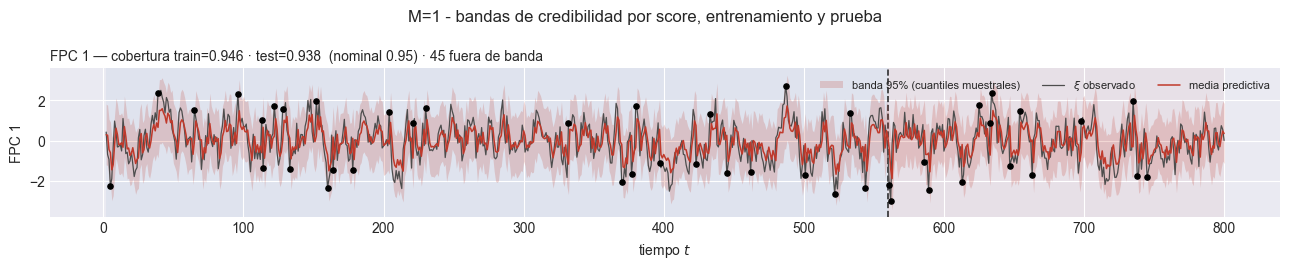

[plot_bandas_serie] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  FPC 1: cob train=0.948 (-0.002) test=0.938 (-0.012) | ancho train=3.025 test=3.022 | 44/799 fuera
  2/2 (100.0%) t=0.0s eta=0.0s  FPC 2: cob train=0.962 (+0.012) test=0.950 (+0.000) | ancho train=3.773 test=3.769 | 33/799 fuera
[plot_bandas_serie] listo: 2 pasos en 0.3s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m02\52_bandas_scores.png


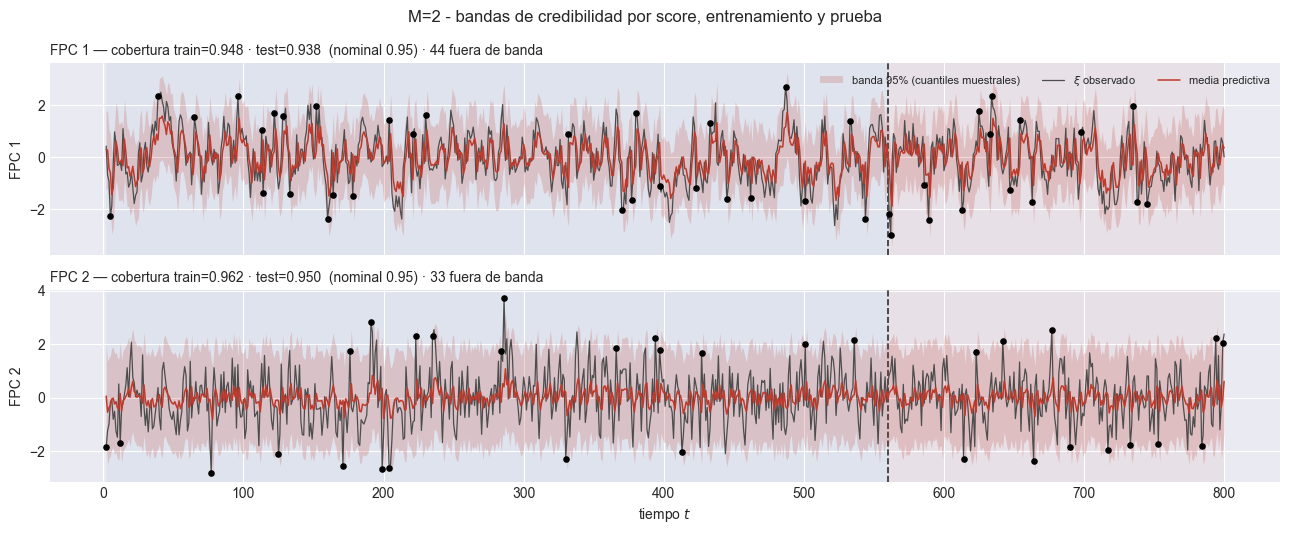

[plot_bandas_serie] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: cob train=0.948 (-0.002) test=0.938 (-0.012) | ancho train=3.031 test=3.028 | 44/799 fuera
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: cob train=0.962 (+0.012) test=0.950 (+0.000) | ancho train=3.783 test=3.77 | 33/799 fuera
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3: cob train=0.946 (-0.004) test=0.958 (+0.008) | ancho train=3.935 test=3.936 | 40/799 fuera
[plot_bandas_serie] listo: 3 pasos en 0.4s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m03\52_bandas_scores.png


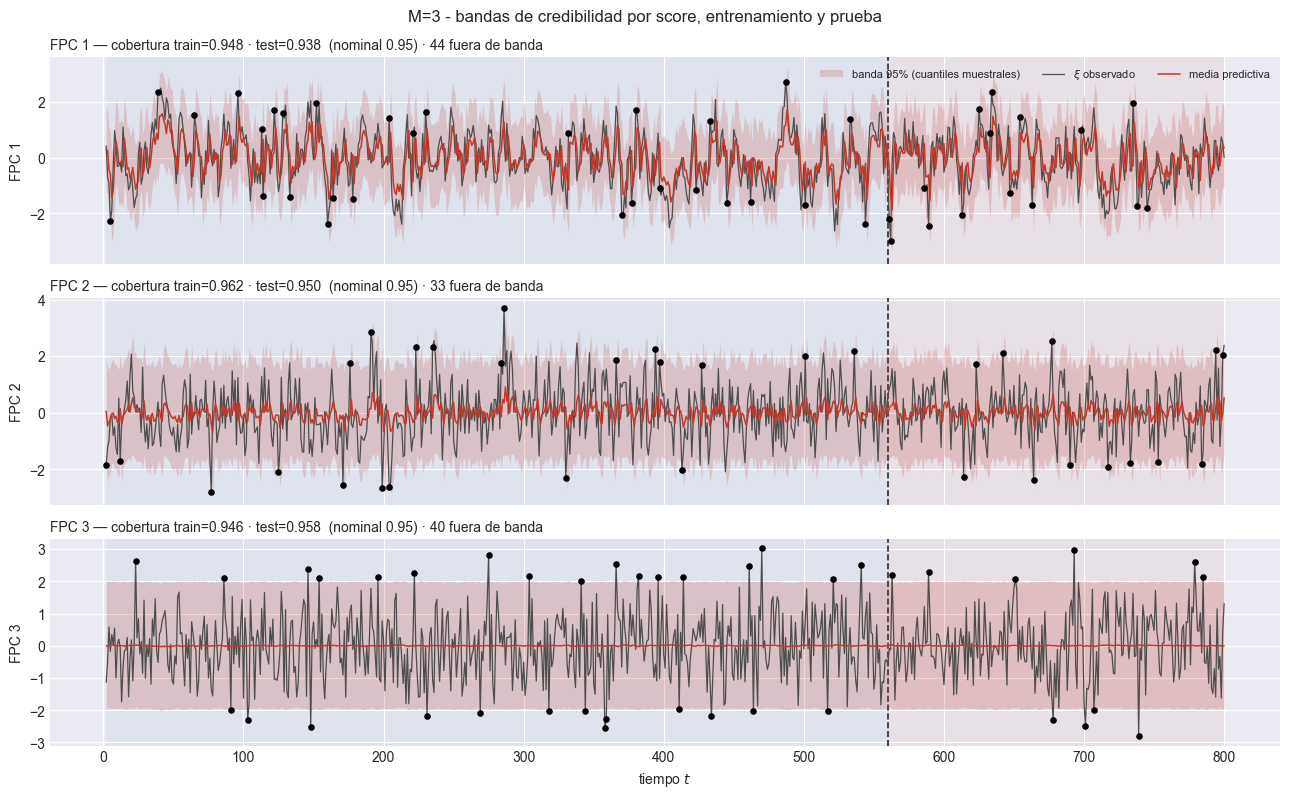

In [51]:
for M in M_OK:
    e = EST[M]
    plot_bandas_serie(
        e["Y_obs"], e["Y_hat"], e["li_s"], e["ls_s"], T0, t=t_orig,
        etiquetas=[f"FPC {i + 1}" for i in e["component_idx"]], nivel=NIVEL,
        title=f"M={M} - bandas de credibilidad por score, entrenamiento y prueba",
        save_path=str(e["paths"]["out_report"] / "52_bandas_scores.png"),
        verbose=True)
    plt.show()

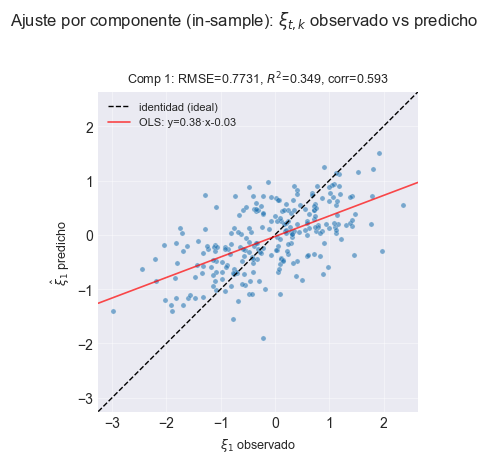

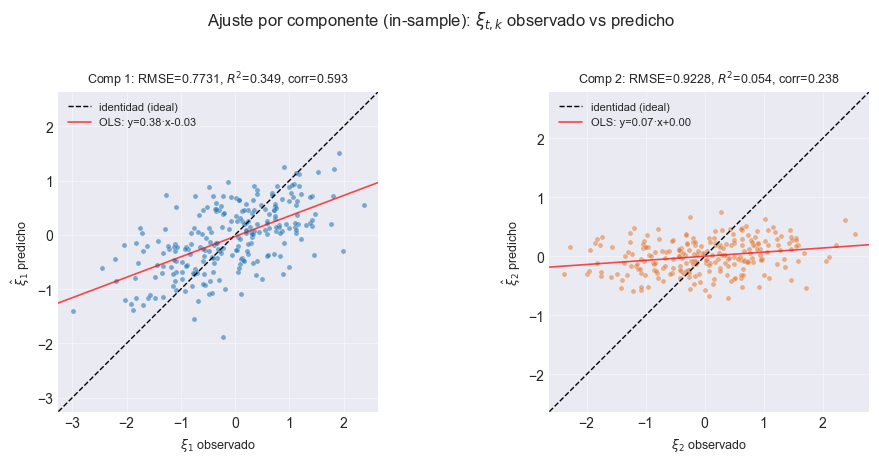

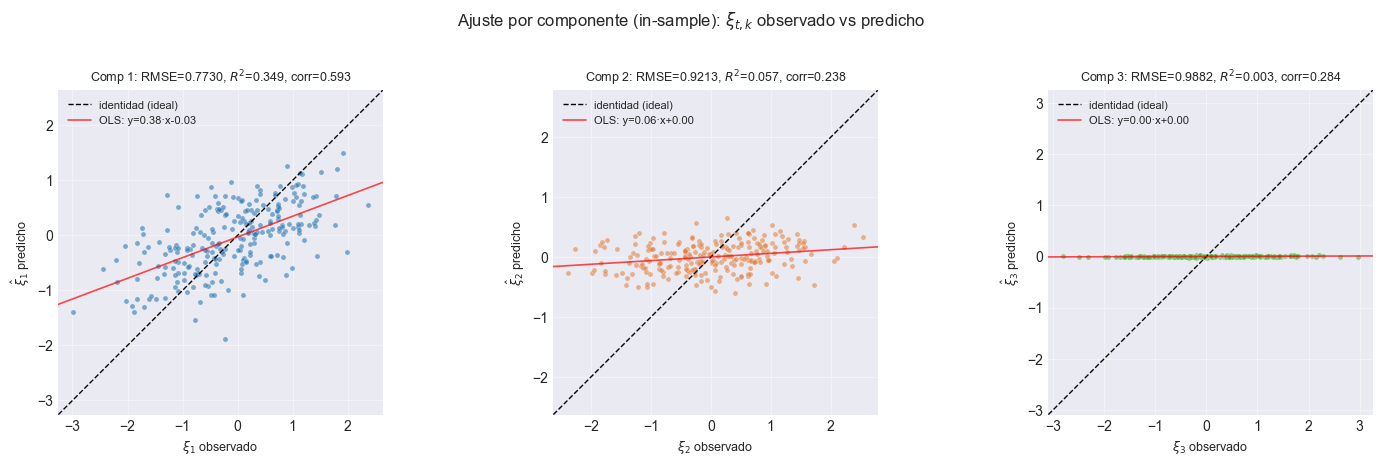

In [52]:
for M in M_OK:
    e = EST[M]
    eval_scatter = {k: {"y_obs": e["Y_obs"][~es_train, k],
                        "y_hat": e["Y_hat"][~es_train, k]}
                    for k in range(e["n_components"])}
    plot_scatter_theta(
        eval_scatter, n_components=e["n_components"],
        save_path=str(e["paths"]["out_report"] / "53_scatter_scores_test.png"))
    plt.show()

## 6. Intervalos de credibilidad sobre la curva

Extractos de la serie funcional cada `CADA` períodos, cada uno con su banda
puntual, la curva verdadera y —en gris— los datos observados, para ver de un
vistazo dónde estaba el ruido que la banda **no** tiene que cubrir.

Como la curva verdadera es la misma en todos los $M$, poner los extractos de
los distintos puntos uno debajo de otro es la comparación visual más directa
del efecto del truncamiento.

[plot_extractos_curvas] inicio (40 pasos)
  1/40 ( 2.5%) t=0.0s eta=0.2s  t=2 [train] cob=0.940 rmse=0.8693
  2/40 ( 5.0%) t=0.0s eta=0.4s  t=22 [train] cob=1.000 rmse=1.152
  4/40 (10.0%) t=0.0s eta=0.4s  t=62 [train] cob=0.940 rmse=0.7055
  6/40 (15.0%) t=0.1s eta=0.4s  t=102 [train] cob=1.000 rmse=0.678
  8/40 (20.0%) t=0.1s eta=0.4s  t=142 [train] cob=0.950 rmse=0.6759
  10/40 (25.0%) t=0.1s eta=0.4s  t=182 [train] cob=0.820 rmse=1.047
  12/40 (30.0%) t=0.1s eta=0.3s  t=222 [train] cob=0.870 rmse=0.8838
  14/40 (35.0%) t=0.2s eta=0.3s  t=262 [train] cob=1.000 rmse=0.15
  16/40 (40.0%) t=0.2s eta=0.3s  t=302 [train] cob=1.000 rmse=0.3385
  18/40 (45.0%) t=0.2s eta=0.3s  t=342 [train] cob=1.000 rmse=0.3517
  20/40 (50.0%) t=0.2s eta=0.2s  t=382 [train] cob=1.000 rmse=0.4128
  22/40 (55.0%) t=0.3s eta=0.2s  t=422 [train] cob=1.000 rmse=0.4495
  24/40 (60.0%) t=0.3s eta=0.2s  t=462 [train] cob=0.500 rmse=1.766
  26/40 (65.0%) t=0.3s eta=0.2s  t=502 [train] cob=0.950 rmse=0.6881
  28/40

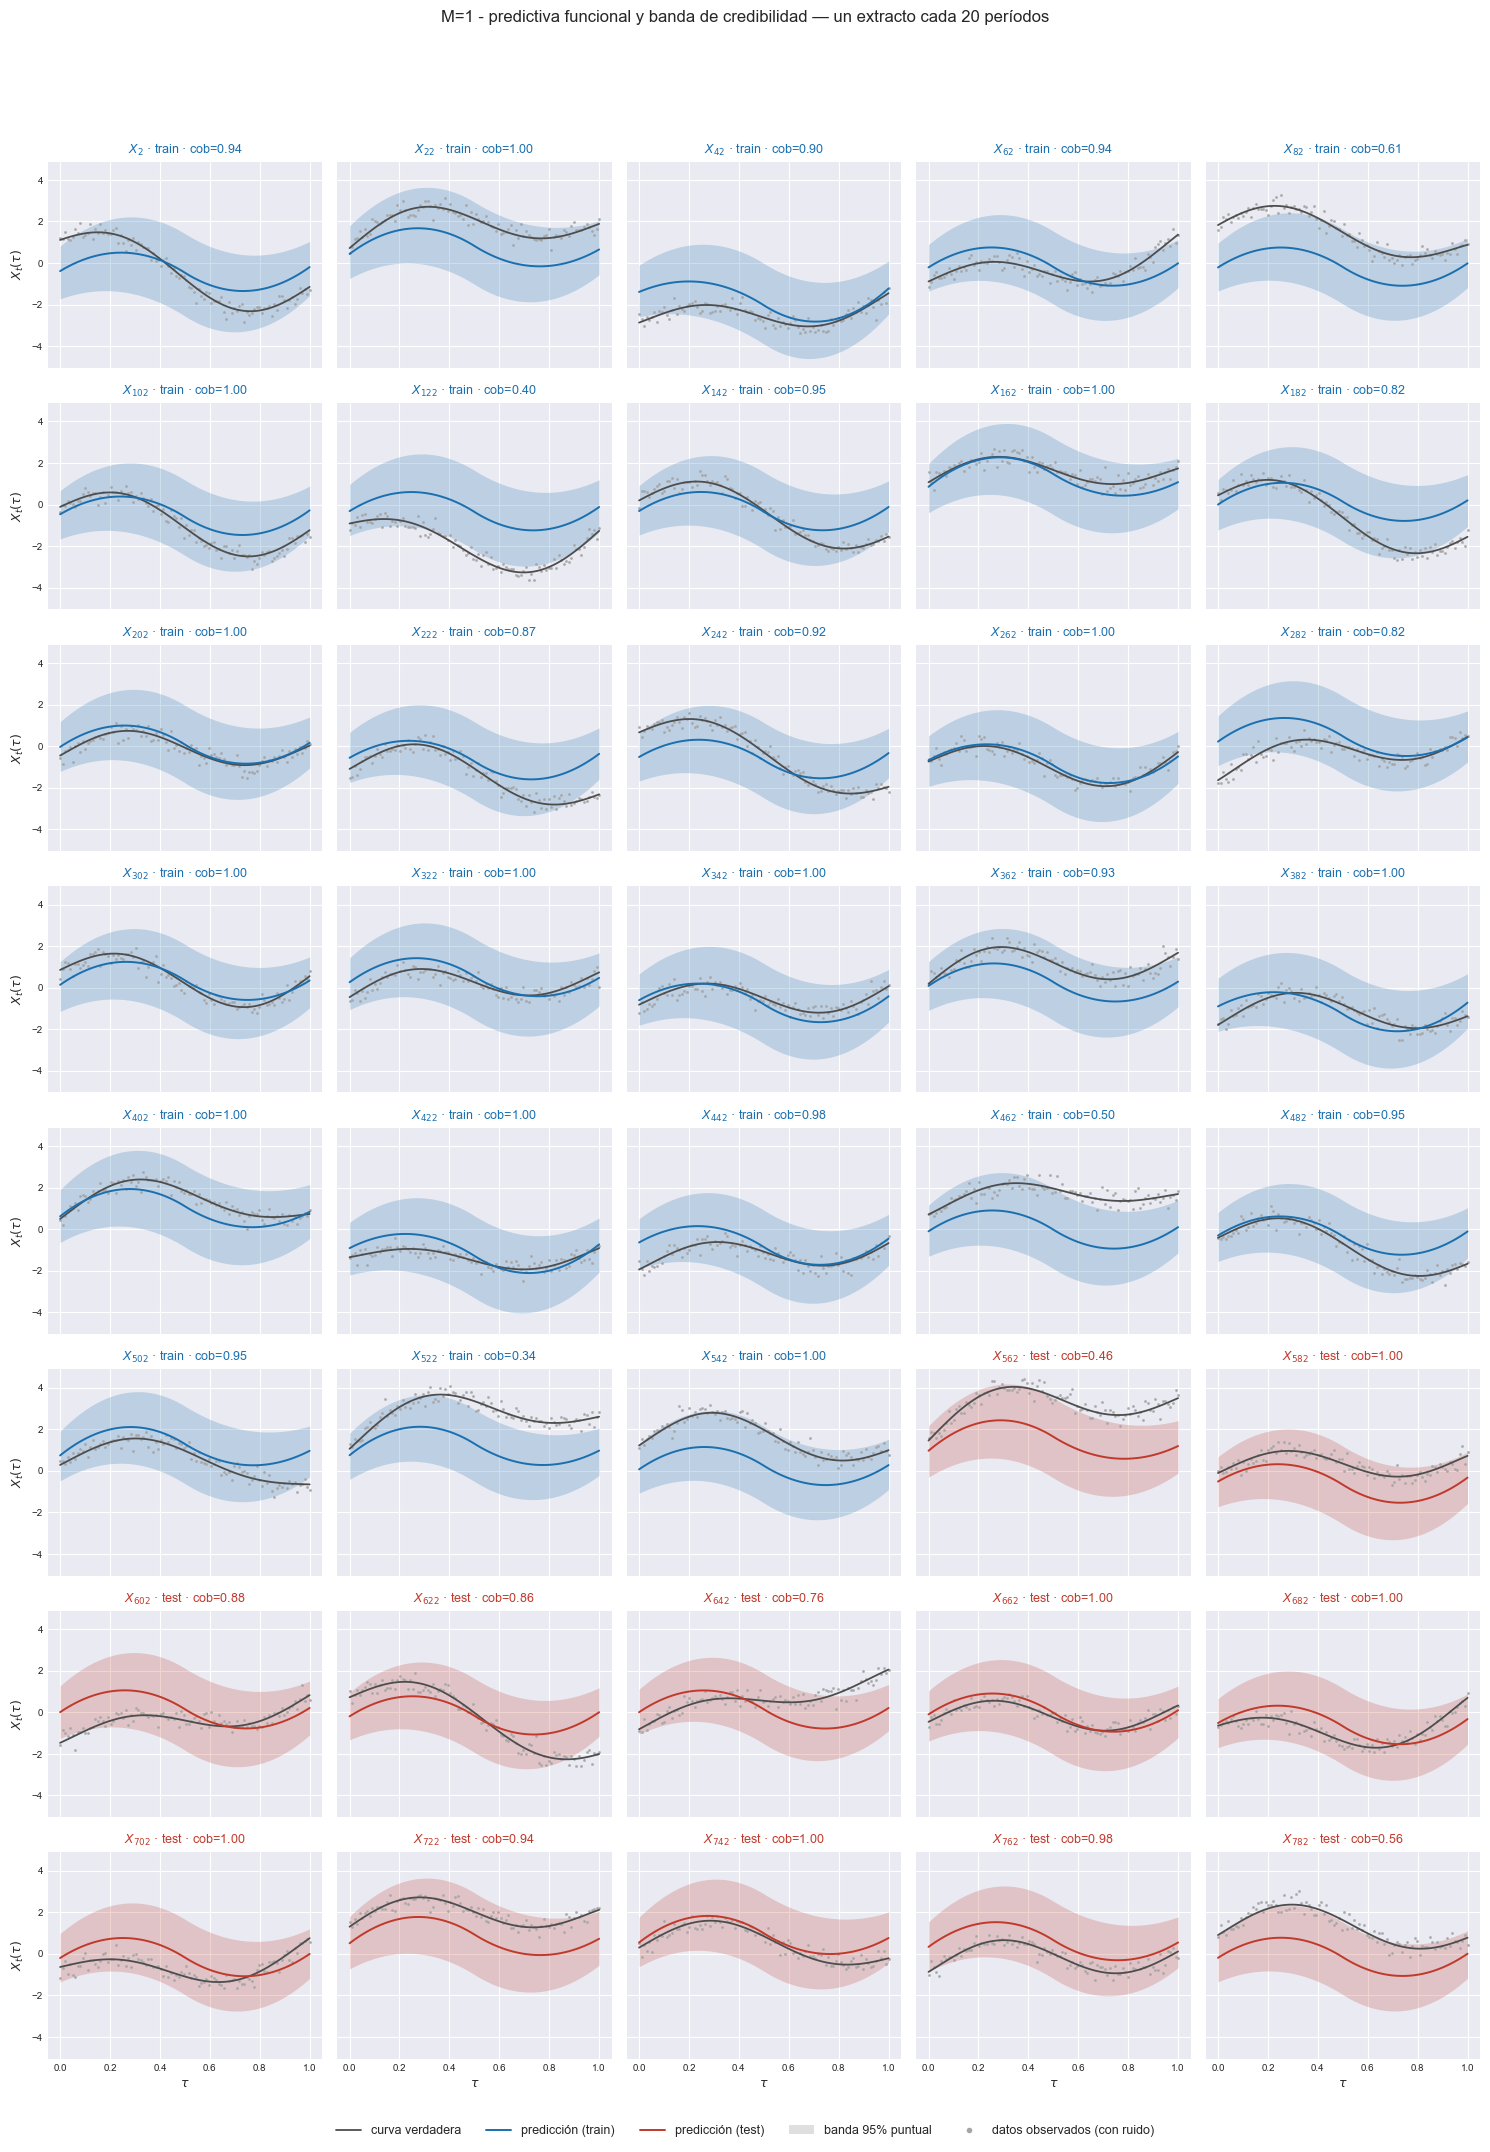

[plot_extractos_curvas] inicio (40 pasos)
  1/40 ( 2.5%) t=0.0s eta=0.1s  t=2 [train] cob=1.000 rmse=0.9061
  2/40 ( 5.0%) t=0.0s eta=0.3s  t=22 [train] cob=1.000 rmse=1.111
  4/40 (10.0%) t=0.0s eta=0.4s  t=62 [train] cob=1.000 rmse=0.8632
  6/40 (15.0%) t=0.1s eta=0.4s  t=102 [train] cob=1.000 rmse=0.503
  8/40 (20.0%) t=0.1s eta=0.3s  t=142 [train] cob=1.000 rmse=0.5481
  10/40 (25.0%) t=0.1s eta=0.3s  t=182 [train] cob=0.990 rmse=1.023
  12/40 (30.0%) t=0.1s eta=0.3s  t=222 [train] cob=0.960 rmse=0.8157
  14/40 (35.0%) t=0.2s eta=0.3s  t=262 [train] cob=1.000 rmse=0.2471
  16/40 (40.0%) t=0.2s eta=0.3s  t=302 [train] cob=1.000 rmse=0.3676
  18/40 (45.0%) t=0.2s eta=0.2s  t=342 [train] cob=1.000 rmse=0.2873
  20/40 (50.0%) t=0.2s eta=0.2s  t=382 [train] cob=1.000 rmse=0.3874
  22/40 (55.0%) t=0.2s eta=0.2s  t=422 [train] cob=1.000 rmse=0.4799
  24/40 (60.0%) t=0.3s eta=0.2s  t=462 [train] cob=0.510 rmse=1.755
  26/40 (65.0%) t=0.3s eta=0.2s  t=502 [train] cob=0.960 rmse=0.7546
  28/

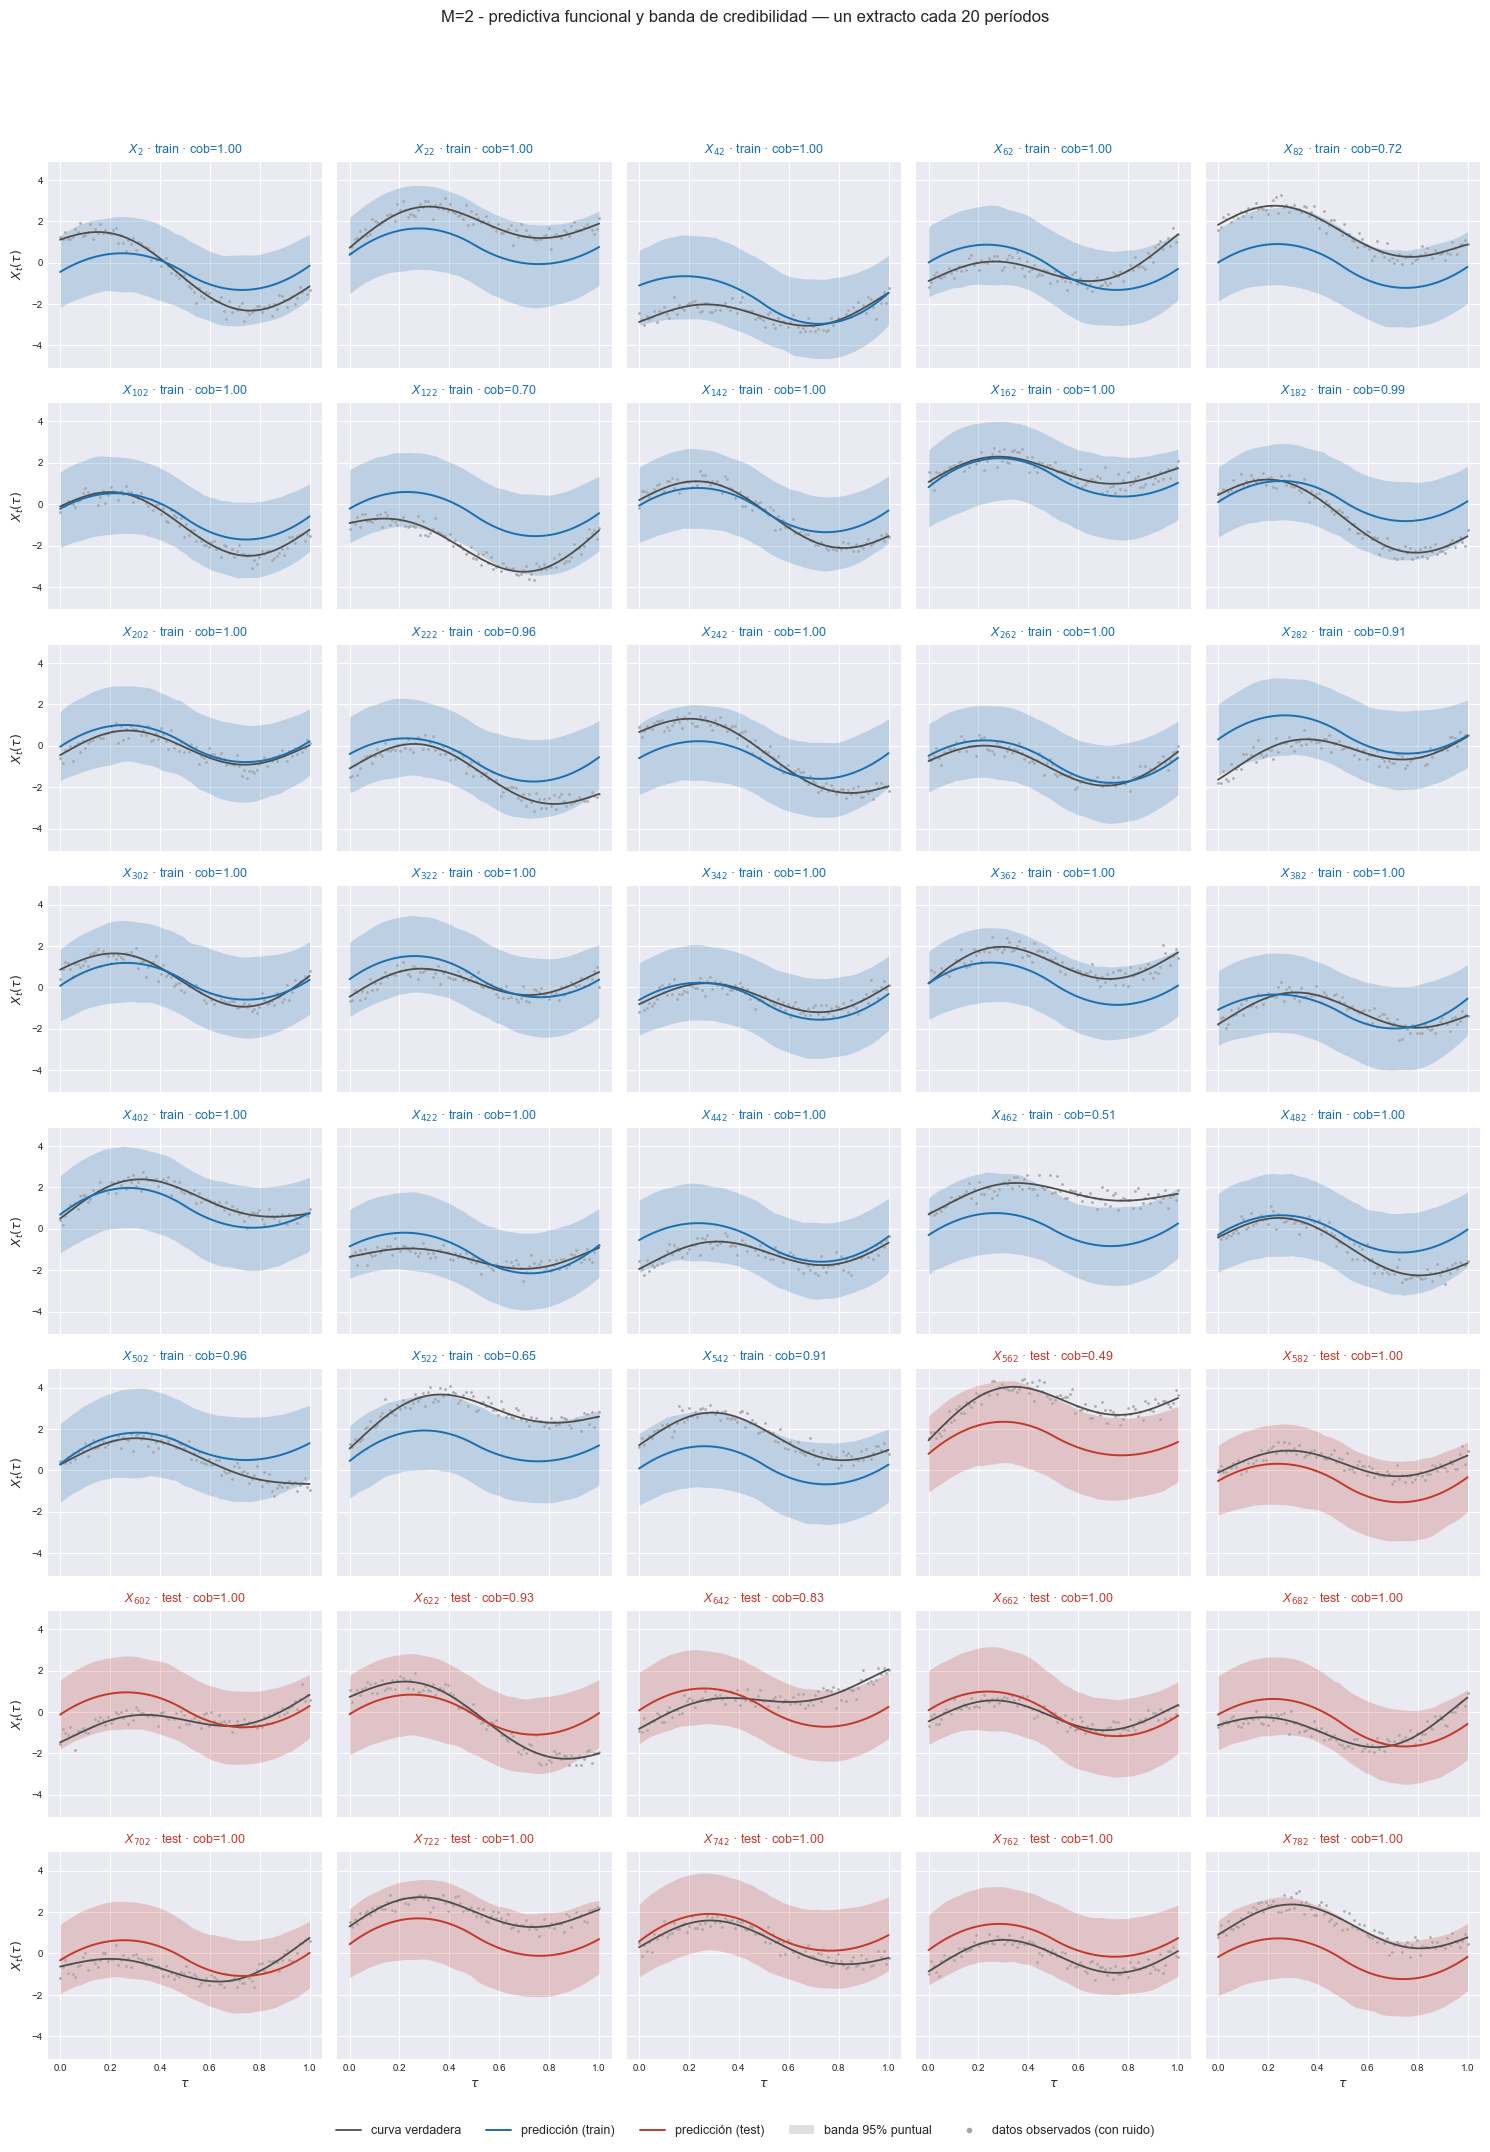

[plot_extractos_curvas] inicio (40 pasos)
  1/40 ( 2.5%) t=0.0s eta=0.1s  t=2 [train] cob=1.000 rmse=0.8812
  2/40 ( 5.0%) t=0.0s eta=0.3s  t=22 [train] cob=1.000 rmse=1.172
  4/40 (10.0%) t=0.0s eta=0.3s  t=62 [train] cob=1.000 rmse=0.7926
  6/40 (15.0%) t=0.1s eta=0.3s  t=102 [train] cob=1.000 rmse=0.556
  8/40 (20.0%) t=0.1s eta=0.3s  t=142 [train] cob=1.000 rmse=0.5681
  10/40 (25.0%) t=0.1s eta=0.3s  t=182 [train] cob=1.000 rmse=1.028
  12/40 (30.0%) t=0.1s eta=0.3s  t=222 [train] cob=1.000 rmse=0.8281
  14/40 (35.0%) t=0.1s eta=0.3s  t=262 [train] cob=1.000 rmse=0.2249
  16/40 (40.0%) t=0.2s eta=0.3s  t=302 [train] cob=1.000 rmse=0.391
  18/40 (45.0%) t=0.2s eta=0.2s  t=342 [train] cob=1.000 rmse=0.3082
  20/40 (50.0%) t=0.2s eta=0.2s  t=382 [train] cob=1.000 rmse=0.4013
  22/40 (55.0%) t=0.5s eta=0.4s  t=422 [train] cob=1.000 rmse=0.4695
  24/40 (60.0%) t=0.5s eta=0.4s  t=462 [train] cob=0.570 rmse=1.737
  26/40 (65.0%) t=0.6s eta=0.3s  t=502 [train] cob=1.000 rmse=0.71
  28/40 

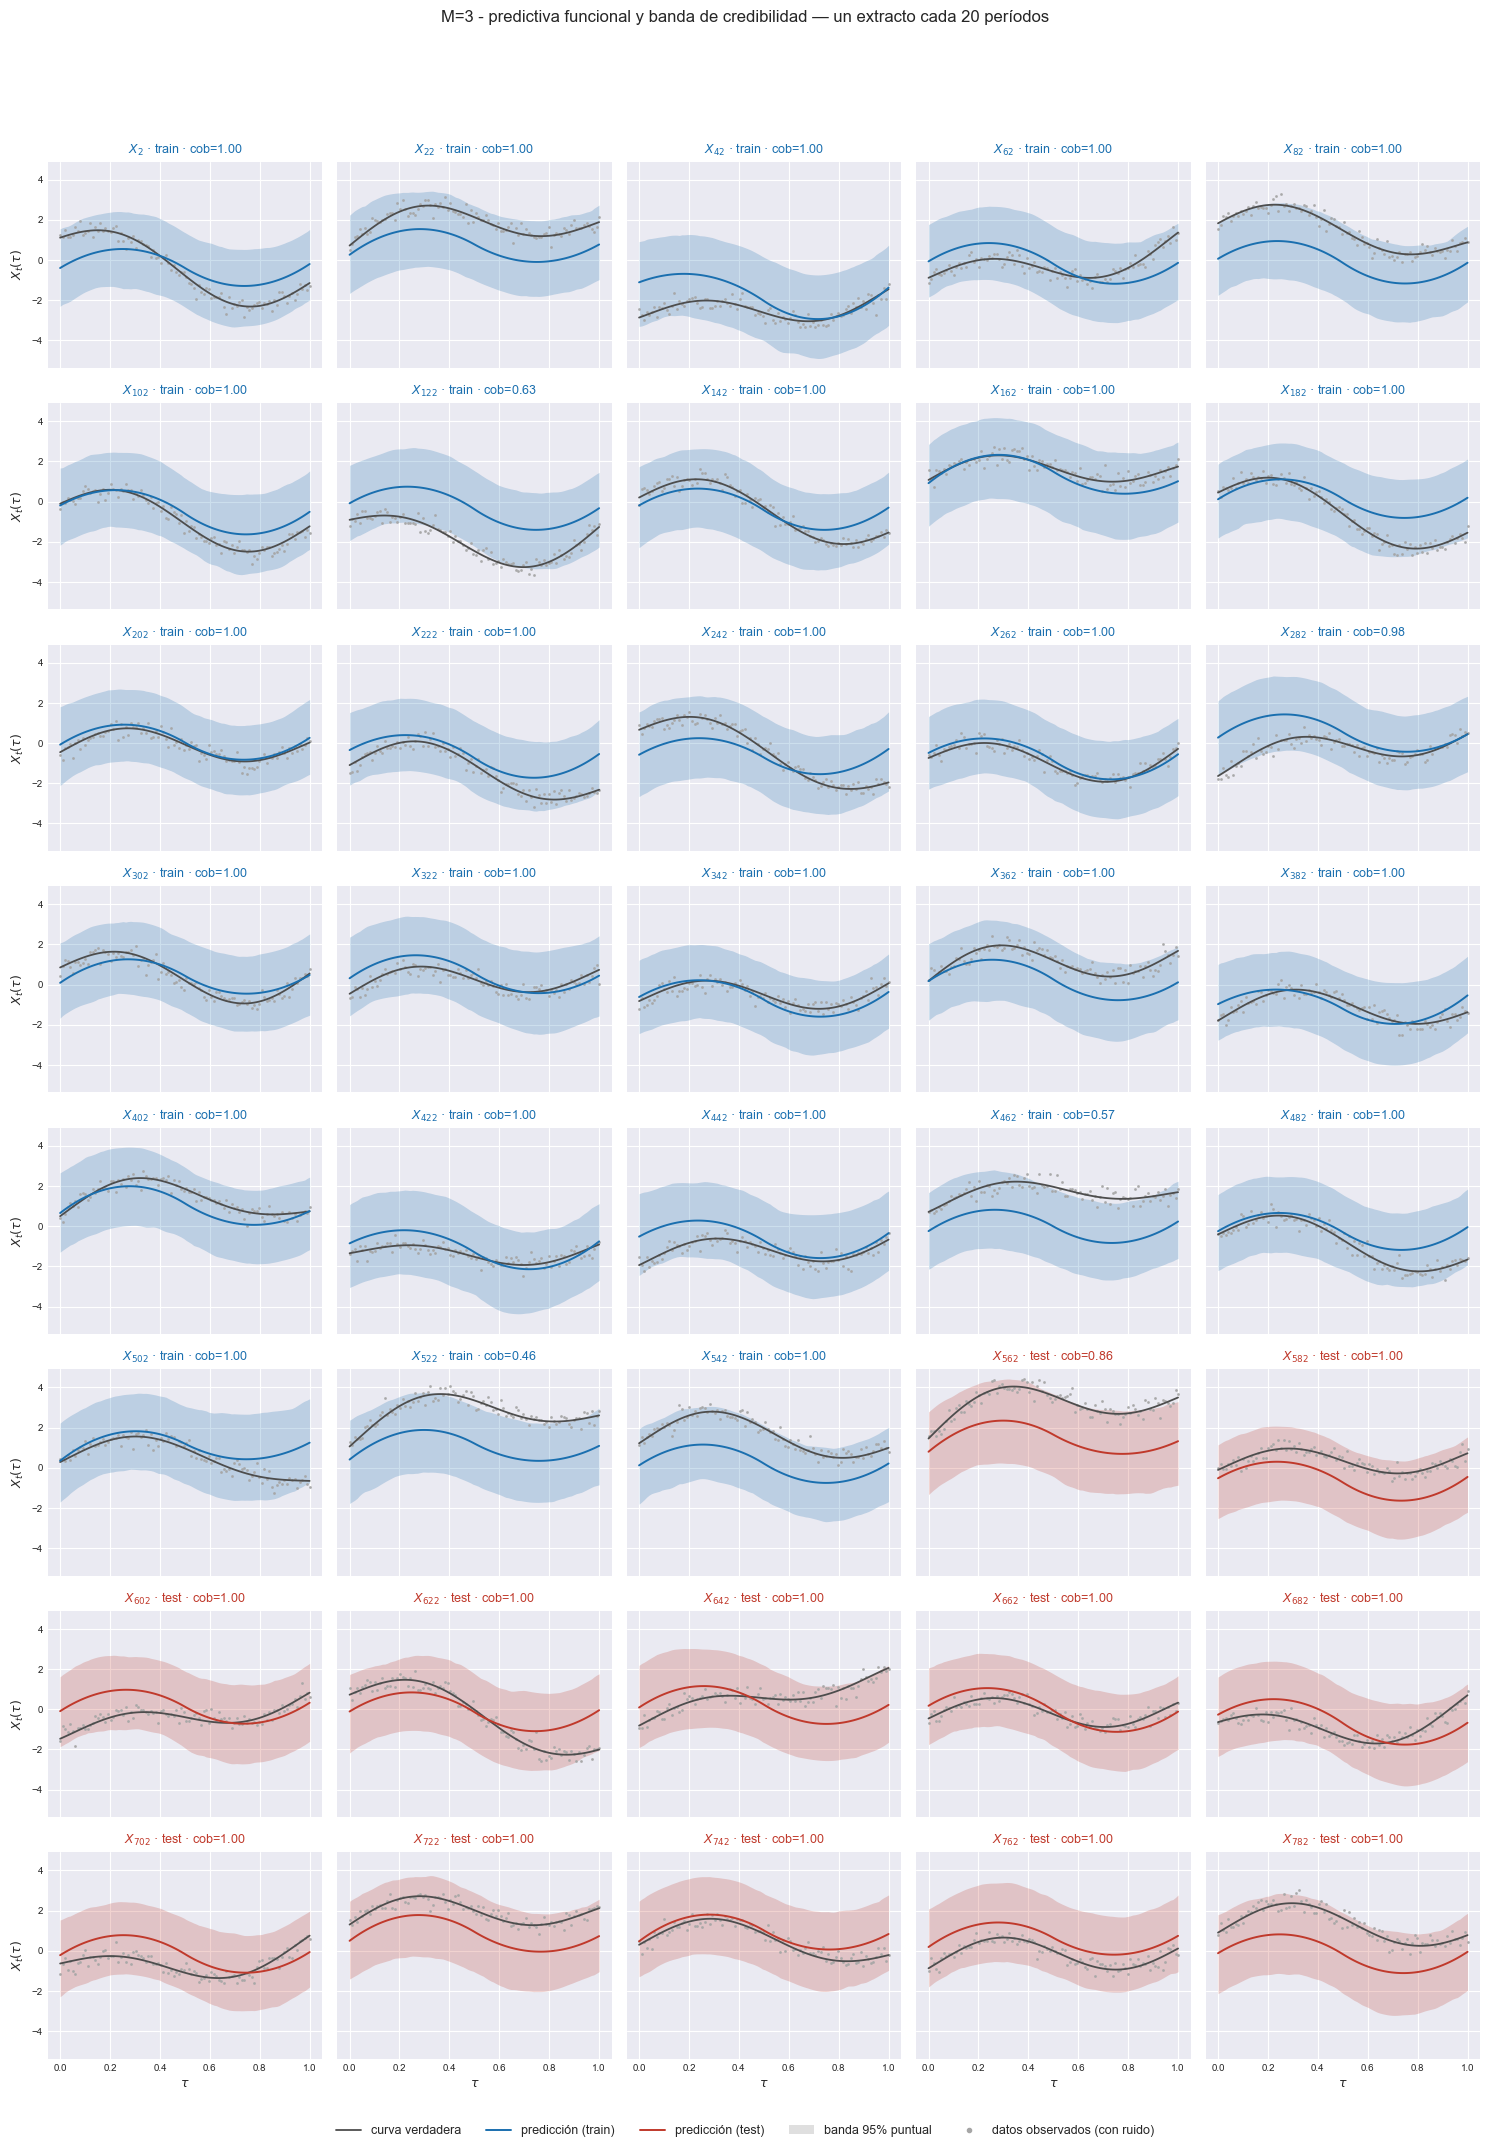

In [53]:
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev, e["X_pred"], e["li_f"], e["ls_f"], grilla, T0, t=t_orig,
        cada=CADA, n_col=5, nivel=NIVEL, X_obs=X_obs_ev,
        title=f"M={M} - predictiva funcional y banda de credibilidad",
        save_path=str(e["paths"]["out_report"] / "54_extractos_curvas.png"),
        verbose=True)
    plt.show()

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=557 [train] cob=0.580 rmse=1.397
  2/7 (28.6%) t=0.0s eta=0.0s  t=558 [train] cob=0.820 rmse=1.32
  3/7 (42.9%) t=0.0s eta=0.0s  t=559 [train] cob=1.000 rmse=0.2882
  4/7 (57.1%) t=0.0s eta=0.0s  t=560 [train] cob=0.910 rmse=0.9927
  5/7 (71.4%) t=0.0s eta=0.0s  t=561 [test] cob=0.390 rmse=1.968
  6/7 (85.7%) t=0.0s eta=0.0s  t=562 [test] cob=0.460 rmse=1.804
  7/7 (100.0%) t=0.0s eta=0.0s  t=563 [test] cob=0.620 rmse=1.993
[plot_extractos_curvas] listo: 7 pasos en 0.9s  cob media train=0.828 test=0.490 (nominal 0.95)


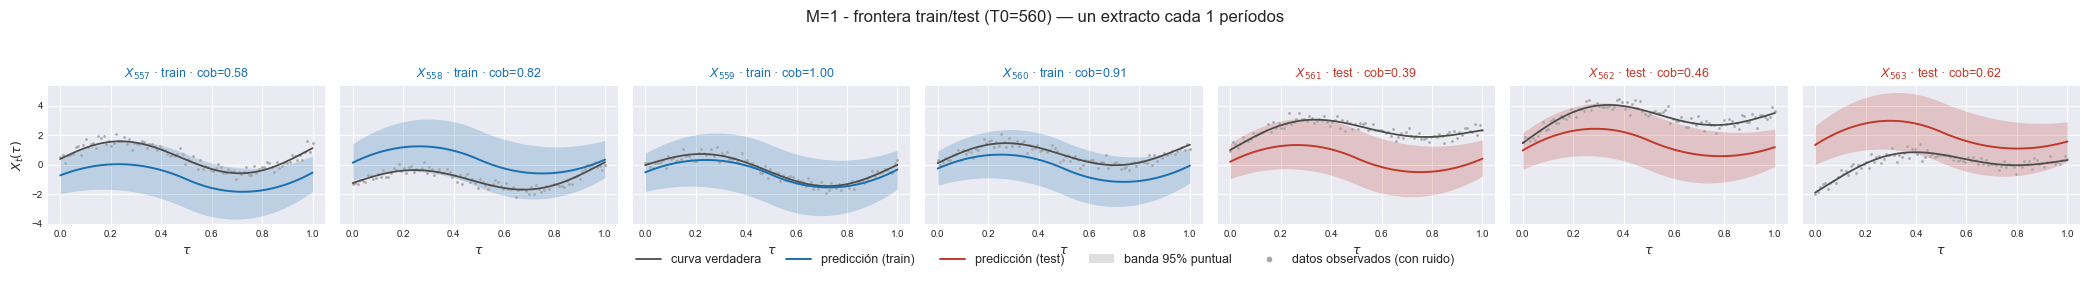

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=557 [train] cob=0.910 rmse=1.433
  2/7 (28.6%) t=0.0s eta=0.0s  t=558 [train] cob=1.000 rmse=1.294
  3/7 (42.9%) t=0.0s eta=0.0s  t=559 [train] cob=1.000 rmse=0.3945
  4/7 (57.1%) t=0.0s eta=0.0s  t=560 [train] cob=1.000 rmse=0.9735
  5/7 (71.4%) t=0.0s eta=0.0s  t=561 [test] cob=0.420 rmse=1.921
  6/7 (85.7%) t=0.0s eta=0.0s  t=562 [test] cob=0.490 rmse=1.755
  7/7 (100.0%) t=0.0s eta=0.0s  t=563 [test] cob=0.740 rmse=2.009
[plot_extractos_curvas] listo: 7 pasos en 0.6s  cob media train=0.978 test=0.550 (nominal 0.95)


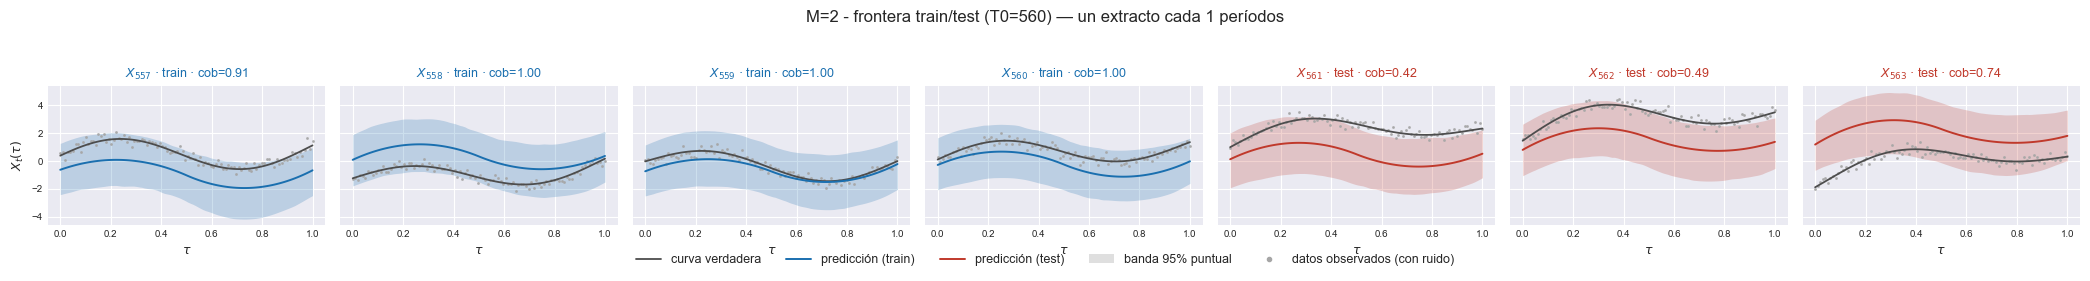

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=557 [train] cob=1.000 rmse=1.371
  2/7 (28.6%) t=0.0s eta=0.0s  t=558 [train] cob=1.000 rmse=1.341
  3/7 (42.9%) t=0.0s eta=0.0s  t=559 [train] cob=1.000 rmse=0.3811
  4/7 (57.1%) t=0.0s eta=0.0s  t=560 [train] cob=1.000 rmse=0.9777
  5/7 (71.4%) t=0.0s eta=0.0s  t=561 [test] cob=0.370 rmse=1.928
  6/7 (85.7%) t=0.0s eta=0.0s  t=562 [test] cob=0.860 rmse=1.779
  7/7 (100.0%) t=0.0s eta=0.0s  t=563 [test] cob=0.720 rmse=1.958
[plot_extractos_curvas] listo: 7 pasos en 0.6s  cob media train=1.000 test=0.650 (nominal 0.95)


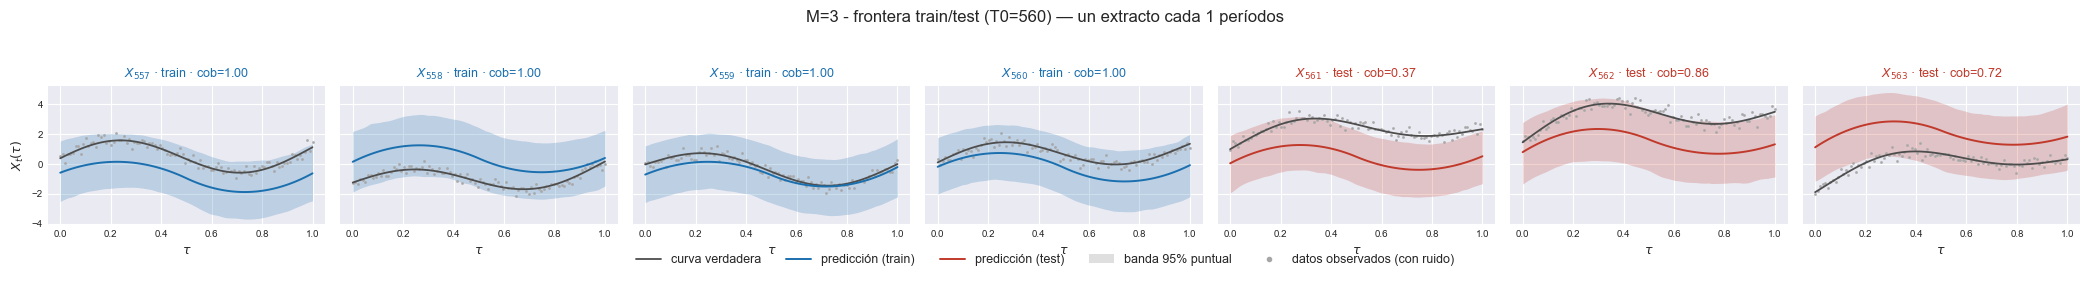

In [54]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
# Es donde se ve, curva a curva, si la banda se ensancha al salir de muestra.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))

for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_true_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel],
        grilla, T0, t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL,
        X_obs=X_obs_ev[sel],
        title=f"M={M} - frontera train/test (T0={T0})",
        save_path=str(e["paths"]["out_report"] / "55_extractos_frontera.png"),
        verbose=True)
    plt.show()

## 7. Ventana móvil

El modelo **no se reentrena**: lo que se desliza es la ventana de evaluación.
Cada punto agrega las métricas de $w$ orígenes consecutivos, todos a $h=1$ con
los rezagos reales. Se superponen varios anchos para que la conclusión no
dependa de un $w$ elegido a dedo; las ventanas que **cruzan** $T_0$ van
punteadas, porque su cifra mezcla dentro y fuera de muestra.

[ventana_movil_scores[FPC 1, w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=1.0s  t=11 [train] rmse=0.7521
  39/780 ( 5.0%) t=0.0s eta=0.1s  t=49 [train] rmse=0.6807
  78/780 (10.0%) t=0.0s eta=0.1s  t=88 [train] rmse=0.7946
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] rmse=0.8048
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] rmse=0.8272
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] rmse=0.8211
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] rmse=0.5651
  273/780 (35.0%) t=0.0s eta=0.1s  t=283 [train] rmse=0.7044
  312/780 (40.0%) t=0.0s eta=0.0s  t=322 [train] rmse=0.7801
  351/780 (45.0%) t=0.0s eta=0.0s  t=361 [train] rmse=0.8163
  390/780 (50.0%) t=0.0s eta=0.0s  t=400 [train] rmse=0.7703
  429/780 (55.0%) t=0.0s eta=0.0s  t=439 [train] rmse=0.8336
  468/780 (60.0%) t=0.0s eta=0.0s  t=478 [train] rmse=0.7295
  507/780 (65.0%) t=0.1s eta=0.0s  t=517 [train] rmse=0.7971
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] rmse=0.9486
  585/780 (75.0%) t=0.1s eta=0.0s  t=

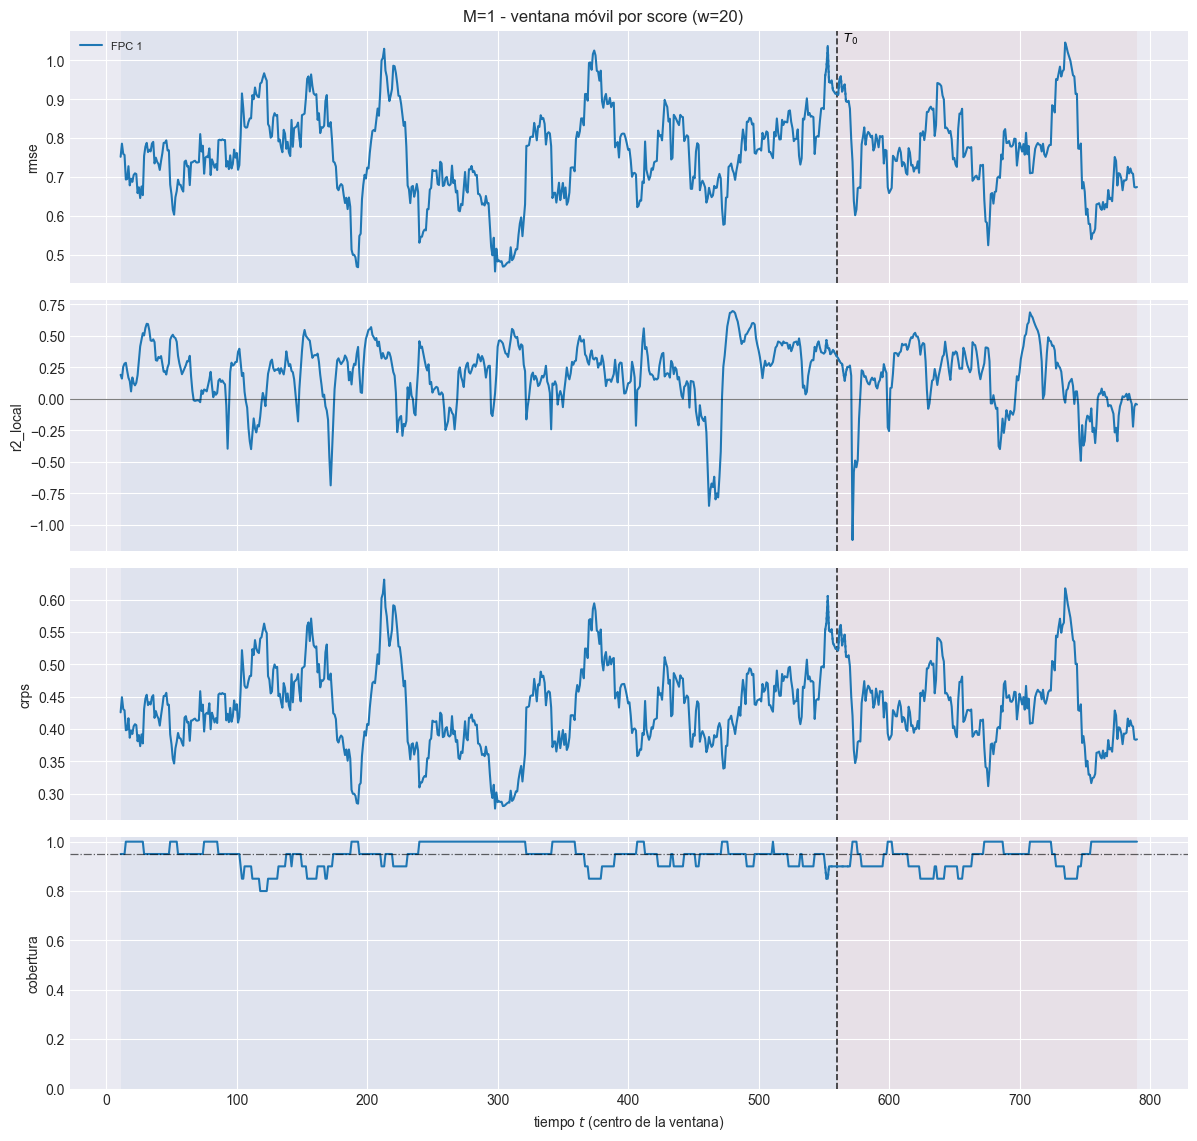

[ventana_movil_scores[FPC 1, w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=1.1s  t=11 [train] rmse=0.7525
  39/780 ( 5.0%) t=0.0s eta=0.1s  t=49 [train] rmse=0.6817
  78/780 (10.0%) t=0.0s eta=0.1s  t=88 [train] rmse=0.7943
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] rmse=0.8047
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] rmse=0.8274
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] rmse=0.822
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] rmse=0.5649
  273/780 (35.0%) t=0.0s eta=0.1s  t=283 [train] rmse=0.7041
  312/780 (40.0%) t=0.0s eta=0.1s  t=322 [train] rmse=0.7798
  351/780 (45.0%) t=0.0s eta=0.0s  t=361 [train] rmse=0.8166
  390/780 (50.0%) t=0.0s eta=0.0s  t=400 [train] rmse=0.7717
  429/780 (55.0%) t=0.0s eta=0.0s  t=439 [train] rmse=0.8333
  468/780 (60.0%) t=0.0s eta=0.0s  t=478 [train] rmse=0.7305
  507/780 (65.0%) t=0.1s eta=0.0s  t=517 [train] rmse=0.7979
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] rmse=0.9485
  585/780 (75.0%) t=0.1s eta=0.0s  t=5

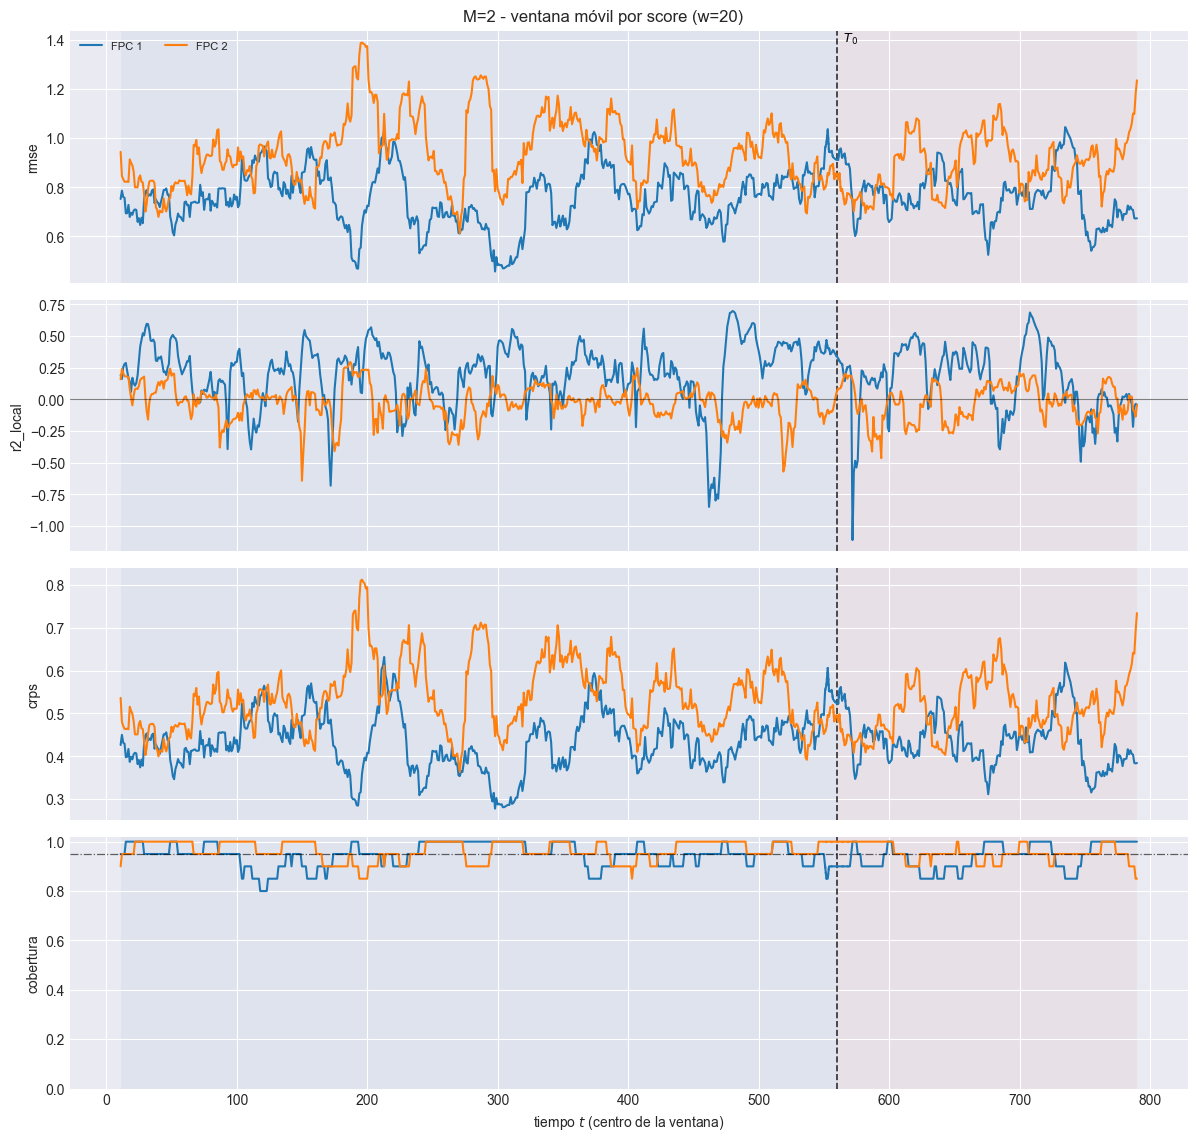

[ventana_movil_scores[FPC 1, w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=1.0s  t=11 [train] rmse=0.7522
  39/780 ( 5.0%) t=0.0s eta=0.1s  t=49 [train] rmse=0.6834
  78/780 (10.0%) t=0.0s eta=0.1s  t=88 [train] rmse=0.7945
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] rmse=0.8046
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] rmse=0.8271
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] rmse=0.8223
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] rmse=0.5651
  273/780 (35.0%) t=0.0s eta=0.1s  t=283 [train] rmse=0.7041
  312/780 (40.0%) t=0.0s eta=0.0s  t=322 [train] rmse=0.7793
  351/780 (45.0%) t=0.0s eta=0.0s  t=361 [train] rmse=0.8167
  390/780 (50.0%) t=0.0s eta=0.0s  t=400 [train] rmse=0.7721
  429/780 (55.0%) t=0.0s eta=0.0s  t=439 [train] rmse=0.833
  468/780 (60.0%) t=0.0s eta=0.0s  t=478 [train] rmse=0.7314
  507/780 (65.0%) t=0.0s eta=0.0s  t=517 [train] rmse=0.7981
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] rmse=0.9485
  585/780 (75.0%) t=0.1s eta=0.0s  t=5

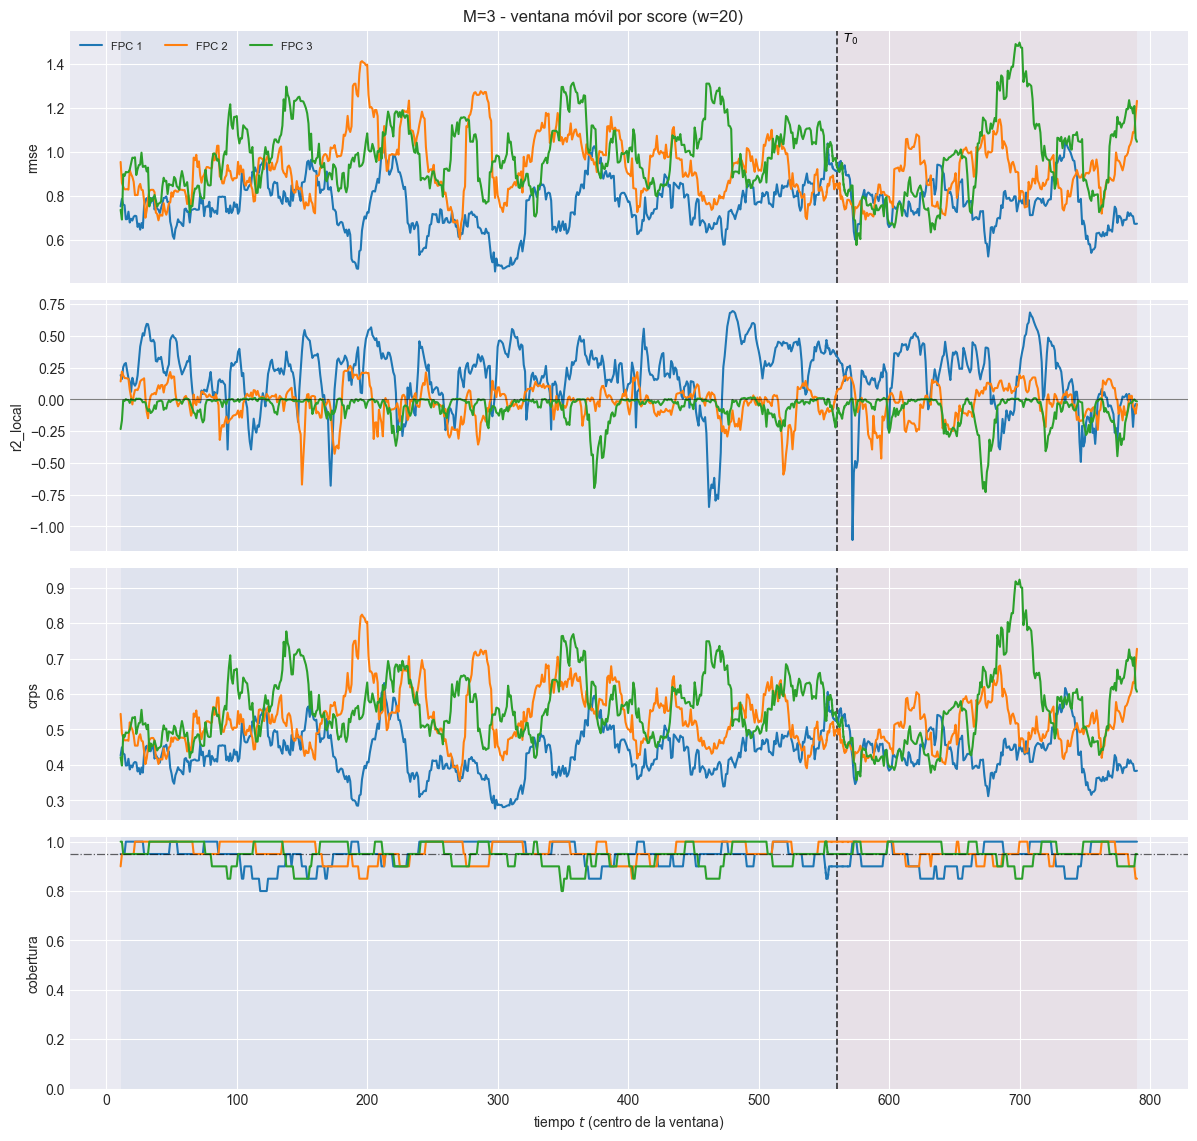

In [55]:
# `verbose` sólo en el ancho de referencia: con todos los anchos y todos los M
# la salida serían miles de líneas.
for M in M_OK:
    e = EST[M]
    etiquetas = [f"FPC {i + 1}" for i in e["component_idx"]]
    tablas_score = {
        w: ventana_movil_scores(
            e["Y_obs"], e["Y_hat"], T0_orig, w=w, muestras=e["SC_draws"],
            li=e["li_s"], ls=e["ls_s"], t_offset=N_LAGS,
            etiquetas=etiquetas, verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_score"] = tablas_score
    tablas_score[W_REF].to_csv(
        e["paths"]["out_report"] / f"56_ventana_scores_w{W_REF}.csv", index=False)

    plot_ventana_movil(
        tablas_score[W_REF], T0, ["rmse", "r2_local", "crps", "cobertura"],
        columna_grupo="componente",
        title=f"M={M} - ventana móvil por score (w={W_REF})",
        save_path=str(e["paths"]["out_report"] / "56_ventana_scores.png"),
        verbose=True)
    plt.show()

[ventana_movil_funcional[w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=1.1s  t=11 [train] mise=0.9607
  39/780 ( 5.0%) t=0.0s eta=0.1s  t=49 [train] mise=0.7557
  78/780 (10.0%) t=0.0s eta=0.1s  t=88 [train] mise=0.9348
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] mise=1.041
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] mise=1.11
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] mise=1.216
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] mise=0.7532
  273/780 (35.0%) t=0.0s eta=0.1s  t=283 [train] mise=1.082
  312/780 (40.0%) t=0.0s eta=0.1s  t=322 [train] mise=0.9645
  351/780 (45.0%) t=0.0s eta=0.1s  t=361 [train] mise=1.136
  390/780 (50.0%) t=0.1s eta=0.1s  t=400 [train] mise=0.9366
  429/780 (55.0%) t=0.1s eta=0.0s  t=439 [train] mise=1.084
  468/780 (60.0%) t=0.1s eta=0.0s  t=478 [train] mise=0.8584
  507/780 (65.0%) t=0.1s eta=0.0s  t=517 [train] mise=1.126
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] mise=1.304
  585/780 (75.0%) t=0.1s eta=0.0s  t=595 [test] mi

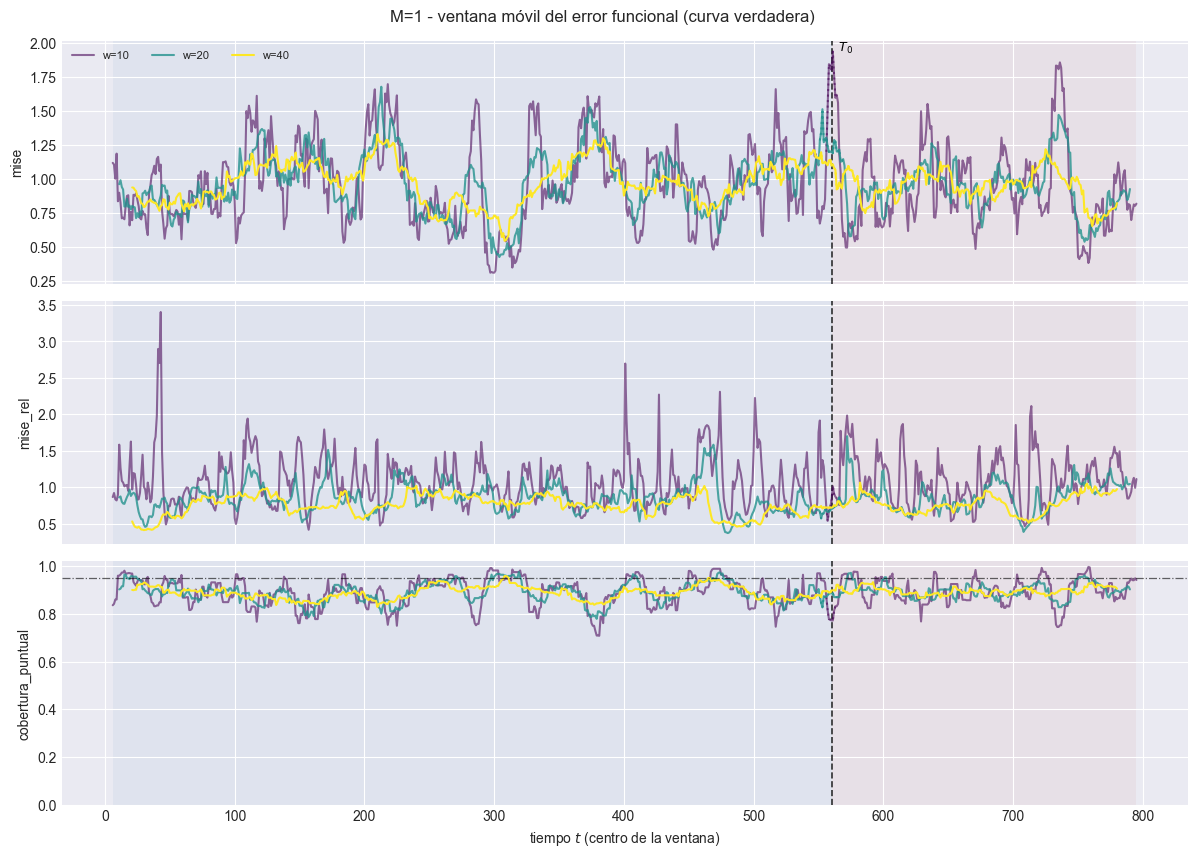

[ventana_movil_funcional[w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=1.1s  t=11 [train] mise=0.9059
  39/780 ( 5.0%) t=0.0s eta=0.1s  t=49 [train] mise=0.7291
  78/780 (10.0%) t=0.0s eta=0.1s  t=88 [train] mise=0.952
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] mise=0.9854
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] mise=1.081
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] mise=1.139
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] mise=0.6856
  273/780 (35.0%) t=0.0s eta=0.1s  t=283 [train] mise=0.9728
  312/780 (40.0%) t=0.0s eta=0.1s  t=322 [train] mise=0.9544
  351/780 (45.0%) t=0.0s eta=0.1s  t=361 [train] mise=1.132
  390/780 (50.0%) t=0.1s eta=0.1s  t=400 [train] mise=0.9306
  429/780 (55.0%) t=0.1s eta=0.0s  t=439 [train] mise=1.088
  468/780 (60.0%) t=0.1s eta=0.0s  t=478 [train] mise=0.8329
  507/780 (65.0%) t=0.1s eta=0.0s  t=517 [train] mise=1.086
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] mise=1.295
  585/780 (75.0%) t=0.1s eta=0.0s  t=595 [test] 

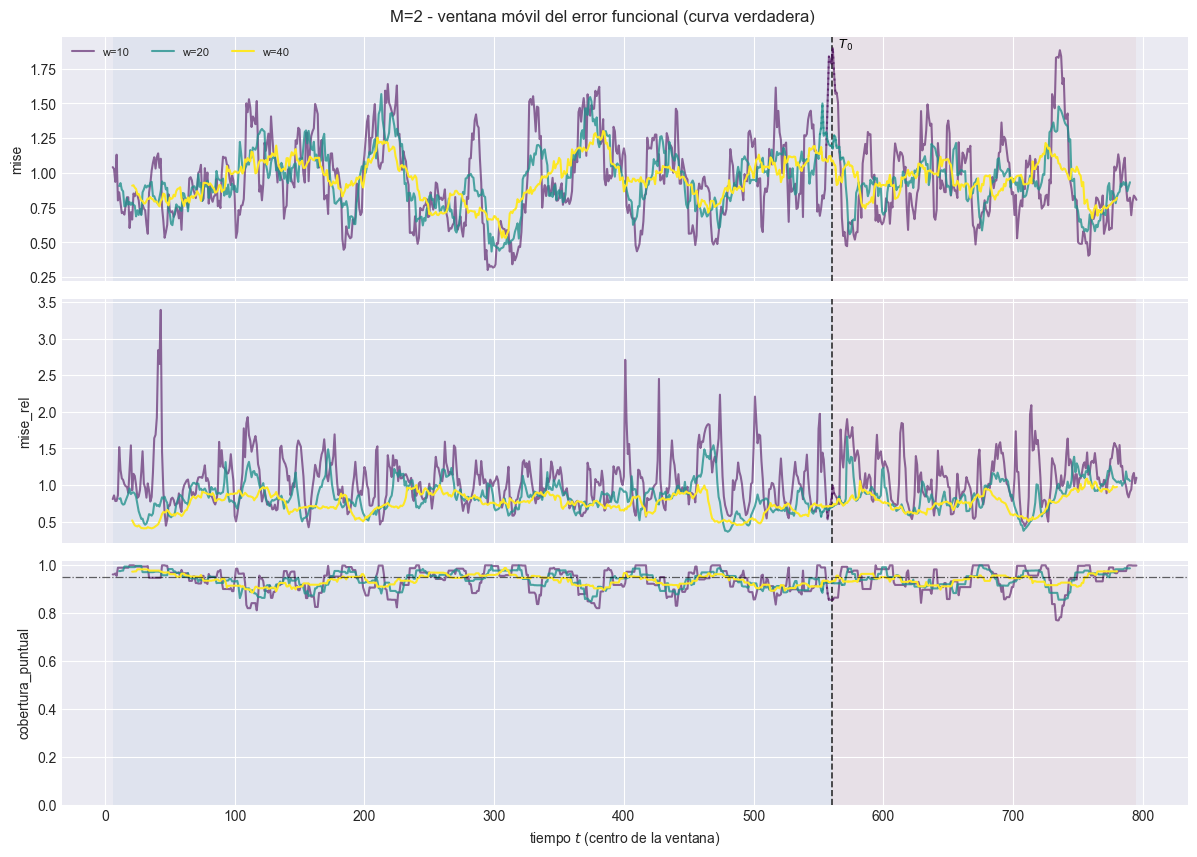

[ventana_movil_funcional[w=20]] inicio (780 pasos)
  1/780 ( 0.1%) t=0.0s eta=1.1s  t=11 [train] mise=0.9513
  39/780 ( 5.0%) t=0.0s eta=0.1s  t=49 [train] mise=0.727
  78/780 (10.0%) t=0.0s eta=0.1s  t=88 [train] mise=0.9529
  117/780 (15.0%) t=0.0s eta=0.1s  t=127 [train] mise=1.008
  156/780 (20.0%) t=0.0s eta=0.1s  t=166 [train] mise=1.078
  195/780 (25.0%) t=0.0s eta=0.1s  t=205 [train] mise=1.135
  234/780 (30.0%) t=0.0s eta=0.1s  t=244 [train] mise=0.6858
  273/780 (35.0%) t=0.0s eta=0.1s  t=283 [train] mise=0.9951
  312/780 (40.0%) t=0.0s eta=0.1s  t=322 [train] mise=0.9433
  351/780 (45.0%) t=0.0s eta=0.1s  t=361 [train] mise=1.114
  390/780 (50.0%) t=0.1s eta=0.1s  t=400 [train] mise=0.9696
  429/780 (55.0%) t=0.1s eta=0.0s  t=439 [train] mise=1.074
  468/780 (60.0%) t=0.1s eta=0.0s  t=478 [train] mise=0.8739
  507/780 (65.0%) t=0.1s eta=0.0s  t=517 [train] mise=1.079
  546/780 (70.0%) t=0.1s eta=0.0s  t=556 [train] mise=1.281
  585/780 (75.0%) t=0.1s eta=0.0s  t=595 [test] m

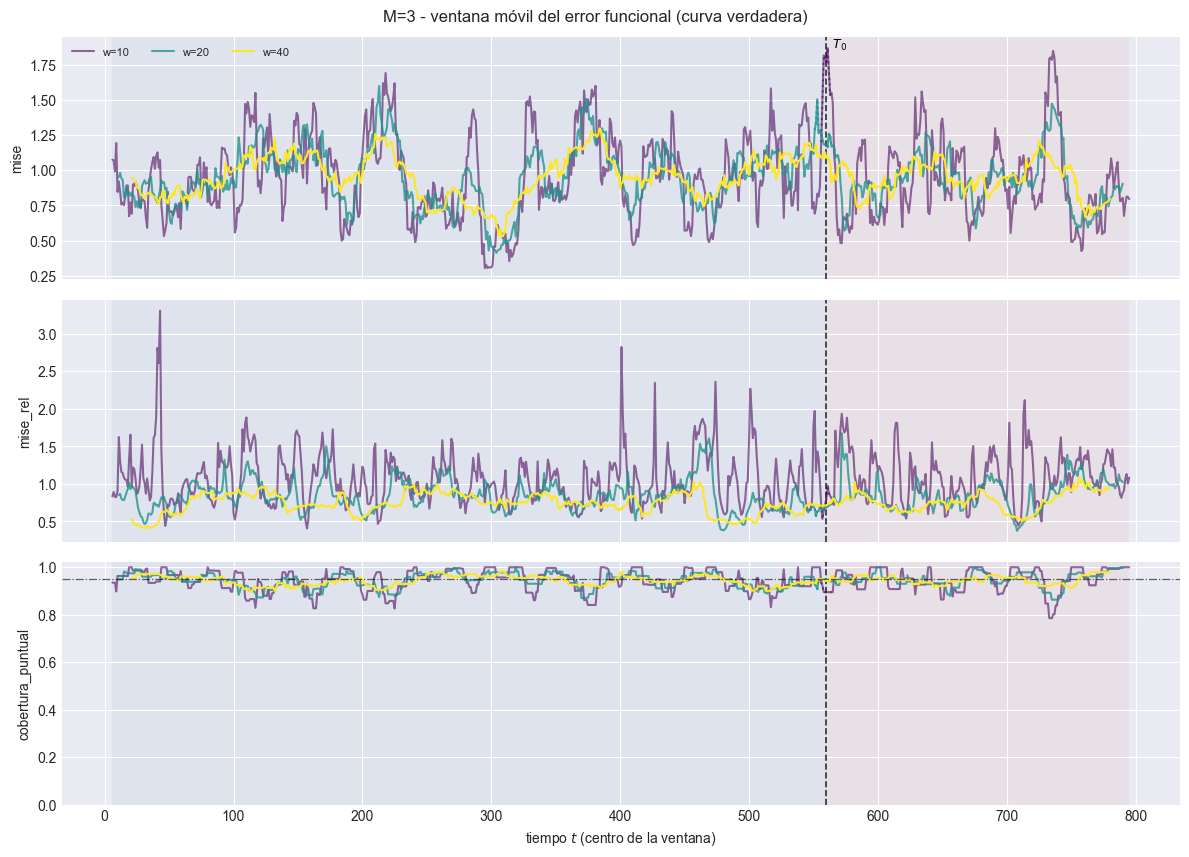

In [56]:
for M in M_OK:
    e = EST[M]
    tablas_fun = {
        w: ventana_movil_funcional(X_true_ev, e["X_pred"], grilla, T0_orig, w=w,
                                   li=e["li_f"], ls=e["ls_f"], t_offset=N_LAGS,
                                   pesos_tau=PESOS_TAU, q_extremo=Q_EXTREMO,
                                   nivel=NIVEL, bloque_A=True,
                                   verbose=(w == W_REF))
        for w in VENTANAS_W
    }
    e["tablas_fun"] = tablas_fun
    tablas_fun[W_REF].to_csv(
        e["paths"]["out_report"] / f"57_ventana_funcional_w{W_REF}.csv", index=False)

    plot_ventana_movil(
        tablas_fun[W_REF], T0, ["mise", "mise_rel", "cobertura_puntual"],
        tablas_por_w=tablas_fun,
        title=f"M={M} - ventana móvil del error funcional (curva verdadera)",
        save_path=str(e["paths"]["out_report"] / "57_ventana_funcional.png"),
        verbose=True)
    plt.show()

[plot_ventana_movil] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.1s  mae_f: w=10 train=0.7851  w=10 test=0.7526  w=20 train=0.7907  w=20 test=0.7733  w=40 train=0.7948  w=40 test=0.7796
  2/6 (33.3%) t=0.0s eta=0.1s  rmse_f: w=10 train=0.9681  w=10 test=0.9307  w=20 train=0.9779  w=20 test=0.9619  w=40 train=0.9891  w=40 test=0.9716
  3/6 (50.0%) t=0.0s eta=0.0s  q95_abs: w=10 train=1.281  w=10 test=1.234  w=20 train=1.277  w=20 test=1.235  w=40 train=1.275  w=40 test=1.228
  4/6 (66.7%) t=0.0s eta=0.0s  winkler: w=10 train=4.716  w=10 test=4.337  w=20 train=5.016  w=20 test=4.881  w=40 train=5.136  w=40 test=5.099
  5/6 (83.3%) t=0.1s eta=0.0s  picp: w=10 train=0.898  w=10 test=0.9  w=20 train=0.8905  w=20 test=0.9  w=40 train=0.8888  w=40 test=0.8952
  6/6 (100.0%) t=0.1s eta=0.0s  mpiw: w=10 train=3.287  w=10 test=3.283  w=20 train=3.282  w=20 test=3.288  w=40 train=3.28  w=40 test=3.286
[plot_ventana_movil] listo: 6 pasos en 0.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_pa

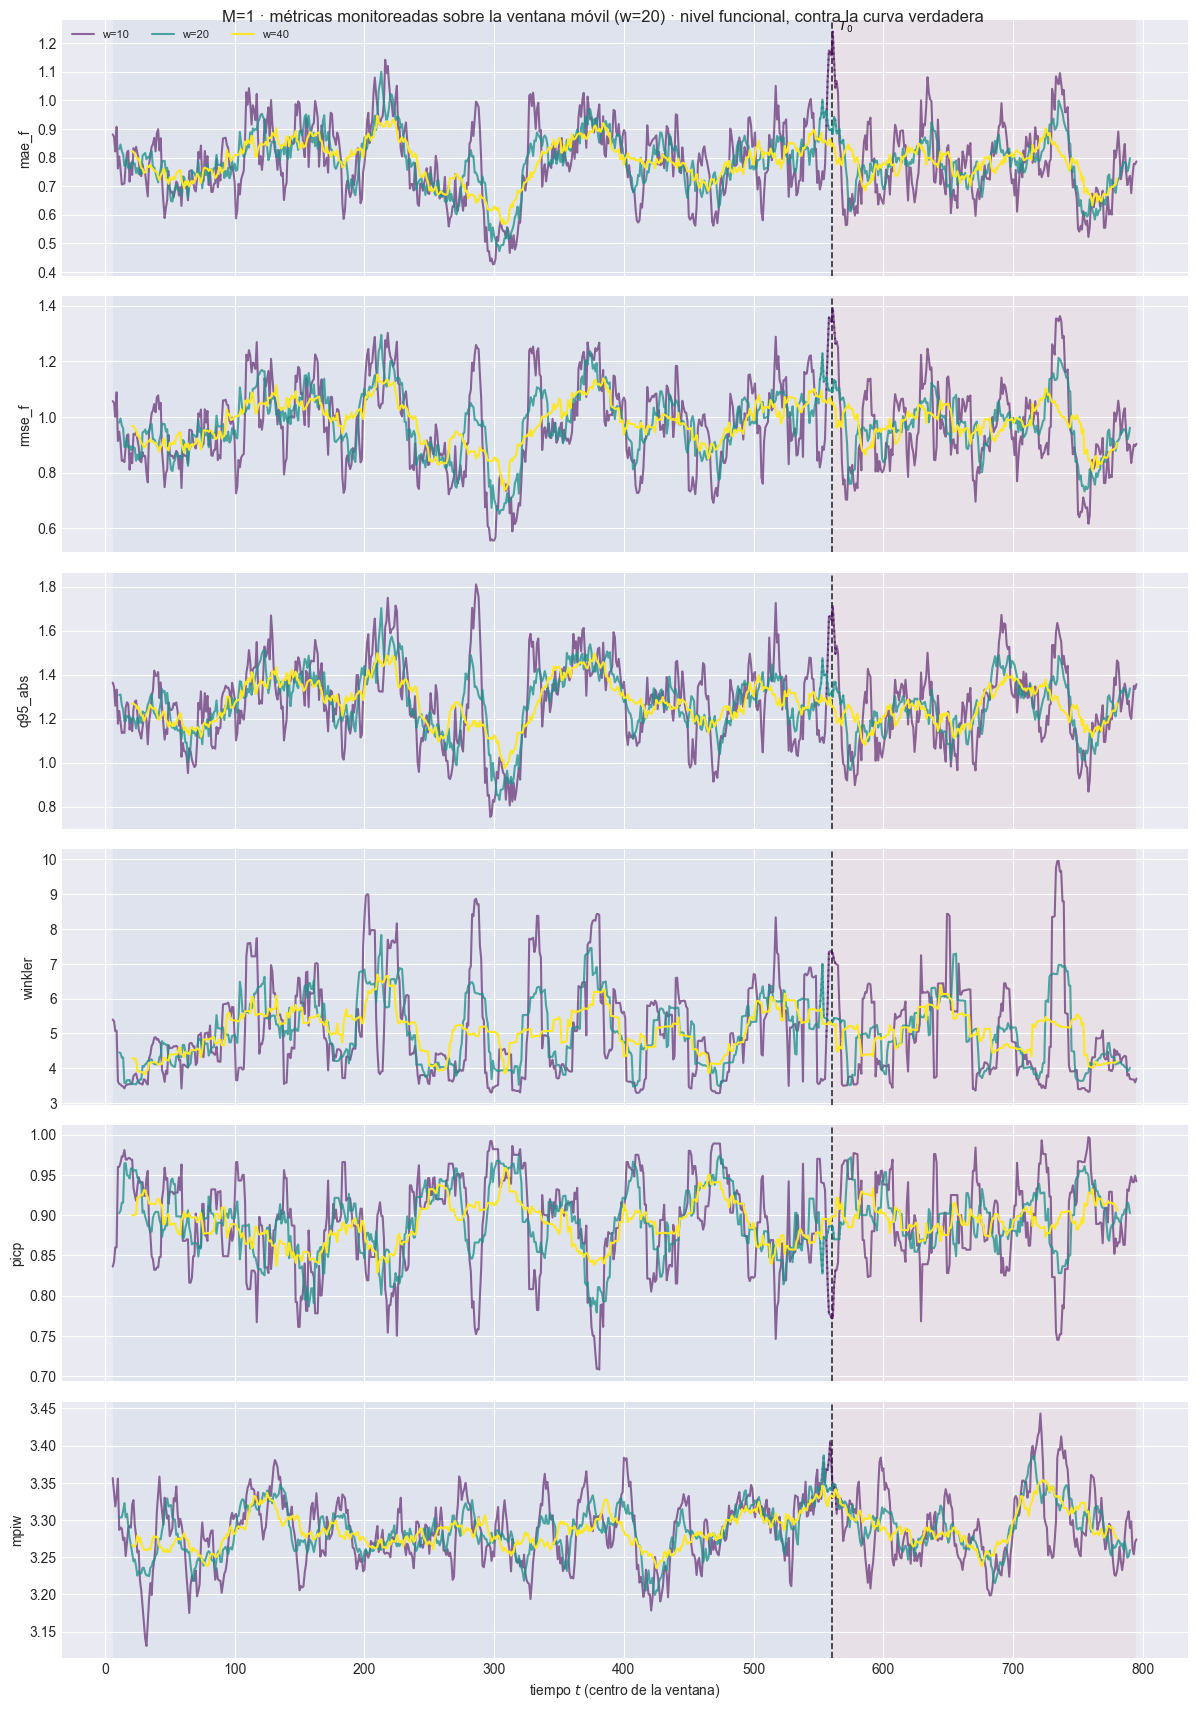

[M=1] cadena L^1 <= L^2 <= L^inf verificada en las 780 ventanas de w=20
[plot_ventana_movil] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.1s  mae_f: w=10 train=0.7796  w=10 test=0.7557  w=20 train=0.7794  w=20 test=0.7726  w=40 train=0.7892  w=40 test=0.7769
  2/6 (33.3%) t=0.0s eta=0.1s  rmse_f: w=10 train=0.9597  w=10 test=0.9282  w=20 train=0.9695  w=20 test=0.9625  w=40 train=0.9773  w=40 test=0.9667
  3/6 (50.0%) t=0.0s eta=0.0s  q95_abs: w=10 train=1.283  w=10 test=1.221  w=20 train=1.268  w=20 test=1.228  w=40 train=1.265  w=40 test=1.227
  4/6 (66.7%) t=0.0s eta=0.0s  winkler: w=10 train=4.158  w=10 test=4.256  w=20 train=4.525  w=20 test=4.536  w=40 train=4.497  w=40 test=4.584
  5/6 (83.3%) t=0.1s eta=0.0s  picp: w=10 train=0.949  w=10 test=0.957  w=20 train=0.942  w=20 test=0.9485  w=40 train=0.9397  w=40 test=0.9427
  6/6 (100.0%) t=0.1s eta=0.0s  mpiw: w=10 train=3.732  w=10 test=3.707  w=20 train=3.736  w=20 test=3.708  w=40 train=3.737  w=40 test=3.71
[plot_ventana_movil]

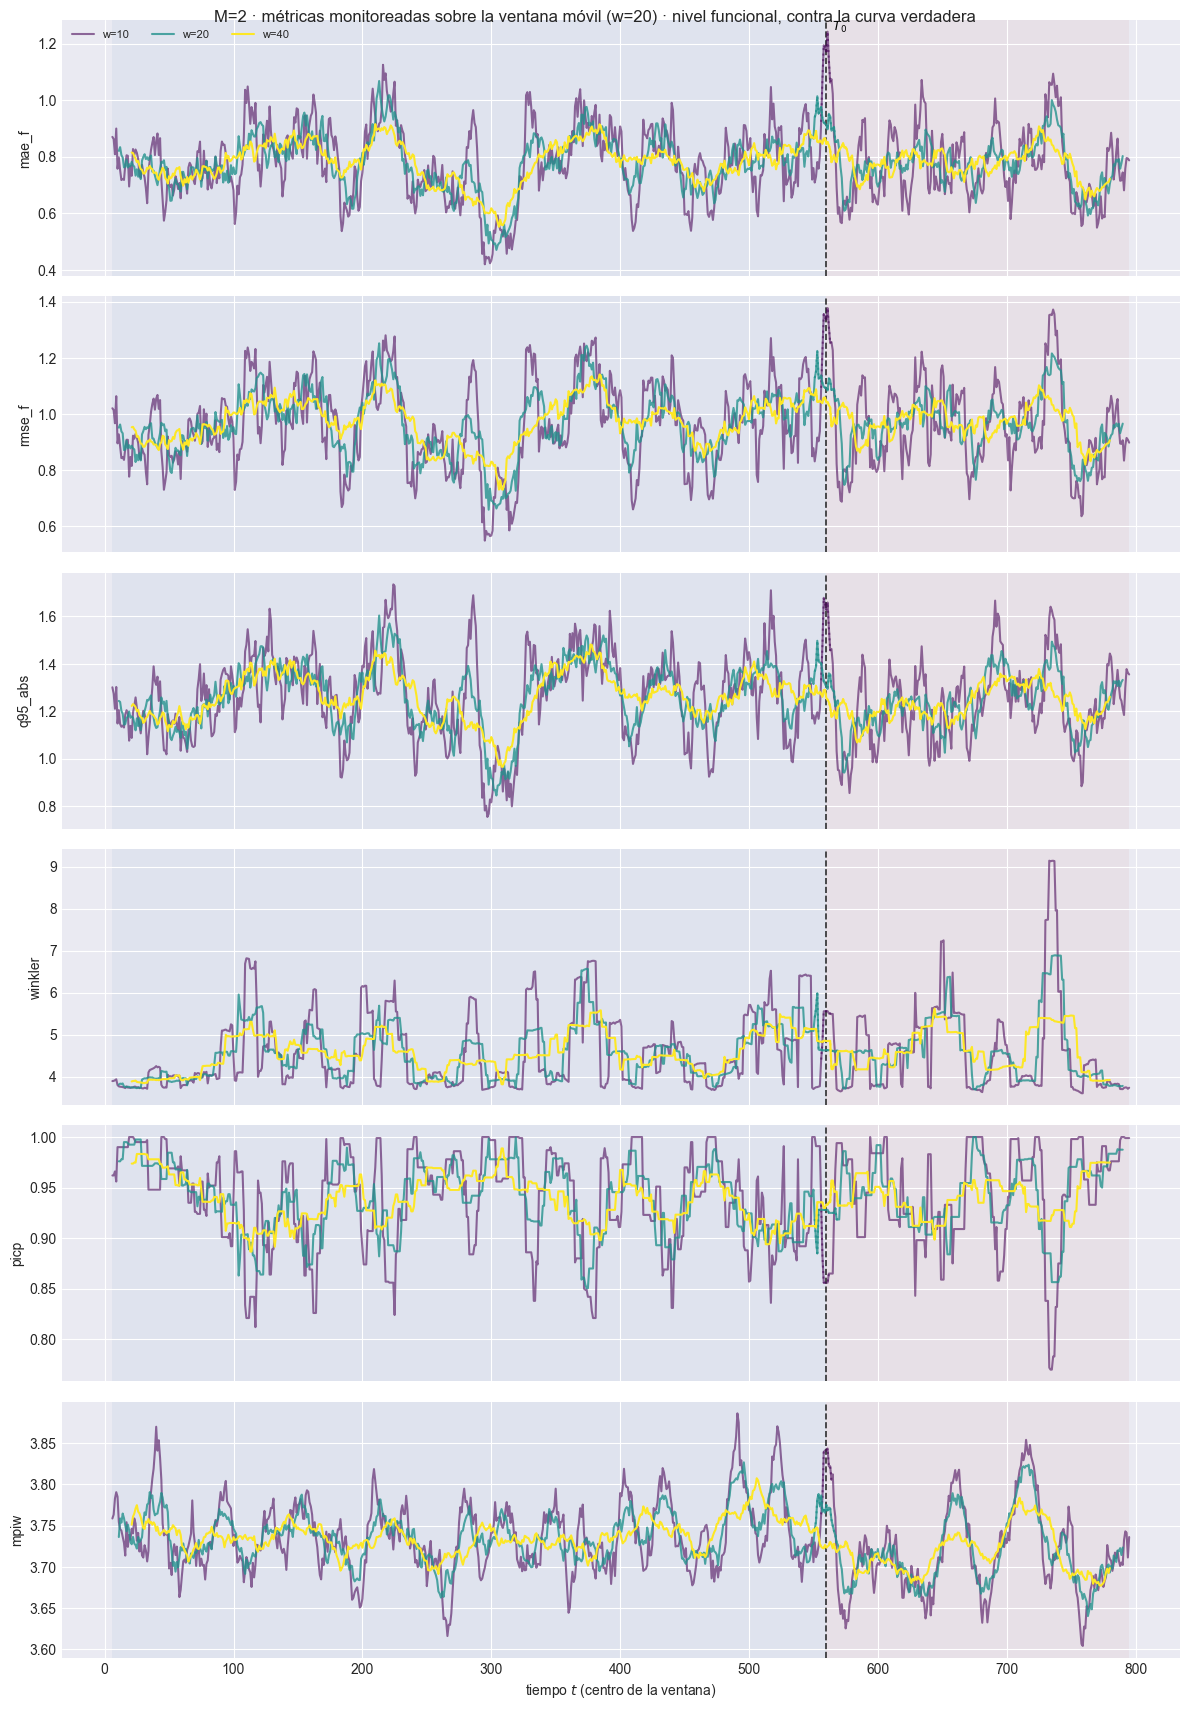

[M=2] cadena L^1 <= L^2 <= L^inf verificada en las 780 ventanas de w=20
[plot_ventana_movil] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.1s  mae_f: w=10 train=0.7828  w=10 test=0.7425  w=20 train=0.7864  w=20 test=0.7658  w=40 train=0.7894  w=40 test=0.776
  2/6 (33.3%) t=0.0s eta=0.1s  rmse_f: w=10 train=0.9657  w=10 test=0.9335  w=20 train=0.9751  w=20 test=0.9518  w=40 train=0.9758  w=40 test=0.9665
  3/6 (50.0%) t=0.0s eta=0.0s  q95_abs: w=10 train=1.288  w=10 test=1.228  w=20 train=1.273  w=20 test=1.227  w=40 train=1.268  w=40 test=1.231
  4/6 (66.7%) t=0.1s eta=0.0s  winkler: w=10 train=4.216  w=10 test=4.123  w=20 train=4.42  w=20 test=4.399  w=40 train=4.435  w=40 test=4.563
  5/6 (83.3%) t=0.1s eta=0.0s  picp: w=10 train=0.951  w=10 test=0.955  w=20 train=0.948  w=20 test=0.9535  w=40 train=0.9445  w=40 test=0.947
  6/6 (100.0%) t=0.1s eta=0.0s  mpiw: w=10 train=3.811  w=10 test=3.811  w=20 train=3.816  w=20 test=3.815  w=40 train=3.819  w=40 test=3.822
[plot_ventana_movil] l

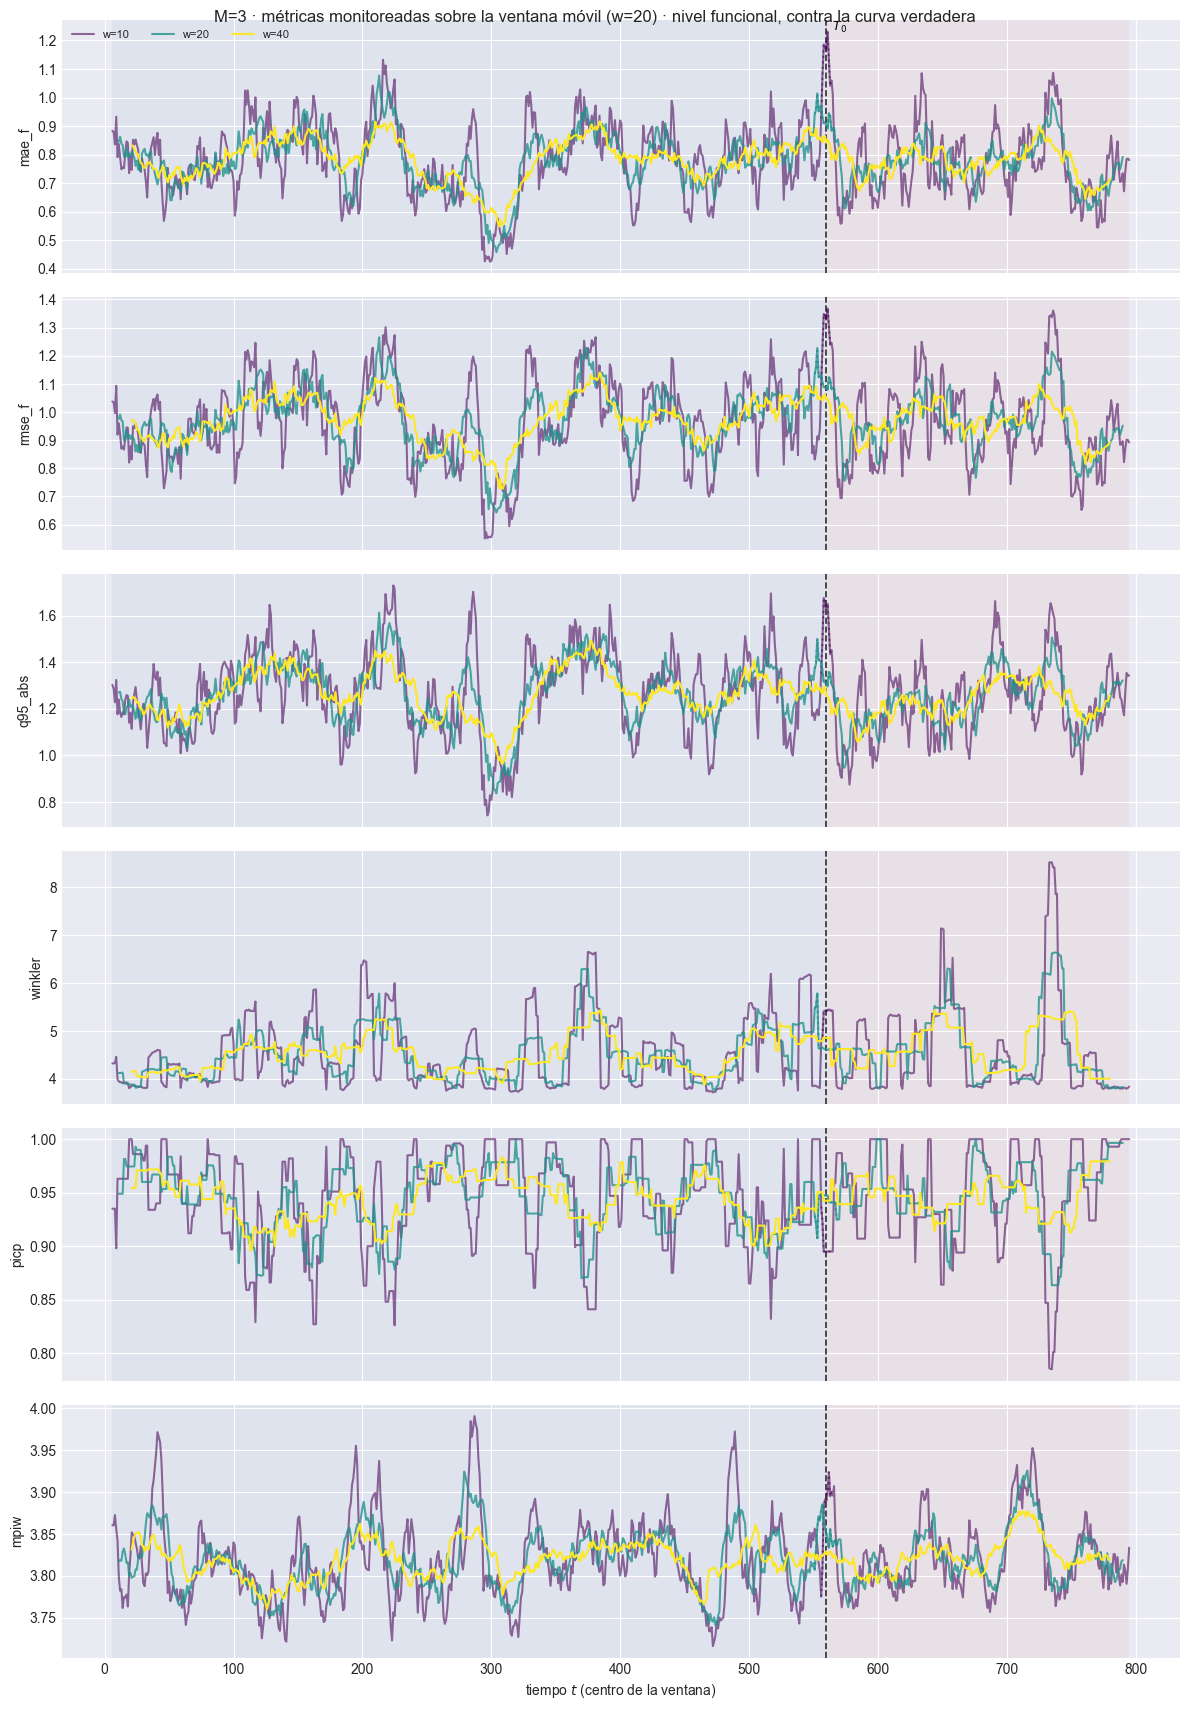

[M=3] cadena L^1 <= L^2 <= L^inf verificada en las 780 ventanas de w=20


In [57]:
# §7.1 — LAS METRICAS MONITOREADAS SOBRE LA VENTANA MOVIL
#
# Un panel por metrica, en el orden de [METRICAS] y sin jerarquia: aqui se ven
# las seis que tienen lectura por ventana. Reemplaza a las dos figuras que
# partian el Bloque A del B, porque partirlas obligaba a leer dos ejes
# distintos para responder una sola pregunta.
#
# Todo es FUNCIONAL y contra la curva VERDADERA. Las ventanas que cruzan T0 van
# punteadas: su cifra mezcla dentro y fuera de muestra.
for M in M_OK:
    e = EST[M]
    tfun = e["tablas_fun"][W_REF]

    faltan = [c for _, c, _ in METRICAS_MONITOR if c not in tfun.columns]
    assert not faltan, (
        f"[M={M}] la ventana movil no trae {faltan}. Si falta una del Bloque B, "
        "es que se llamo a ventana_movil_funcional sin li/ls.")

    plot_ventana_movil(
        tfun, T0, [c for _, c, _ in METRICAS_MONITOR],
        tablas_por_w=e["tablas_fun"],
        title=f"M={M} · métricas monitoreadas sobre la ventana móvil "
              f"(w={W_REF}) · nivel funcional, contra la curva verdadera",
        save_path=str(e["paths"]["out_report"] / "65_ventana_metricas.png"),
        verbose=True)
    plt.show()

    tfun.to_csv(
        e["paths"]["out_report"] / f"65_ventana_bloques_AB_w{W_REF}.csv",
        index=False)

    # La cadena L^1 <= L^2 <= L^inf tiene que verse tambien ventana a ventana.
    # Si fallara aqui y no en el agregado, el problema estaria en una ventana
    # concreta y no en la cuadratura.
    assert (tfun["mae_f"] <= tfun["rmse_f"] + 1e-9).all(), (
        f"[M={M}] mae_f > rmse_f en alguna ventana: revisar la cuadratura.")
    assert (tfun["rmse_f"] <= tfun["linf_max"] + 1e-9).all()
    print(f"[M={M}] cadena L^1 <= L^2 <= L^inf verificada en las "
          f"{len(tfun)} ventanas de w={W_REF}")


In [58]:
# §7.2 — TABLA RESUMEN de las metricas monitoreadas, y la serie I_t
#
# Una fila por metrica y una columna por bloque, en el orden de [METRICAS]. Es
# la tabla que se mira para monitorear: no ordena modelos ni marca ninguna como
# primaria. `razon` es test/train, de modo que 1.00 es "no se degrada fuera de
# muestra"; para PICP la lectura no es esa --lo que importa es la distancia al
# nivel nominal-- y por eso se reporta ademas `nominal` y el ACE.
#
# Las cifras salen de las tablas AGREGADAS (A_df, B_df), no de promediar la
# ventana movil: con ventanas solapadas cada origen entra w veces y el promedio
# ponderaria de mas el centro del recorrido.
monitor_M = []
for M in M_OK:
    e = EST[M]
    filas = []
    for etiqueta, _col_win, col_agg in METRICAS_MONITOR:
        fuente = e["A_df"] if col_agg in e["A_df"].columns else None
        if fuente is not None:
            v_tr = float(e["A_df"].loc["train", col_agg])
            v_te = float(e["A_df"].loc["test",  col_agg])
        else:
            v_tr = float(e["B_df"].loc[("curva", "train"), col_agg])
            v_te = float(e["B_df"].loc[("curva", "test"),  col_agg])
        filas.append({"metrica": etiqueta, "columna": col_agg,
                      "train": v_tr, "test": v_te,
                      "razon_test_train": v_te / v_tr if v_tr else float("nan")})
    mon = pd.DataFrame(filas).set_index("metrica")
    mon.to_csv(e["paths"]["out_report"] / "66_metricas_monitor.csv")
    e["monitor_df"] = mon

    display(mon.style
            .format({"train": "{:.6f}", "test": "{:.6f}",
                     "razon_test_train": "{:.4f}"})
            .set_caption(f"M={M} · métricas monitoreadas · nivel funcional, "
                         f"contra la curva verdadera · nivel nominal {NIVEL:.2f}"))

    b = e["B_df"].loc[("curva", "test")]
    print(f"[M={M}] PICP test = {b['picp']:.4f} contra nominal {NIVEL:.2f} "
          f"(ACE = {b['ace']:+.4f}); la cobertura es PUNTUAL, no simultánea.")

    # (5) El indicador I_t: una serie por ORIGEN, promediada sobre tau. Es de
    # lo que la PICP es el promedio, y se persiste porque el promedio esconde
    # DONDE falla la banda -- que es justamente lo que la ventana movil dibuja.
    I_t = indicador_cobertura(X_true_ev, e["li_f"], e["ls_f"]).mean(axis=1)
    ind = pd.DataFrame({
        "t": np.arange(len(I_t)) + N_LAGS + 1,
        "bloque": np.where(es_train, "train", "test"),
        "I_t": I_t,
    })
    ind.to_csv(e["paths"]["out_report"] / "67_indicador_cobertura.csv",
               index=False)
    print(f"        I_t: {len(ind)} orígenes -> 67_indicador_cobertura.csv "
          f"(media train {I_t[es_train].mean():.4f}, "
          f"test {I_t[~es_train].mean():.4f})")

    m_ = mon.reset_index()
    m_["M"] = M
    monitor_M.append(m_)

# El mismo cuadro cruzando el barrido, para monitorear las siete contra M en
# una sola tabla en vez de abrir un CSV por punto.
monitor_barrido = pd.concat(monitor_M, ignore_index=True)
monitor_barrido.to_csv(PATH_BARRIDO / "96_metricas_monitor_por_M.csv", index=False)
display(monitor_barrido[monitor_barrido.metrica.notna()]
        .pivot(index="metrica", columns="M", values="test")
        .style.format("{:.6f}")
        .set_caption("Métricas monitoreadas en el TEST contra M · "
                     "nivel funcional (96_metricas_monitor_por_M.csv)"))


,columna,train,test,razon_test_train
metrica,,,,
1. MAE (L^1),mae_f,0.788972,0.779414,0.9879
2. RMSE (L^2),rmse_f,0.983678,0.975236,0.9914
3. Q0.95 |e| (L^inf),q95_abs_medio,1.275361,1.251150,0.9810
4. Winkler,winkler,5.069180,4.974269,0.9813
6. PICP,picp,0.889052,0.895958,1.0078
7. MPIW,mpiw,3.293146,3.300909,1.0024


[M=1] PICP test = 0.8960 contra nominal 0.95 (ACE = -0.0540); la cobertura es PUNTUAL, no simultánea.
        I_t: 799 orígenes -> 67_indicador_cobertura.csv (media train 0.8891, test 0.8960)


,columna,train,test,razon_test_train
metrica,,,,
1. MAE (L^1),mae_f,0.781190,0.779928,0.9984
2. RMSE (L^2),rmse_f,0.973901,0.973828,0.9999
3. Q0.95 |e| (L^inf),q95_abs_medio,1.264409,1.241204,0.9816
4. Winkler,winkler,4.530077,4.620852,1.0200
6. PICP,picp,0.939410,0.942042,1.0028
7. MPIW,mpiw,3.740290,3.720758,0.9948


[M=2] PICP test = 0.9420 contra nominal 0.95 (ACE = -0.0080); la cobertura es PUNTUAL, no simultánea.
        I_t: 799 orígenes -> 67_indicador_cobertura.csv (media train 0.9394, test 0.9420)


,columna,train,test,razon_test_train
metrica,,,,
1. MAE (L^1),mae_f,0.784150,0.774553,0.9878
2. RMSE (L^2),rmse_f,0.976514,0.969424,0.9927
3. Q0.95 |e| (L^inf),q95_abs_medio,1.269155,1.239723,0.9768
4. Winkler,winkler,4.475632,4.611857,1.0304
6. PICP,picp,0.944043,0.948625,1.0049
7. MPIW,mpiw,3.816775,3.824280,1.0020


[M=3] PICP test = 0.9486 contra nominal 0.95 (ACE = -0.0014); la cobertura es PUNTUAL, no simultánea.
        I_t: 799 orígenes -> 67_indicador_cobertura.csv (media train 0.9440, test 0.9486)


M,1,2,3
metrica,,,
1. MAE (L^1),0.779414,0.779928,0.774553
2. RMSE (L^2),0.975236,0.973828,0.969424
3. Q0.95 |e| (L^inf),1.251150,1.241204,1.239723
4. Winkler,4.974269,4.620852,4.611857
6. PICP,0.895958,0.942042,0.948625
7. MPIW,3.300909,3.720758,3.824280


In [59]:
# Lectura numérica del salto en T0, excluyendo las ventanas que lo cruzan.
for M in M_OK:
    e = EST[M]
    print(f"── M={M} ──")
    print(f"{'w':>4}  {'MISE train':>11}  {'MISE test':>11}  {'salto':>7}")
    print(f"{'-'*4}  {'-'*11}  {'-'*11}  {'-'*7}")
    saltos = {}
    for w in VENTANAS_W:
        t_ = e["tablas_fun"][w]
        limpio = t_[~t_["cruza_T0"]]
        a = limpio.loc[limpio.bloque == "train", "mise"].mean()
        b = limpio.loc[limpio.bloque == "test",  "mise"].mean()
        saltos[w] = float(b / a)
        print(f"{w:>4}  {a:>11.6f}  {b:>11.6f}  {b/a:>6.2f}x")
    e["saltos_T0"] = saltos

── M=1 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     0.965094     0.924124    0.96x
  20     0.966207     0.929190    0.96x
  40     0.967150     0.938382    0.97x
── M=2 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     0.946119     0.923751    0.98x
  20     0.947105     0.929035    0.98x
  40     0.948262     0.937883    0.99x
── M=3 ──
   w   MISE train    MISE test    salto
----  -----------  -----------  -------
  10     0.951199     0.915470    0.96x
  20     0.951757     0.920986    0.97x
  40     0.951850     0.931252    0.98x


## 8. Calibración

Bajo calibración perfecta el PIT es uniforme. La **forma** dice qué falla: una
U indica bandas demasiado angostas, una campana demasiado anchas, y una
pendiente un sesgo del centro. Contrastar train contra test separa el desajuste
del modelo de la pérdida de calibración fuera de muestra.

[plot_calibracion_pit] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1  train: media=0.501 desv_max=0.306 n=559  |  test: media=0.490 desv_max=0.208 n=240
[plot_calibracion_pit] listo: 1 pasos en 0.1s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m01\58_pit.png


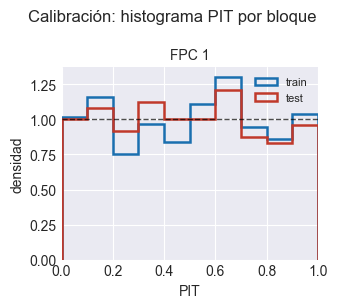

── M=1 ──
  FPC 1:  train KS=0.029 (aproximadamente uniforme)   test KS=0.035 (aproximadamente uniforme)
[plot_calibracion_pit] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  FPC 1  train: media=0.501 desv_max=0.288 n=559  |  test: media=0.490 desv_max=0.208 n=240
  2/2 (100.0%) t=0.0s eta=0.0s  FPC 2  train: media=0.495 desv_max=0.199 n=559  |  test: media=0.504 desv_max=0.250 n=240
[plot_calibracion_pit] listo: 2 pasos en 0.1s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m02\58_pit.png


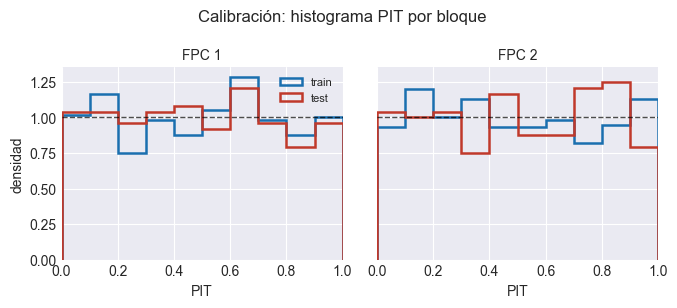

── M=2 ──
  FPC 1:  train KS=0.027 (aproximadamente uniforme)   test KS=0.033 (aproximadamente uniforme)
  FPC 2:  train KS=0.030 (aproximadamente uniforme)   test KS=0.032 (aproximadamente uniforme)
[plot_calibracion_pit] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1  train: media=0.501 desv_max=0.270 n=559  |  test: media=0.490 desv_max=0.250 n=240
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2  train: media=0.497 desv_max=0.177 n=559  |  test: media=0.505 desv_max=0.250 n=240
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3  train: media=0.500 desv_max=0.199 n=559  |  test: media=0.514 desv_max=0.208 n=240
[plot_calibracion_pit] listo: 3 pasos en 0.2s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m03\58_pit.png


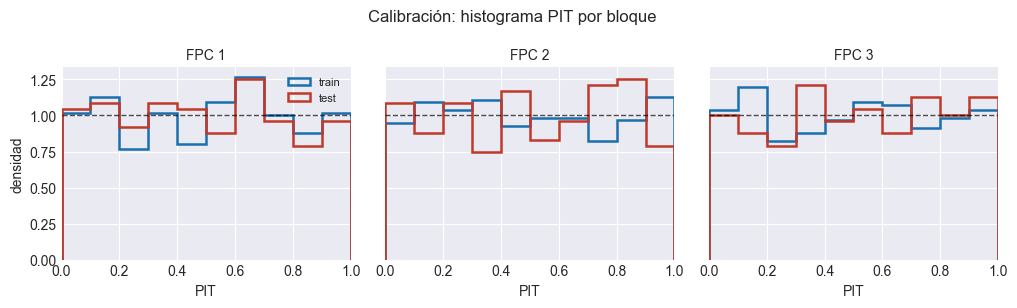

── M=3 ──
  FPC 1:  train KS=0.029 (aproximadamente uniforme)   test KS=0.037 (aproximadamente uniforme)
  FPC 2:  train KS=0.024 (aproximadamente uniforme)   test KS=0.036 (aproximadamente uniforme)
  FPC 3:  train KS=0.032 (aproximadamente uniforme)   test KS=0.046 (aproximadamente uniforme)


In [60]:
for M in M_OK:
    e = EST[M]
    ci = e["component_idx"]
    pit_tr = {f"FPC {ci[k]+1}": pit_muestral(e["Y_obs"][es_train, k],
                                             e["SC_draws"][:, es_train, k])
              for k in range(e["n_components"])}
    pit_te = {f"FPC {ci[k]+1}": pit_muestral(e["Y_obs"][~es_train, k],
                                             e["SC_draws"][:, ~es_train, k])
              for k in range(e["n_components"])}
    e["pit_tr"], e["pit_te"] = pit_tr, pit_te

    plot_calibracion_pit(pit_tr, pit_te,
                         save_path=str(e["paths"]["out_report"] / "58_pit.png"),
                         verbose=True)
    plt.show()

    print(f"── M={M} ──")
    for nombre in pit_tr:
        d_tr, d_te = diagnostico_pit(pit_tr[nombre]), diagnostico_pit(pit_te[nombre])
        print(f"  {nombre}:  train KS={d_tr['ks']:.3f} ({d_tr['forma']})   "
              f"test KS={d_te['ks']:.3f} ({d_te['forma']})")
    e["pit_ks_test_max"] = float(max(diagnostico_pit(v)["ks"]
                                     for v in pit_te.values()))

## 9. Comparación con las líneas base

In [61]:
for M in M_OK:
    e = EST[M]
    bl = e["paths"]["out_report"] / "30_baselines_test.csv"
    rmse_psbp = e["met_df"].loc["test", "RMSE"].mean()
    print(f"── M={M} ──  RMSE promedio en scores, PSBP-FD (test): {rmse_psbp:.4f}")

    if bl.exists():
        baselines_df = pd.read_csv(bl, index_col=0)
        display(baselines_df.style.format("{:.4f}", na_rep="-")
                .set_caption(f"M={M} - líneas base sobre el bloque de prueba (h=1)"))
        if "RMSE_scores_prom" in baselines_df.columns:
            for modelo, fila in baselines_df.iterrows():
                marca = ("OK PSBP mejor" if rmse_psbp < fila["RMSE_scores_prom"]
                         else "X baseline mejor")
                print(f"    vs {modelo:24s} RMSE={fila['RMSE_scores_prom']:.4f}"
                      f"  -> {marca}")
    else:
        print(f"    ! falta {bl.name} - ejecuta 30_01 §6 para este M.")

── M=1 ──  RMSE promedio en scores, PSBP-FD (test): 0.7731


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,240.0000,0.9631,0.9631,-0.0109,1.3587,1.1656
persistencia_lag1,240.0000,0.8646,0.8646,0.1852,1.1369,1.0663


    vs media_incondicional      RMSE=0.9631  -> OK PSBP mejor
    vs persistencia_lag1        RMSE=0.8646  -> OK PSBP mejor
── M=2 ──  RMSE promedio en scores, PSBP-FD (test): 0.8479


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,240.0000,0.9631,0.9486,0.9558,-0.0055,1.3587,1.1656
persistencia_lag1,240.0000,0.8646,1.1638,1.0142,-0.1600,1.2363,1.1119


    vs media_incondicional      RMSE=0.9558  -> OK PSBP mejor
    vs persistencia_lag1        RMSE=1.0142  -> OK PSBP mejor
── M=3 ──  RMSE promedio en scores, PSBP-FD (test): 0.8942


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,240.0000,0.9631,0.9486,0.9912,0.9676,-0.0046,1.3587,1.1656
persistencia_lag1,240.0000,0.8646,1.1638,1.2668,1.0984,-0.3194,1.2553,1.1204


    vs media_incondicional      RMSE=0.9676  -> OK PSBP mejor
    vs persistencia_lag1        RMSE=1.0984  -> OK PSBP mejor


## 10. Resumen por punto del barrido

In [62]:
for M in M_OK:
    e = EST[M]
    resumen = {
        "experiment_id": e["eid"],
        "M_fpca": e["M_fpca"], "K_base": e["K"],
        "var_explicada": round(e["var_explicada"], 6),
        "objetivo_evaluacion": OBJETIVO,
        "modo_residuo": MODO_RESIDUO,
        "nivel": NIVEL,
        "S_scores": e["S_total"], "S_funcional": e["S_funcional"],
        "rmse_scores_train": float(e["met_df"].loc["train", "RMSE"].mean()),
        "rmse_scores_test":  float(e["met_df"].loc["test", "RMSE"].mean()),
        "mise_train": float(e["fun_df"].loc["train", "MISE"]),
        "mise_test":  float(e["fun_df"].loc["test", "MISE"]),
        "mise_truncamiento_test": float(e["fun_df"].loc["test", "MISE_truncamiento"]),
        "cobertura_puntual_test": float(
            e["fun_df"].loc["test", f"Cob{int(NIVEL*100)}_puntual"]),
    }
    pd.Series(resumen).to_csv(e["paths"]["out_report"] / "59_resumen.csv",
                              header=False)
    e["resumen"] = resumen
    print(f"── M={M} ──")
    for k, v in resumen.items():
        print(f"  {k:26s}: {v}")
    print(f"  figuras y tablas en {e['paths']['out_report']}")

── M=1 ──
  experiment_id             : escenario_1_r01_m01
  M_fpca                    : 1
  K_base                    : 4
  var_explicada             : 0.829797
  objetivo_evaluacion       : curva_verdadera
  modo_residuo              : ninguno
  nivel                     : 0.95
  S_scores                  : 40000
  S_funcional               : 500
  rmse_scores_train         : 0.7651321247375373
  rmse_scores_test          : 0.773138756001877
  mise_train                : 0.9676232081207489
  mise_test                 : 0.9510849495898542
  mise_truncamiento_test    : 0.22856145979686066
  cobertura_puntual_test    : 0.8959583333333333
  figuras y tablas en C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_m01
── M=2 ──
  experiment_id             : escenario_1_r01_m02
  M_fpca                    : 2
  K_base                    : 4
  var_explicada             : 0.976881
  objetivo_evaluacion       : curva_verdadera
  modo_residuo        

## 11. El barrido: comparación entre los $M$

Aquí es donde el notebook responde `§03_06`. Todo lo anterior describe cada
punto; esto los pone en el mismo eje.

**La lectura correcta no es "¿baja el MISE al subir $M$?".** El MISE de
truncamiento —el error de proyectar la curva verdadera sobre las $M$
autofunciones, sin modelo alguno— baja siempre con $M$: es aritmética. La
pregunta es si el error del **modelo** baja tanto como su propio piso. Por eso
la cifra central es la **razón `MISE / MISE_truncamiento`**: cuánto agrega el
modelo por encima de lo que la representación ya le regala.

| Si al subir $M$… | Lectura |
|---|---|
| MISE baja y la razón se mantiene | $M$ aporta información y el modelo la aprovecha |
| MISE baja pero la razón **sube** | la ganancia es toda de la representación; el modelo empeora relativo a su piso |
| MISE **sube** | las componentes nuevas son ruido neto — la hipótesis de la Etapa D |

Se acompaña de la calibración (cobertura y ancho de banda) porque un modelo
puede conservar el MISE y perder la cobertura, que es el modo de fallo que la
métrica puntual no ve.

In [63]:
filas = []
for M in M_OK:
    e = EST[M]
    for bloque in ("train", "test"):
        f = e["fun_df"].loc[bloque]
        s = e["met_df"].loc[bloque]
        filas.append({
            "M": M, "bloque": bloque,
            "p_covariables": len(e["cov_names"]),
            "var_explicada": e["var_explicada"],
            "RMSE_scores": float(s["RMSE"].mean()),
            "R2_scores":   float(s["R2"].mean()),
            "CRPS":        float(s["CRPS"].mean()),
            "Cob_scores":  float(s[f"Cob{int(NIVEL*100)}"].mean()),
            "Ancho_scores": float(s["Ancho"].mean()),
            "PIT_ks_max":  float(s["PIT_ks"].max()),
            "MISE":        float(f["MISE"]),
            "MISE_truncamiento": float(f["MISE_truncamiento"]),
            "razon_MISE_piso":   float(f["MISE"] / f["MISE_truncamiento"]),
            "RMSE_f":      float(f["RMSE_f"]),
            "energy":      float(f["energy"]),
            "Cob_puntual": float(f[f"Cob{int(NIVEL*100)}_puntual"]),
            "ancho_funcional": float(f["ancho_medio"]),
        })

barrido_df = pd.DataFrame(filas).set_index(["bloque", "M"]).sort_index()
barrido_df.to_csv(PATH_BARRIDO / "85_metricas_por_M.csv")

_fmt = {"var_explicada": "{:.4%}", "RMSE_scores": "{:.4f}", "R2_scores": "{:.4f}",
        "CRPS": "{:.4f}", "Cob_scores": "{:.4f}", "Ancho_scores": "{:.4f}",
        "PIT_ks_max": "{:.4f}", "MISE": "{:.6f}", "MISE_truncamiento": "{:.6f}",
        "razon_MISE_piso": "{:.3f}", "RMSE_f": "{:.6f}", "energy": "{:.4f}",
        "Cob_puntual": "{:.4f}", "ancho_funcional": "{:.4f}"}
display(barrido_df.style.format(_fmt)
        .background_gradient(subset=["MISE"], cmap="RdYlGn_r")
        .background_gradient(subset=["razon_MISE_piso"], cmap="RdYlGn_r")
        .background_gradient(subset=["Cob_puntual"], cmap="RdYlGn",
                             vmin=0.80, vmax=1.0)
        .set_caption("Métricas del PSBPM-FD a lo largo del barrido en M · "
                     "MISE contra la curva VERDADERA"))

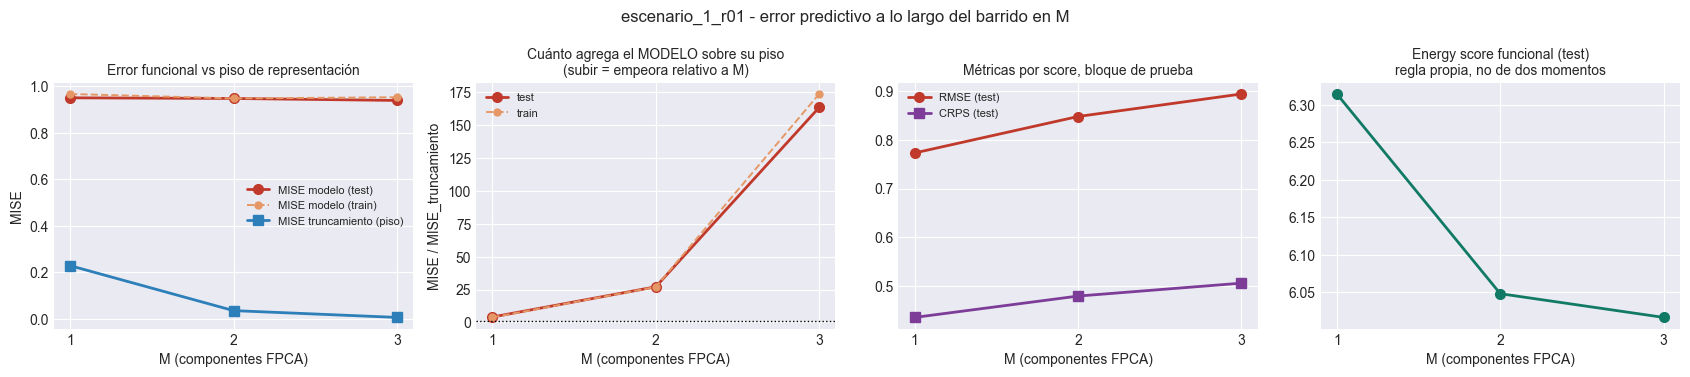

In [64]:
# Figura 1 del barrido: error. Panel izquierdo con MISE del modelo y su piso de
# truncamiento en el MISMO eje —es la comparación que decide—, y el resto con
# las métricas de score.
te = barrido_df.loc["test"]
tr = barrido_df.loc["train"]
_Ms = list(te.index)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

ax = axes[0]
ax.plot(_Ms, te["MISE"], "o-", lw=2, ms=7, color="#c0392b", label="MISE modelo (test)")
ax.plot(_Ms, tr["MISE"], "o--", lw=1.4, ms=5, color="#e59866", label="MISE modelo (train)")
ax.plot(_Ms, te["MISE_truncamiento"], "s-", lw=2, ms=7, color="#2c7fb8",
        label="MISE truncamiento (piso)")
ax.set_ylabel("MISE"); ax.set_title("Error funcional vs piso de representación", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(_Ms, te["razon_MISE_piso"], "o-", lw=2, ms=7, color="#c0392b", label="test")
ax.plot(_Ms, tr["razon_MISE_piso"], "o--", lw=1.4, ms=5, color="#e59866", label="train")
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_ylabel("MISE / MISE_truncamiento")
ax.set_title("Cuánto agrega el MODELO sobre su piso\n(subir = empeora relativo a M)",
             fontsize=10)
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(_Ms, te["RMSE_scores"], "o-", lw=2, ms=7, color="#c0392b", label="RMSE (test)")
ax.plot(_Ms, te["CRPS"], "s-", lw=2, ms=7, color="#7d3c98", label="CRPS (test)")
ax.set_title("Métricas por score, bloque de prueba", fontsize=10)
ax.legend(fontsize=8)

ax = axes[3]
ax.plot(_Ms, te["energy"], "o-", lw=2, ms=7, color="#117a65")
ax.set_title("Energy score funcional (test)\nregla propia, no de dos momentos",
             fontsize=10)

for ax in axes:
    ax.set_xticks(_Ms); ax.set_xlabel("M (componentes FPCA)")
fig.suptitle(f"{EXPERIMENT_BASE} - error predictivo a lo largo del barrido en M",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "86_error_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

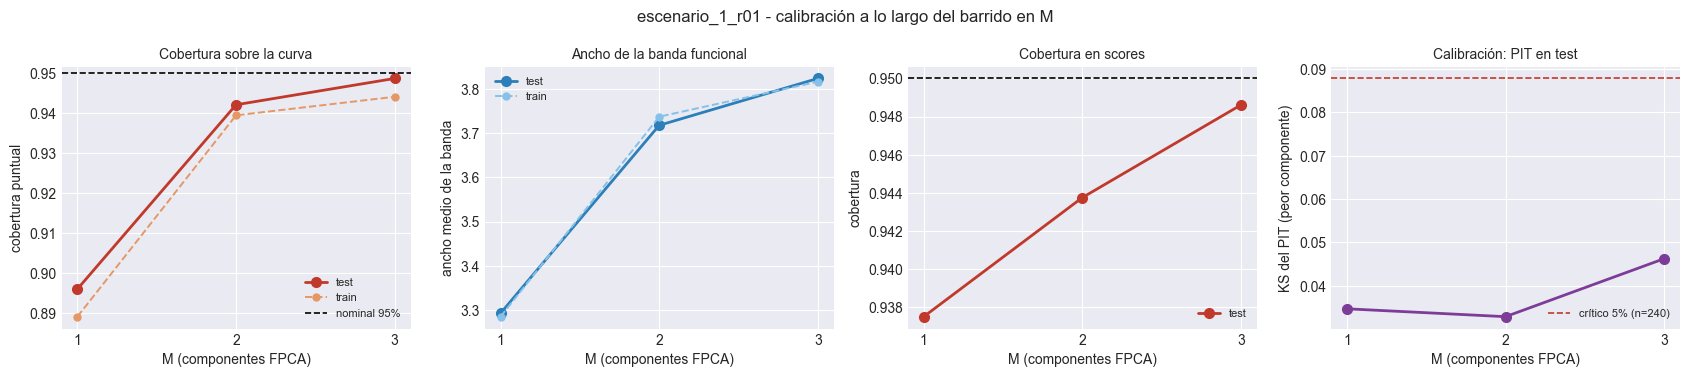

In [65]:
# Figura 2 del barrido: calibración. Un modelo puede conservar el MISE y perder
# la cobertura; ésa es la parte que la métrica puntual no ve.
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

ax = axes[0]
ax.plot(_Ms, te["Cob_puntual"], "o-", lw=2, ms=7, color="#c0392b", label="test")
ax.plot(_Ms, tr["Cob_puntual"], "o--", lw=1.4, ms=5, color="#e59866", label="train")
ax.axhline(NIVEL, color="k", ls="--", lw=1.2, label=f"nominal {NIVEL:.0%}")
ax.set_ylabel("cobertura puntual")
ax.set_title("Cobertura sobre la curva", fontsize=10); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(_Ms, te["ancho_funcional"], "o-", lw=2, ms=7, color="#2c7fb8", label="test")
ax.plot(_Ms, tr["ancho_funcional"], "o--", lw=1.4, ms=5, color="#85c1e9", label="train")
ax.set_ylabel("ancho medio de la banda")
ax.set_title("Ancho de la banda funcional", fontsize=10); ax.legend(fontsize=8)

ax = axes[2]
ax.plot(_Ms, te["Cob_scores"], "o-", lw=2, ms=7, color="#c0392b", label="test")
ax.axhline(NIVEL, color="k", ls="--", lw=1.2)
ax.set_ylabel("cobertura"); ax.set_title("Cobertura en scores", fontsize=10)
ax.legend(fontsize=8)

ax = axes[3]
ax.plot(_Ms, te["PIT_ks_max"], "o-", lw=2, ms=7, color="#7d3c98")
# Crítico KS al 5% con n = nº de orígenes de prueba. Es orientativo: los draws
# no son independientes entre orígenes.
_ncrit = int((~es_train).sum())
ax.axhline(1.36 / np.sqrt(_ncrit), color="#c0392b", ls="--", lw=1.2,
           label=f"crítico 5% (n={_ncrit})")
ax.set_ylabel("KS del PIT (peor componente)")
ax.set_title("Calibración: PIT en test", fontsize=10); ax.legend(fontsize=8)

for ax in axes:
    ax.set_xticks(_Ms); ax.set_xlabel("M (componentes FPCA)")
fig.suptitle(f"{EXPERIMENT_BASE} - calibración a lo largo del barrido en M",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "87_calibracion_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

[plot_ventana_movil] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  mise: w=20 train=0.9508  w=20 test=0.9189
  2/2 (100.0%) t=0.0s eta=0.0s  cobertura_puntual: w=20 train=0.929  w=20 test=0.932
[plot_ventana_movil] listo: 2 pasos en 0.2s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_barrido_M\88_ventana_funcional_por_M.png


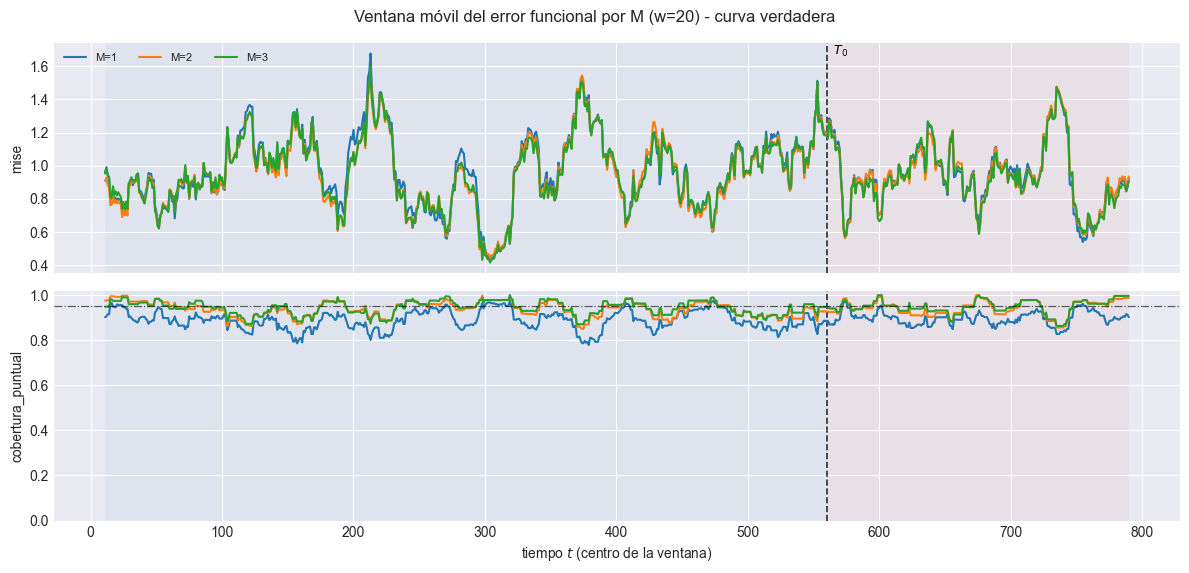

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  rmse: w=20 train=0.7602  w=20 test=0.7604
  2/3 (66.7%) t=0.0s eta=0.0s  crps: w=20 train=0.4323  w=20 test=0.4303
  3/3 (100.0%) t=0.0s eta=0.0s  cobertura: w=20 train=0.95  w=20 test=0.95
[plot_ventana_movil] listo: 3 pasos en 0.3s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_barrido_M\88_ventana_scores_fpc1_por_M.png


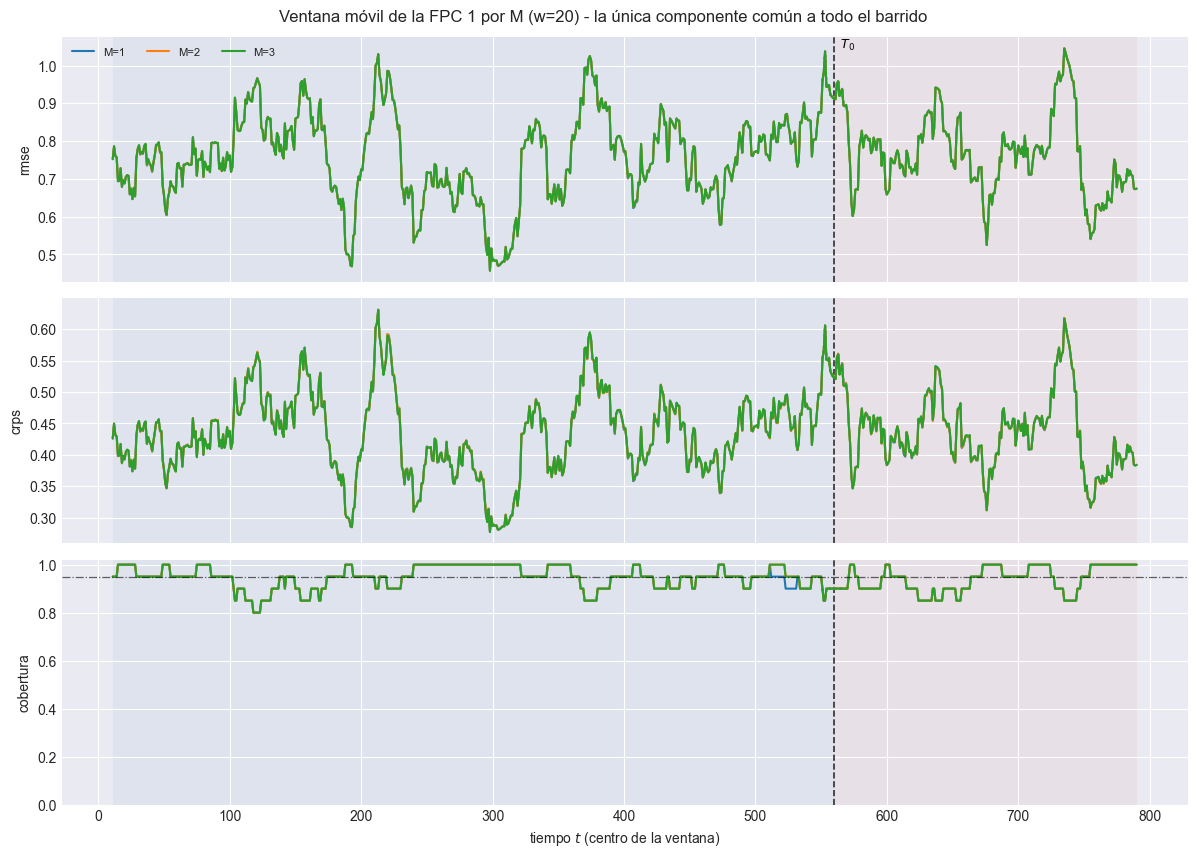

In [66]:
# Figura 3 del barrido: la ventana móvil de todos los M en el mismo eje. Es la
# misma serie de orígenes en los tres, así que las curvas son comparables punto
# a punto; lo que se busca es si la separación entre M aparece en todo el
# recorrido o sólo después de T0.
partes = []
for M in M_OK:
    t_ = EST[M]["tablas_fun"][W_REF].copy()
    t_["M"] = f"M={M}"
    partes.append(t_)
ventana_M = pd.concat(partes, ignore_index=True)
ventana_M.attrs["w"] = W_REF
ventana_M.to_csv(PATH_BARRIDO / f"88_ventana_funcional_por_M_w{W_REF}.csv",
                 index=False)

plot_ventana_movil(
    ventana_M, T0, ["mise", "cobertura_puntual"], columna_grupo="M",
    title=f"Ventana móvil del error funcional por M (w={W_REF}) - curva verdadera",
    save_path=str(PATH_BARRIDO / "88_ventana_funcional_por_M.png"),
    verbose=True)
plt.show()

# Y la misma comparación en scores, restringida a la PRIMERA componente FPCA,
# que es la única presente en todos los puntos del barrido. Comparar el
# promedio sobre componentes mezclaría distinto número de sumandos por M.
partes_s = []
for M in M_OK:
    t_ = EST[M]["tablas_score"][W_REF]
    prim = f"FPC {EST[M]['component_idx'][0] + 1}"
    t_ = t_[t_["componente"] == prim].copy()
    t_["M"] = f"M={M}"
    partes_s.append(t_)
ventana_s_M = pd.concat(partes_s, ignore_index=True)
ventana_s_M.attrs["w"] = W_REF
ventana_s_M.to_csv(PATH_BARRIDO / f"88_ventana_scores_fpc1_por_M_w{W_REF}.csv",
                   index=False)

plot_ventana_movil(
    ventana_s_M, T0, ["rmse", "crps", "cobertura"], columna_grupo="M",
    title=f"Ventana móvil de la FPC 1 por M (w={W_REF}) - la única componente "
          "común a todo el barrido",
    save_path=str(PATH_BARRIDO / "88_ventana_scores_fpc1_por_M.png"),
    verbose=True)
plt.show()

In [67]:
# == Veredicto del barrido ===================================================
resumen_barrido = te[["p_covariables", "var_explicada", "MISE",
                      "MISE_truncamiento", "razon_MISE_piso", "RMSE_scores",
                      "CRPS", "energy", "Cob_puntual", "PIT_ks_max"]].copy()
resumen_barrido["salto_T0_w%d" % W_REF] = [EST[M]["saltos_T0"][W_REF] for M in _Ms]
resumen_barrido["degradacion_rmse"] = [EST[M]["degradacion_rmse"] for M in _Ms]
resumen_barrido.to_csv(PATH_BARRIDO / "89_resumen_por_M.csv")

display(resumen_barrido.style
        .format({"var_explicada": "{:.4%}", "MISE": "{:.6f}",
                 "MISE_truncamiento": "{:.6f}", "razon_MISE_piso": "{:.3f}",
                 "RMSE_scores": "{:.4f}", "CRPS": "{:.4f}", "energy": "{:.4f}",
                 "Cob_puntual": "{:.4f}", "PIT_ks_max": "{:.4f}",
                 f"salto_T0_w{W_REF}": "{:.2f}x", "degradacion_rmse": "{:.3f}"})
        .background_gradient(subset=["MISE", "razon_MISE_piso"], cmap="RdYlGn_r")
        .set_caption("Resumen del barrido · bloque de PRUEBA"))

print("=" * 70)
print(f"  BARRIDO {EXPERIMENT_BASE}   ·   M evaluados: {list(M_OK)}")
print("=" * 70)
_mejor = te["MISE"].idxmin()
print(f"  MISE de test mínimo en M = {_mejor}  ({te.loc[_mejor, 'MISE']:.6f})")
print(f"  razón MISE/piso mínima en M = {te['razon_MISE_piso'].idxmin()}")
print("-" * 70)

for M in _Ms:
    f = te.loc[M]
    print(f"  M={M}  MISE={f['MISE']:.6f}  piso={f['MISE_truncamiento']:.6f}  "
          f"razón={f['razon_MISE_piso']:.3f}  cob={f['Cob_puntual']:.3f}")

# Las dos lecturas que separan "M aporta" de "M mete ruido".
if len(_Ms) >= 2:
    d_mise  = np.diff(te["MISE"].to_numpy())
    d_razon = np.diff(te["razon_MISE_piso"].to_numpy())
    print("-" * 70)
    print("  cambio de M a M+1 (test):")
    for i, M in enumerate(_Ms[:-1]):
        print(f"    {M} -> {_Ms[i+1]}:  dMISE={d_mise[i]:+.6f}   "
              f"drazón={d_razon[i]:+.4f}")
    if np.all(d_mise > 0):
        print("\n  El MISE SUBE en todo el barrido: las componentes agregadas son")
        print("  ruido neto. Es la hipótesis de la Etapa D en su forma fuerte.")
    elif np.all(d_razon > 0):
        print("\n  El MISE baja pero la razón contra el piso SUBE: la ganancia es")
        print("  toda de la representación y el modelo empeora relativo a lo que")
        print("  la representación le regala. Hipótesis de la Etapa D en su forma")
        print("  débil: M no rompe el modelo, pero tampoco lo ayuda.")
    else:
        print("\n  El modelo aprovecha las componentes agregadas al menos en parte:")
        print("  la razón contra el piso no crece de forma monótona.")

print("=" * 70)
print(f"Tablas y figuras del barrido en {PATH_BARRIDO}  (archivos 85-89)")
print("Continuar con 30_05_comparacion, declarando el mismo M_FPCA_LIST.")

,p_covariables,var_explicada,MISE,MISE_truncamiento,razon_MISE_piso,RMSE_scores,CRPS,energy,Cob_puntual,PIT_ks_max,salto_T0_w20,degradacion_rmse
M,,,,,,,,,,,,
1,1,82.9797%,0.951085,0.228561,4.161,0.7731,0.4355,6.3144,0.8960,0.0347,0.96x,1.010
2,2,97.6881%,0.948342,0.034991,27.103,0.8479,0.4793,6.0484,0.9420,0.0329,0.98x,0.987
3,3,99.7883%,0.939782,0.005754,163.336,0.8942,0.5059,6.0168,0.9486,0.0462,0.97x,0.987


  BARRIDO escenario_1_r01   ·   M evaluados: [1, 2, 3]
  MISE de test mínimo en M = 3  (0.939782)
  razón MISE/piso mínima en M = 1
----------------------------------------------------------------------
  M=1  MISE=0.951085  piso=0.228561  razón=4.161  cob=0.896
  M=2  MISE=0.948342  piso=0.034991  razón=27.103  cob=0.942
  M=3  MISE=0.939782  piso=0.005754  razón=163.336  cob=0.949
----------------------------------------------------------------------
  cambio de M a M+1 (test):
    1 -> 2:  dMISE=-0.002743   drazón=+22.9416
    2 -> 3:  dMISE=-0.008560   drazón=+136.2328

  El MISE baja pero la razón contra el piso SUBE: la ganancia es
  toda de la representación y el modelo empeora relativo a lo que
  la representación le regala. Hipótesis de la Etapa D en su forma
  débil: M no rompe el modelo, pero tampoco lo ayuda.
Tablas y figuras del barrido en C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_1_r01_barrido_M  (archivos 85-89)
Continuar 

### 11.1 Bloque A y Bloque B a lo largo del barrido

Las mismas cifras cruzadas entre puntos. La lectura es la de §11: lo que
importa no es que el error baje con $M$ —el piso de truncamiento baja siempre—
sino si baja **tanto como su propio piso**, y si la calibración aguanta.

La columna primaria va marcada. Las diagnósticas están para explicar la
primaria cuando se mueve, no para ordenar los puntos por su cuenta.

In [68]:
filas = []
for M in M_OK:
    e = EST[M]
    for bloque in ("train", "test"):
        a = e["A_df"].loc[bloque]
        b = e["B_df"].loc[("curva", bloque)]
        filas.append({
            "M": M, "bloque": bloque,
            # -- Bloque A --
            "mae_f": float(a["mae_f"]),
            "rmse_f": float(a["rmse_f"]),
            "l2_medio": float(a["l2_medio"]),
            "razon_agregacion": float(a["razon_agregacion"]),
            "linf_medio": float(a["linf_medio"]),
            "linf_max": float(a["linf_max"]),
            "q95_abs_medio": float(a["q95_abs_medio"]),
            "razon_linf_l1": float(a["razon_linf_l1_media"]),
            "rmse_f_truncamiento": float(a["rmse_f_truncamiento"]),
            "mae_f_truncamiento": float(a["mae_f_truncamiento"]),
            # -- Bloque B --
            "winkler": float(b["winkler"]),
            "picp": float(b["picp"]),
            "ee_picp": float(b["ee_picp"]),
            "ace": float(b["ace"]),
            "mpiw": float(b["mpiw"]),
        })

bloquesAB_df = pd.DataFrame(filas).set_index(["bloque", "M"]).sort_index()
bloquesAB_df["razon_primaria_piso"] = (
    bloquesAB_df[METRICA_PRIMARIA_A]
    / bloquesAB_df[f"{METRICA_PRIMARIA_A}_truncamiento"])
bloquesAB_df.to_csv(PATH_BARRIDO / "96_bloques_AB_por_M.csv")

_fmtAB = {c: "{:.6f}" for c in bloquesAB_df.columns}
_fmtAB.update({"picp": "{:.4f}", "ee_picp": "{:.4f}", "ace": "{:+.4f}",
               "razon_agregacion": "{:.4f}", "razon_linf_l1": "{:.3f}",
               "razon_primaria_piso": "{:.3f}"})
display(bloquesAB_df.style.format(_fmtAB)
        .background_gradient(subset=[METRICA_PRIMARIA_A], cmap="RdYlGn_r")
        .background_gradient(subset=["winkler"], cmap="RdYlGn_r")
        .set_caption(f"Bloques A y B a lo largo del barrido · PRIMARIAS: "
                     f"{METRICA_PRIMARIA_A} (A) y {METRICA_PRIMARIA_B} (B) · "
                     "el resto es diagnóstico"))


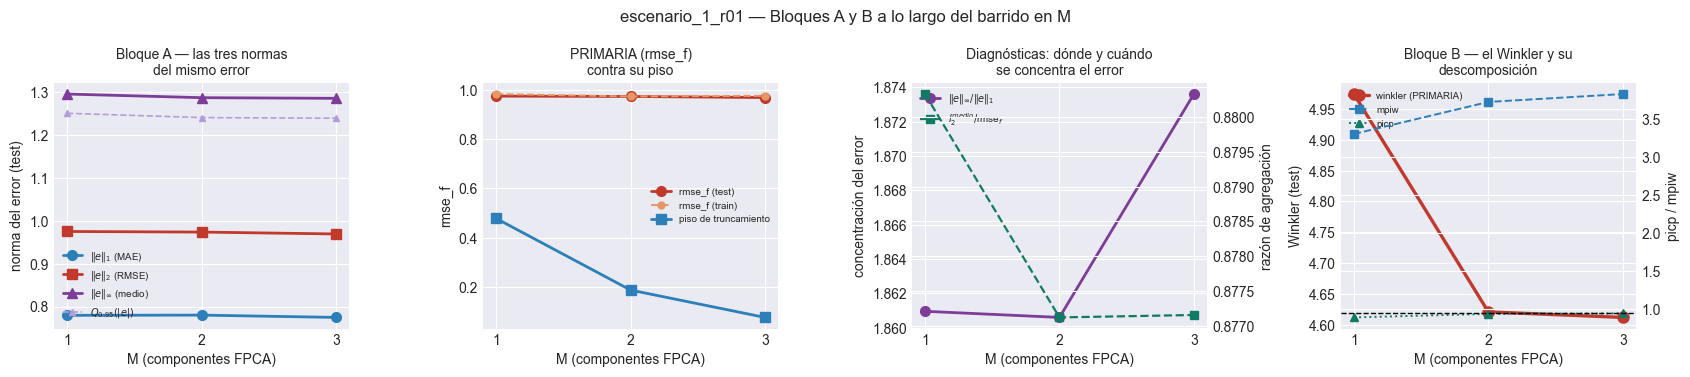

Lectura, y el orden importa:
  1. la PRIMARIA es rmse_f (Bloque A) y winkler (Bloque B); se fijaron en [CONFIG].
  2. mae_f y rmse_f pueden ordenar los M de forma distinta: estiman la
     mediana y la media condicional. Si discrepan, la conclusión
     DEPENDE de qué funcional pide la decisión, y hay que decirlo.
  3. picp y mpiw no ordenan nada por su cuenta: explican el winkler.


In [69]:
teAB = bloquesAB_df.loc["test"]
trAB = bloquesAB_df.loc["train"]
_MsAB = list(teAB.index)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))

# Panel 1: las tres normas del MISMO error, en el mismo eje. La cadena
# L^1 <= L^2 <= L^inf tiene que verse: si dos curvas se cruzan, hay un bug.
ax = axes[0]
ax.plot(_MsAB, teAB["mae_f"], "o-", lw=2, ms=7, color="#2c7fb8", label=r"$\|e\|_1$ (MAE)")
ax.plot(_MsAB, teAB["rmse_f"], "s-", lw=2, ms=7, color="#c0392b", label=r"$\|e\|_2$ (RMSE)")
ax.plot(_MsAB, teAB["linf_medio"], "^-", lw=2, ms=7, color="#7d3c98",
        label=r"$\|e\|_\infty$ (medio)")
ax.plot(_MsAB, teAB["q95_abs_medio"], "^--", lw=1.2, ms=5, color="#b39ddb",
        label=r"$Q_{0.95}(|e|)$")
ax.set_ylabel("norma del error (test)")
ax.set_title("Bloque A — las tres normas\ndel mismo error", fontsize=10)
ax.legend(fontsize=7)

# Panel 2: la primaria contra su piso de truncamiento.
ax = axes[1]
ax.plot(_MsAB, teAB[METRICA_PRIMARIA_A], "o-", lw=2, ms=7, color="#c0392b",
        label=f"{METRICA_PRIMARIA_A} (test)")
ax.plot(_MsAB, trAB[METRICA_PRIMARIA_A], "o--", lw=1.4, ms=5, color="#e59866",
        label=f"{METRICA_PRIMARIA_A} (train)")
ax.plot(_MsAB, teAB[f"{METRICA_PRIMARIA_A}_truncamiento"], "s-", lw=2, ms=7,
        color="#2c7fb8", label="piso de truncamiento")
ax.set_ylabel(METRICA_PRIMARIA_A)
ax.set_title(f"PRIMARIA ({METRICA_PRIMARIA_A})\ncontra su piso", fontsize=10)
ax.legend(fontsize=7)

# Panel 3: concentración y desigualdad temporal del error. Diagnósticas.
ax = axes[2]
ax.plot(_MsAB, teAB["razon_linf_l1"], "o-", lw=2, ms=7, color="#7d3c98",
        label=r"$\|e\|_\infty/\|e\|_1$")
ax2 = ax.twinx()
ax2.plot(_MsAB, teAB["razon_agregacion"], "s--", lw=1.6, ms=6, color="#117a65",
         label=r"$l_2^{medio}/$rmse$_f$")
ax2.set_ylabel("razón de agregación")
ax.set_ylabel("concentración del error")
ax.set_title("Diagnósticas: dónde y cuándo\nse concentra el error", fontsize=10)
_h1, _l1 = ax.get_legend_handles_labels(); _h2, _l2 = ax2.get_legend_handles_labels()
ax.legend(_h1 + _h2, _l1 + _l2, fontsize=7, loc="upper left")

# Panel 4: Bloque B. Winkler primaria; PICP y MPIW son su descomposición.
ax = axes[3]
ax.plot(_MsAB, teAB["winkler"], "o-", lw=2.4, ms=8, color="#c0392b",
        label="winkler (PRIMARIA)")
ax.set_ylabel("Winkler (test)")
ax2 = ax.twinx()
ax2.plot(_MsAB, teAB["mpiw"], "s--", lw=1.4, ms=6, color="#2c7fb8", label="mpiw")
ax2.plot(_MsAB, teAB["picp"], "^:", lw=1.4, ms=6, color="#117a65", label="picp")
ax2.axhline(NIVEL, color="k", ls="--", lw=1.0)
ax2.set_ylabel("picp / mpiw")
ax.set_title("Bloque B — el Winkler y su\ndescomposición", fontsize=10)
_h1, _l1 = ax.get_legend_handles_labels(); _h2, _l2 = ax2.get_legend_handles_labels()
ax.legend(_h1 + _h2, _l1 + _l2, fontsize=7, loc="upper left")

for ax in axes:
    ax.set_xticks(_MsAB); ax.set_xlabel("M (componentes FPCA)")
fig.suptitle(f"{EXPERIMENT_BASE} — Bloques A y B a lo largo del barrido en M",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "97_bloques_AB_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

print("Lectura, y el orden importa:")
print(f"  1. la PRIMARIA es {METRICA_PRIMARIA_A} (Bloque A) y "
      f"{METRICA_PRIMARIA_B} (Bloque B); se fijaron en [CONFIG].")
print("  2. mae_f y rmse_f pueden ordenar los M de forma distinta: estiman la")
print("     mediana y la media condicional. Si discrepan, la conclusión")
print("     DEPENDE de qué funcional pide la decisión, y hay que decirlo.")
print("  3. picp y mpiw no ordenan nada por su cuenta: explican el winkler.")


In [70]:
# ¿Discrepan las dos normas del Bloque A al ordenar los M? Es la comprobación
# que impide reportar la que convenga: si el orden coincide, la conclusión es
# robusta a la elección; si no, la elección la determina y hay que declararla.
_orden_rmse = list(teAB["rmse_f"].sort_values().index)
_orden_mae  = list(teAB["mae_f"].sort_values().index)
_orden_wink = list(teAB["winkler"].sort_values().index)

print(f"orden de M por rmse_f  (mejor -> peor): {_orden_rmse}")
print(f"orden de M por mae_f                  : {_orden_mae}")
print(f"orden de M por winkler                : {_orden_wink}")
if _orden_rmse != _orden_mae:
    print("\n  ATENCIÓN las dos normas del Bloque A NO coinciden en el orden.")
    print("  La media y la mediana condicionales apuntan a M distintos, cosa")
    print("  que ocurre cuando la predictiva es asimétrica o hay orígenes")
    print(f"  extremos. La conclusión depende de la primaria declarada")
    print(f"  ({METRICA_PRIMARIA_A}) y así hay que reportarla, con la otra al lado.")
else:
    print("\n  Las dos normas del Bloque A coinciden en el orden: la conclusión")
    print("  no depende de cuál se haya declarado primaria.")
if _orden_wink != _orden_rmse:
    print("  El Winkler ordena distinto que el error puntual: el mejor M en")
    print("  media condicional no es el mejor en calibración de intervalos.")

print(f"\nSalidas del barrido: 96_bloques_AB_por_M.csv y 97_bloques_AB_vs_M.png")
print(f"Por punto: 60_bloqueA_error.csv, 63_bloqueB_intervalos.csv,")
print(f"           64_bootstrap_bloques.csv, 65_ventana_bloque{{A,B}}.png")


orden de M por rmse_f  (mejor -> peor): [3, 2, 1]
orden de M por mae_f                  : [3, 1, 2]
orden de M por winkler                : [3, 2, 1]

  ATENCIÓN las dos normas del Bloque A NO coinciden en el orden.
  La media y la mediana condicionales apuntan a M distintos, cosa
  que ocurre cuando la predictiva es asimétrica o hay orígenes
  extremos. La conclusión depende de la primaria declarada
  (rmse_f) y así hay que reportarla, con la otra al lado.

Salidas del barrido: 96_bloques_AB_por_M.csv y 97_bloques_AB_vs_M.png
Por punto: 60_bloqueA_error.csv, 63_bloqueB_intervalos.csv,
           64_bootstrap_bloques.csv, 65_ventana_bloque{A,B}.png
